In [1]:
# !pip install pmdarima
# !pip install prophet

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import statistics
import scipy.stats as stats
from scipy.stats import chi2_contingency
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from pmdarima import auto_arima
from prophet import Prophet
from sklearn import metrics
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import itertools
import re

import sys
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
import time
import warnings
warnings.filterwarnings("ignore")


In [3]:
color_palette = ['#00557c', '#009490', '#00c1b6', '#00d7aC', '#ffa600', '#f95d6a','#1abc9c','#f1c40f','#8e44ad']

main_color= '#009490'

In [4]:
# Creating a function to visualize trends and seasonality using the STL (Seasonal and Trend decomposition using Loess) method

def stl_decomposition(df, column):
    """
    Apply STL decomposition to a given column of a dataframe and plot the results.
    
    Args:
        df (pandas.DataFrame): the dataframe containing the data to be analyzed
        column (str): the name of the column to be analyzed
        main_color (str): the color to use for the plot
        
    Returns:
        None
    """
    # Extract the column to be analyzed
    data = df[column]
    
    # Apply STL decomposition
    stl = STL(data, period=12)
    res = stl.fit()
    
    # Plot the results
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(10,6), squeeze=True)  # set squeeze=True to return a list of axes objects
    
    axes[0, 0].set_title(f'STL decomposition for {column}')
    axes[0, 0].plot(data.index, data.values, label='Original data', color=main_color)
    axes[0, 0].legend(loc='upper left')
    
    axes[0, 1].set_title('Seasonal component')
    axes[0, 1].plot(data.index, res.seasonal, color=main_color)
    
    axes[1, 0].set_title('Trend component')
    axes[1, 0].plot(data.index, res.trend, color=main_color)
    
    axes[1, 1].set_title('Residual component')
    axes[1, 1].plot(data.index, res.resid, color=main_color)
    
    plt.tight_layout()
    plt.show()

In [5]:
# Creating a function to impute missing values using AutoReg model
def forecast_impute_AutoReg(series, lags=5):
    missing = series.isna()
    non_missing = ~missing

    # Checking if there are any missing values in the series
    if missing.any():
        model = AutoReg(series[non_missing], lags=lags, old_names=False)
        results = model.fit()

        # Forecasting the missing values
        forecast = results.predict(start=len(series[non_missing]), end=len(series)-1)
        imputed_series = series.copy()
        imputed_series.loc[missing] = forecast.values
    else:
        imputed_series = series.copy()

    return imputed_series

In [6]:
def hist_box_maker(df,titl, figx, figy):
    num_of_rows = len(df.columns)
    fig, axes = plt.subplots(num_of_rows, ceil((len(df.columns)*2)/num_of_rows), figsize=(figx, figy))
    temp = (list(df.columns)*2)
    temp.sort()
    # Iterate across axes objects and associate each histogram:
    i = 0 
    for ax, feat in zip(axes.flatten(), temp):
        if i%2 == 0:
            ax.hist(df[feat], bins = 50, color=main_color)
            ax.set_title(feat,x=-0.3)
            pltiswork=feat
        else:
            sns.boxplot(x=df[pltiswork], ax = ax, color=main_color)
        i+=1    
    title = titl
    plt.suptitle(title,y=0.90)
    plt.show()

In [7]:
# Creating a function to visualize ACF and PACF

def acf_pacf(df, column):
    """
    Apply ACF and PACF to a given column of a dataframe and plot the results.
    
    Args:
        df (pandas.DataFrame): the dataframe containing the data to be analyzed
        column (str): the name of the column to be analyzed
    
    Returns:
        None
    """
    # Extract the column to be analyzed
    data = df[column]
    
    # Plot the results
    fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10,4))
    
    # Plot the autocorrelation function (ACF)
    plot_acf(data, ax=axes[0], lags=20,color=main_color)  # You may need to adjust the 'lags' parameter depending on your data's seasonality
    # Plot the partial autocorrelation function (PACF)
    plot_pacf(data, ax=axes[1], lags=20,color=main_color)  # You may need to adjust the 'lags' parameter depending on your data's seasonality
    
    
    # Set the titles for the subplots
    axes[0].set_title(f'Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) for {column}')
    axes[1].set_title("")
    
    plt.tight_layout()
    plt.show()

In [8]:
def correlation_matrix (df, features):
    
    '''
    Pass a dataframe and the dataframe metric features,
    and plots the correlation matrix (all the correlations 
    between the correspondent features).
 
    Arguments:
        df (dataframe): dataframe
        features (list): df metric features
        
    '''
    correlation_df= df[features].corr(method='kendall')
    #calls correlation_matrix_from_corr() function
    correlation_matrix_from_corr(correlation_df)
    return

In [9]:
def correlation_matrix_from_corr(correlation_df):
    
    '''
    Plots the correlation_df in an heatmap format.
 
    Arguments:
        correlation_df (dataframe): dataframe
        
    '''
    
    mask = np.triu(np.ones_like(correlation_df, dtype=bool))
 
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(19, 17))
 
    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
 
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(correlation_df, annot = True, mask=mask, cmap=cmap,vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
 
    plt.title('Correlation Between Variables ', size=20)
    return

In [10]:
# Creating a function to drop columns that contain a certain word in their name

def columns_containing_words(data, words_list):
    """
    Drops columns from the input DataFrame whose names contain any of the specified words.
    
    Parameters:
    - data (pandas DataFrame): The input DataFrame to modify.
    - words_list (list of str): The list of words to search for in the column names.
    
    Returns:
    - data (pandas DataFrame): The modified DataFrame with selected columns dropped.
    """
    # get the list of column names
    cols = data.columns.tolist()
    
    # create a new list of column names that don't contain any of the specified words
    new_cols = [col for col in cols if any(word in col for word in words_list)]

    
    return new_cols


In [11]:
# Creating a function that createas a monthly sales bar chart for each product type 

def plot_monthly_sales_by_product_type(df, product_type):
    # Melt the data to create a "long" format with separate rows for each product
    df_melted = df.melt(id_vars='date', var_name='Product', value_name='Sales')

    # Filter the data to include only the specified product type
    df_filtered = df_melted[df_melted['Product'] == product_type]

    # Group the data by month and calculate the total sales for each group
    sales_by_month = df_filtered.groupby(pd.Grouper(key='date', freq='M')).sum()

    # Format the date string to display only the month and year
    sales_by_month.index = sales_by_month.index.strftime('%b %Y')

    # Create the bar chart for the filtered data
    sns.set_style("darkgrid")
    plt.figure(figsize=(15, 10))
    sns.barplot(x=sales_by_month.index, y='Sales', color= main_color, data=sales_by_month)
    plt.xticks(rotation=45)

    # Set the plot title and axis labels
    plt.title(f"Monthly Sales for {product_type}")
    plt.xlabel("Month")
    plt.ylabel("Sales")

    # Show the plot
    plt.show()


In [12]:
# Function to create lag features
def series_to_supervised(data, n_in_start=1,n_in_end=8, n_out=1, dropnan=True, varNames=None):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in_end, n_in_start-1, -1):
        cols.append(df.shift(i))
        names += [(varNames[j]+'(t-%d)' % (i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [(varNames[j]+'(t)' ) for j in range(n_vars)]
        else:
            names += [(varNames[j]+'(t+%d)' % (i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [13]:
def stationarity_verification (df,product_column_name):
    
    #Rolling 
    plt.plot(df[product_column_name], label='Original',color='black')
    plt.plot(df[product_column_name].rolling(window=5, center=False).mean(), label='Rolling Mean',color='#00d7a0')
    plt.plot(df[product_column_name].rolling(window=5, center=False).std(), label='Rolling Std',color='#00557c')
    plt.grid()
    plt.legend()
    plt.figure(figsize=(10, 15))
    plt.show()
    
    #Augmented Dickey–Fuller test:
    #Null Hypothesis: The data is not stationary.
    #Alternative Hypothesis: The data is stationary.
    print('Results of Dickey Fuller Test:')
    dftest = adfuller(df[product_column_name], autolag='AIC')

    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    return 
    

In [14]:
def plotTrainValidation(y_train,y_val=None,y_pred=None):
    title='Train and Validation sets for '+y_train.columns[0]
    plt.figure(figsize=(15,5))
    plt.title(title, size=12)
    
    plt.plot(y_train, label='Training set',color='black')
    if y_val is not None:
        plt.plot(y_val, label='Validation set', color='#00d7a0')
    
    if y_pred is not None:
        plt.plot(y_pred, label='Prediction set', color='#9C332D')
    plt.legend();

In [15]:
# Function to create dataframe with metrics

def performanceMetricsDF(metricsObj, yTrain=None, yPredTrain=None, yTest=None, 
                         yPredTest=None, set1="Train", set2="Test"):
    measures_list = ["MAE", "RMSE", "R^2", "MAPE (%)", "MAX Error"]
    if yTrain is not None:
        train_results = [
            np.round(metricsObj.mean_absolute_error(yTrain, yPredTrain),3),
            np.round(np.sqrt(metricsObj.mean_squared_error(yTrain, yPredTrain)),3),
            np.round(metricsObj.r2_score(yTrain, yPredTrain),3),
            np.round(metricsObj.mean_absolute_percentage_error(yTrain, yPredTrain),3),
            np.round(metricsObj.max_error(yTrain, yPredTrain),3),
        ]
    if yTest is not None:
        test_results = [
            np.round(metricsObj.mean_absolute_error(yTest, yPredTest),3),
            np.round(np.sqrt(metricsObj.mean_squared_error(yTest, yPredTest)),3),
            np.round(metricsObj.r2_score(yTest, yPredTest),3),
            np.round(metricsObj.mean_absolute_percentage_error(yTest, yPredTest),3),
            np.round(metricsObj.max_error(yTest, yPredTest),3)
        ]
    if (yTrain is not None) and (yTest is not None):
        resultsDF = pd.DataFrame(
            {"Measure": measures_list, set1: train_results, set2: test_results}
        )
    if (yTrain is None) and (yTest is not None):
        resultsDF = pd.DataFrame(
            {"Measure": measures_list, set2: test_results}
        )
    if (yTrain is not None) and (yTest is None):
        resultsDF = pd.DataFrame(
            {"Measure": measures_list, set1: train_results}
        )

    return resultsDF

In [16]:
def xgboostModel_predict_months(xgboost,X_train,y_train,months_to_predict):
    predictions=[]
    #For each month that needs predictions, a walking forward approach is taken.
    for month in range(1,months_to_predict+1):
        new_date= X_train.index.max()+ pd.DateOffset(1)+pd.offsets.MonthEnd(1)

        row_to_input={}
        #the lag is taken from each column's name and retrieved the original value from the no lag dataframes
        for column in X_train.columns:
            column_withoutlag= column.split("(")[0]
            #extract lag 
            match1 = re.search(r'\(t-(\d+)\)', column)
            number_lags = int(match1.group(1))
            
            date_from_lag=new_date + pd.DateOffset(days=1)- pd.DateOffset(months=number_lags+1)+pd.offsets.MonthEnd(1)

            if 'GCK' not in column:
                row_to_input[column] = market_data.loc[date_from_lag,column_withoutlag]
            else:
                row_to_input[column] = y_train.loc[date_from_lag,column_withoutlag+"(t)"]
        
       
        row_to_input = pd.DataFrame(row_to_input, index=[new_date], columns=X_train.columns)
        
        #the model is fitted on the current X_Train and y_Train
        xgboost.fit(X_train, y_train)
        prediction=xgboost.predict(row_to_input)[0]
        predictions.append(prediction)
        # the training dataframes are updated with the predicted value and the correspoding lag features
        X_train= X_train.append(row_to_input)
        y_train.loc[new_date] =prediction
    return X_train,y_train,predictions

In [17]:
class ProductsEnsemble:
 
    def __init__(self, estimators, holidays_prophet): 
        """
        Estimators list is required, with tuples format (estimator_name,estimator). They can be preffit or not.
        """
        self.estimators = estimators
        self.holidays_prophet = holidays_prophet
    
    def fit_predict_all(self, X_train_list,y_train_list,X_test_list,y_test_list):
        """ 
        For each estimator and the respective X_train and y_train,
        assuming the same order, the model is trained with the dependent and target variables.
        The model returns the predictions regarding the dependent variables.
        """
        predictions_list=[]
        for ((name,estimator),X_train, y_train,X_test,y_test) in zip(self.estimators,X_train_list,y_train_list,X_test_list,y_test_list):
            forecasts={}
            if 'mean' in estimator:
                # Use the mean of the training data as a forecast
                predictions =np.full(len(y_test),np.mean(y_train))
                forecasts['mean']=predictions
                
            if 'median' in estimator:
                # Use the median of the training data as a forecast
                predictions =np.full(len(y_test),np.median(y_train))
                forecasts['median']=predictions
                
            if 'prophet' in estimator:
                # Use Facebook Prophet to make a forecast
        
                # mapping 'date' indexes as columns 'ds'.
                prophet_train_data=y_train.reset_index().rename(columns={'date':'ds',y_train.columns[0]:"y"})
                prophet_test_data=y_test.reset_index().rename(columns={'date':'ds',y_train.columns[0]:"y"})
                
                #prophet object is created with holidays feature being used. 
                prophet=Prophet(holidays=holidays_prophet)
                # fitting prophet with training data and regressors
                #print(prophet_train_data)
                prophet.fit(prophet_train_data)
                #predicting validation data
                predictions= prophet.predict(prophet_test_data)['yhat'].values
                forecasts['prophet']=predictions
                
            if 'prophet_w_reg' in estimator:
                # Use Facebook Prophet with exogenous regressors to make a forecast
        
                # Defining external variables. The lags of the product sales are not included.
                regressors_prophet = [regressor for regressor in X_train.columns if "GCK" not in regressor]
                
                prod_col=y_train.columns[0]
                # joining x and y features of train/validation, with columns date as 'ds' and product as 'y'
                prophet_train_data = y_train.merge(X_train[regressors_prophet], how='left', on="date").reset_index().rename(
                    columns={'date': 'ds', prod_col: "y"})
                prophet_test_data = y_test.merge(X_test[regressors_prophet], how='left', on="date").reset_index().rename(
                    columns={'date': 'ds', prod_col: "y"})
                #prophet object is created with holidays feature being used. 
                prophet_w_reg=Prophet(holidays=holidays_prophet)
                # Adding external variables as regressors. The lags of the product sales are not included.
                for regressor in regressors_prophet:
                    if "GCK" not in regressor:
                        prophet_w_reg.add_regressor(regressor)
                        
                # fitting prophet with training data and regressors
                prophet_w_reg.fit(prophet_train_data)
                #predicting validation data
                predictions = prophet_w_reg.predict(prophet_test_data)['yhat'].values
                forecasts['prophet_w_reg']=predictions
                
            if 'arima' in estimator:
                # Use Arima to make a forecast
        
                # fitting Arima with training datas
                arima = auto_arima(y_train,start_p=1,start_q=1, trace=False,stationary=True, 
                           steperror_action='ignore', suppress_warnings=True)
                # make prediction for the validation
                predictions = arima.predict(n_periods=len(y_test))
                forecasts['arima']=predictions
            
        
            if 'arima_w_reg' in estimator:
                # Use Arima with exogenous regressors to make a forecast
        
                # Defining external variables. The lags of the product sales are not included.
                regressors_arima = [regressor for regressor in X_train.columns if "GCK" not in regressor]

                # fitting Arima with training data and regressors
                arima_w_reg = auto_arima(y_train, X_train[regressors_arima],start_p=1,start_q=1,stationary=True, trace=False, steperror_action='ignore', suppress_warnings=True)
                # make prediction for the validation
                predictions = arima_w_reg.predict(n_periods=len(y_test), X=X_test[regressors_arima])
                forecasts['arima_w_reg']=predictions
            
            if 'xgboost' in estimator:
                values= estimator.split("(")
                values=values[1].split(")")[0]
                # Use XGBoost with exogenous regressors to make a forecast
                 
                # Drop null values, since this model uses the sales lag features
                X_train_xgboost= X_train.dropna()
                y_train_xgboost = y_train.loc[X_train_xgboost.index].copy()

                n_estimators,max_depth,learning_rate=values.split(",")
                # Use XGBoost with exogenous regressors to make a forecast
                xgboost=xgb.XGBRegressor(n_estimators=int(n_estimators),
                                         max_depth=int(max_depth),
                                         learning_rate=float(learning_rate))

                # fit the model object to the training data
                _,_,predictions = xgboostModel_predict_months(xgboost,X_train_xgboost,y_train_xgboost,len(y_test))
                forecasts['xgboost']=predictions
                    
            if 'ensemble' in estimator:
                # get models from ensemble name
                models_list= estimator[9:len(estimator)-1]
                models_list = models_list.split(";")
                # Calculate the ensemble forecast for the current combination
                predictions = sum(forecasts[forecast] for forecast in forecasts.keys()) / len(forecasts.keys())
            else:
                # if is not ensemble only adds the first and only predictions to the predictions_list
                predictions= list(forecasts.values())[0]
      
            predictions_list.append(pd.DataFrame(predictions,index=y_test.index))
        
        return predictions_list
   
    

In [18]:
# Display all columns when printing a DataFrame
pd.set_option('display.max_columns',None)

In [19]:
# !pip install openpyxl

In [20]:
import openpyxl

In [21]:
# Load data 
df = pd.read_csv('data/Case2_Sales data.csv', delimiter=';', header=0, encoding="utf-8")

test = pd.read_csv('data/Case2_Test Set Template.csv', delimiter=';', header=0, encoding="utf-8")

data_market = pd.read_excel('data/Case2_Market data.xlsx',header=None)


<hr>
<a class="anchor" id="heading3">
    
# 3. Market Data Reshaping
    
</a>

In [22]:
data_market.head(4)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
0,NaN,China,China,France,France,Germany,Germany,Italy,Italy,Japan,Japan,Switzerland,Switzerland,United Kingdom,United Kingdom,United States,United States,Europe,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Producer Prices,Producer Prices,Producer Prices,Producer Prices,Producer Prices,Producer Prices,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index
1,Index 2010=100 (if not otherwise noted),Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,World: Price of Base Metals,World: Price of Energy,World: Price of Metals & Minerals,World: Price of Natural gas index,"World: Price of Crude oil, average",World: Price of Copper,United States: EUR in LCU,United States: Electrical equipment,United Kingdom: Electrical equipment,Italy: Electrical equipment,France: Electrical equipment,Germany: Electrical equipment,China: Electrical equipment,United States: Machinery and equipment n.e.c.,World: Machinery and equipment n.e.c.,Switzerland: Machinery and equipment n.e.c.,United Kingdom: Machinery and equipment n.e.c.,Italy: Machinery and equipment n.e.c.,Japan: Machinery and equipment n.e.c.,France: Machinery and equipment n.e.c.,Germany: Machinery and equipment n.e.c.,United States: Electrical equipment,World: Electrical equipment,Switzerland: Electrical equipment,United Kingdom: Electrical equipment,Italy: Electrical equipment,Japan: Electrical equipment,France: Electrical equipment,Germany: Electrical equipment
2,date,MAB_ELE_PRO156,MAB_ELE_SHP156,MAB_ELE_PRO250,MAB_ELE_SHP250,MAB_ELE_PRO276,MAB_ELE_SHP276,MAB_ELE_PRO380,MAB_ELE_SHP380,MAB_ELE_PRO392,MAB_ELE_SHP392,MAB_ELE_PRO756,MAB_ELE_SHP756,MAB_ELE_PRO826,MAB_ELE_SHP826,MAB_ELE_PRO840,MAB_ELE_SHP840,MAB_ELE_PRO1100,MAB_ELE_SHP1100,RohiBASEMET1000_org,RohiENERGY1000_org,RohiMETMIN1000_org,RohiNATGAS1000_org,RohCRUDE_PETRO1000_org,RohCOPPER1000_org,WKLWEUR840_org,PRI27840_org,PRI27826_org,PRI27380_org,PRI27250_org,PRI27276_org,PRI27156_org,PRO28840_org,PRO281000_org,PRO28756_org,PRO28826_org,PRO28380_org,PRO28392_org,PRO28250_org,PRO28276_org,PRO27840_org,PRO271000_org,PRO27756_org,PRO27826_org,PRO27380_org,PRO27392_org,PRO27250_org,PRO27276_org
3,2004m2,16.940704,16.940704,112.091273,83.458866,82.623037,79.452532,124.289603,86.560493,109.33401,110.495272,91.221862,89.987275,111.353812,73.601265,107.6014,79.24023,97.122911,80.09853,54.039811,44.123338,48.747945,87.076974,39.639458,36.623832,1.2646,78.969864,80.757423,93.020027,NaN,93.230453,NaN,102.491722,97.597374,97.1,106.191977,116.790276,110.890034,118.274109,80.82901,117.723991,NaN,81.1,120.706516,141.510864,106.161262,102.077057,85.9132


In [23]:
data_market.replace("",np.NaN,inplace=True)

In [24]:
data_market = data_market.applymap(lambda x: x.strip() if isinstance(x, str) else x)



In [25]:
data_market

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
0,NaN,China,China,France,France,Germany,Germany,Italy,Italy,Japan,Japan,Switzerland,Switzerland,United Kingdom,United Kingdom,United States,United States,Europe,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Producer Prices,Producer Prices,Producer Prices,Producer Prices,Producer Prices,Producer Prices,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index
1,Index 2010=100 (if not otherwise noted),Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,World: Price of Base Metals,World: Price of Energy,World: Price of Metals & Minerals,World: Price of Natural gas index,"World: Price of Crude oil, average",World: Price of Copper,United States: EUR in LCU,United States: Electrical equipment,United Kingdom: Electrical equipment,Italy: Electrical equipment,France: Electrical equipment,Germany: Electrical equipment,China: Electrical equipment,United States: Machinery and equipment n.e.c.,World: Machinery and equipment n.e.c.,Switzerland: Machinery and equipment n.e.c.,United Kingdom: Machinery and equipment n.e.c.,Italy: Machinery and equipment n.e.c.,Japan: Machinery and equipment n.e.c.,France: Machinery and equipment n.e.c.,Germany: Machinery and equipment n.e.c.,United States: Electrical equipment,World: Electrical equipment,Switzerland: Electrical equipment,United Kingdom: Electrical equipment,Italy: Electrical equipment,Japan: Electrical equipment,France: Electrical equipment,Germany: Electrical equipment
2,date,MAB_ELE_PRO156,MAB_ELE_SHP156,MAB_ELE_PRO250,MAB_ELE_SHP250,MAB_ELE_PRO276,MAB_ELE_SHP276,MAB_ELE_PRO380,MAB_ELE_SHP380,MAB_ELE_PRO392,MAB_ELE_SHP392,MAB_ELE_PRO756,MAB_ELE_SHP756,MAB_ELE_PRO826,MAB_ELE_SHP826,MAB_ELE_PRO840,MAB_ELE_SHP840,MAB_ELE_PRO1100,MAB_ELE_SHP1100,RohiBASEMET1000_org,RohiENERGY1000_org,RohiMETMIN1000_org,RohiNATGAS1000_org,RohCRUDE_PETRO1000_org,RohCOPPER1000_org,WKLWEUR840_org,PRI27840_org,PRI27826_org,PRI27380_org,PRI27250_org,PRI27276_org,PRI27156_org,PRO28840_org,PRO281000_org,PRO28756_org,PRO28826_org,PRO28380_org,PRO28392_org,PRO28250_org,PRO28276_org,PRO27840_org,PRO271000_org,PRO27756_org,PRO27826_org,PRO27380_org,PRO27392_org,PRO27250_org,PRO27276_org
3,2004m2,16.940704,16.940704,112.091273,83.458866,82.623037,79.452532,124.289603,86.560493,109.33401,110.495272,91.221862,89.987275,111.353812,73.601265,107.6014,79.24023,97.122911,80.09853,54.039811,44.123338,48.747945,87.076974,39.639458,36.623832,1.2646,78.969864,80.757423,93.020027,NaN,93.230453,NaN,102.491722,97.597374,97.1,106.191977,116.790276,110.890034,118.274109,80.82901,117.723991,NaN,81.1,120.706516,141.510864,106.161262,102.077057,85.9132
4,2004m3,23.711852,23.711852,136.327976,106.168192,100.556582,97.012918,143.411662,106.344544,140.884616,144.686166,85.866287,79.883583,127.558608,84.047595,110.187364,98.619024,113.783904,96.015929,54.666162,47.588957,49.256157,87.192705,42.592034,39.931055,1.2262,79.673569,80.962135,93.540268,NaN,93.335678,NaN,105.62748,113.224892,91.195116,121.625075,139.288391,141.176853,148.121841,102.130104,1

In [26]:
#Checking for possible Columns names relationships.
pd.DataFrame(data_market.iloc[0:3,:].T).rename(columns={0:"Row 1",1:"Row 2",3:"Row 3"})

,Row 1,Row 2,2
0,NaN,Index 2010=100 (if not otherwise noted),date
1,China,Production Index Machinery & Electricals,MAB_ELE_PRO156
2,China,Shipments Index Machinery & Electricals,MAB_ELE_SHP156
3,France,Production Index Machinery & Electricals,MAB_ELE_PRO250
4,France,Shipments Index Machinery & Electricals,MAB_ELE_SHP250
5,Germany,Production Index Machinery & Electricals,MAB_ELE_PRO276
6,Germany,Shipments Index Machinery & Electricals,MAB_ELE_SHP276
7,Italy,Production Index Machinery & Electricals,MAB_ELE_PRO380
8,Italy,Shipments Index Machinery & Electricals,MAB_ELE_SHP380
9,Japan,Production Index Machinery & Electricals,MAB_ELE_PRO392


In [27]:
data_market

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
0,NaN,China,China,France,France,Germany,Germany,Italy,Italy,Japan,Japan,Switzerland,Switzerland,United Kingdom,United Kingdom,United States,United States,Europe,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Producer Prices,Producer Prices,Producer Prices,Producer Prices,Producer Prices,Producer Prices,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index,production index
1,Index 2010=100 (if not otherwise noted),Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,Production Index Machinery & Electricals,Shipments Index Machinery & Electricals,World: Price of Base Metals,World: Price of Energy,World: Price of Metals & Minerals,World: Price of Natural gas index,"World: Price of Crude oil, average",World: Price of Copper,United States: EUR in LCU,United States: Electrical equipment,United Kingdom: Electrical equipment,Italy: Electrical equipment,France: Electrical equipment,Germany: Electrical equipment,China: Electrical equipment,United States: Machinery and equipment n.e.c.,World: Machinery and equipment n.e.c.,Switzerland: Machinery and equipment n.e.c.,United Kingdom: Machinery and equipment n.e.c.,Italy: Machinery and equipment n.e.c.,Japan: Machinery and equipment n.e.c.,France: Machinery and equipment n.e.c.,Germany: Machinery and equipment n.e.c.,United States: Electrical equipment,World: Electrical equipment,Switzerland: Electrical equipment,United Kingdom: Electrical equipment,Italy: Electrical equipment,Japan: Electrical equipment,France: Electrical equipment,Germany: Electrical equipment
2,date,MAB_ELE_PRO156,MAB_ELE_SHP156,MAB_ELE_PRO250,MAB_ELE_SHP250,MAB_ELE_PRO276,MAB_ELE_SHP276,MAB_ELE_PRO380,MAB_ELE_SHP380,MAB_ELE_PRO392,MAB_ELE_SHP392,MAB_ELE_PRO756,MAB_ELE_SHP756,MAB_ELE_PRO826,MAB_ELE_SHP826,MAB_ELE_PRO840,MAB_ELE_SHP840,MAB_ELE_PRO1100,MAB_ELE_SHP1100,RohiBASEMET1000_org,RohiENERGY1000_org,RohiMETMIN1000_org,RohiNATGAS1000_org,RohCRUDE_PETRO1000_org,RohCOPPER1000_org,WKLWEUR840_org,PRI27840_org,PRI27826_org,PRI27380_org,PRI27250_org,PRI27276_org,PRI27156_org,PRO28840_org,PRO281000_org,PRO28756_org,PRO28826_org,PRO28380_org,PRO28392_org,PRO28250_org,PRO28276_org,PRO27840_org,PRO271000_org,PRO27756_org,PRO27826_org,PRO27380_org,PRO27392_org,PRO27250_org,PRO27276_org
3,2004m2,16.940704,16.940704,112.091273,83.458866,82.623037,79.452532,124.289603,86.560493,109.33401,110.495272,91.221862,89.987275,111.353812,73.601265,107.6014,79.24023,97.122911,80.09853,54.039811,44.123338,48.747945,87.076974,39.639458,36.623832,1.2646,78.969864,80.757423,93.020027,NaN,93.230453,NaN,102.491722,97.597374,97.1,106.191977,116.790276,110.890034,118.274109,80.82901,117.723991,NaN,81.1,120.706516,141.510864,106.161262,102.077057,85.9132
4,2004m3,23.711852,23.711852,136.327976,106.168192,100.556582,97.012918,143.411662,106.344544,140.884616,144.686166,85.866287,79.883583,127.558608,84.047595,110.187364,98.619024,113.783904,96.015929,54.666162,47.588957,49.256157,87.192705,42.592034,39.931055,1.2262,79.673569,80.962135,93.540268,NaN,93.335678,NaN,105.62748,113.224892,91.195116,121.625075,139.288391,141.176853,148.121841,102.130104,1

In [28]:
#From columns 1 to 18, location is on the first row and the index on the second.
location_on_first_row_columns=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]

#From columns 19 to 47, location is joined to the second row through ":".
location_on_second_row_columns=np.arange(19,48)
producer_prices_columns=[26,27,28,29,30,31]
production_indexes_columns=[32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47]
#Eur in lcu will be replaced by EUR/USD
eur_in_lcu = 25

# For each column, in in each of the referred columns, proceeds to do the necessary transformation,
# to join the index name with the location as Index Name_Location

new_row=[]
for each_column in data_market.columns:
    
    if each_column in location_on_first_row_columns:
        new_row.append(data_market.iloc[1,each_column].title()+"_"+data_market.iloc[0,each_column].title())
        
    if each_column in location_on_second_row_columns:
        location=data_market.iloc[1,each_column].split(": ")[0].title()
        index=data_market.iloc[1,each_column].split(": ")[1].title()
        
        if each_column in producer_prices_columns:
            index="Producer Prices "+index
            
        if each_column in production_indexes_columns:
            index="Production Index "+index
            
        if each_column==eur_in_lcu:
            location="World"
            index="EUR/USD"
            
        new_row.append(index+"_"+location)

In [29]:
print(len(new_row))
print(len(data_market.columns[2:]))

47
46


In [30]:
# Replace unnecessary third row with the new one.
data_market.iloc[2,1:]=new_row
# Define the new row as columns and deleted the older ones.
data_market.columns=data_market.iloc[2,:]
data_market.drop([0,1,2],inplace=True)

# Map the date column, in datetime type
data_market['date'] = pd.to_datetime(data_market['date'].str.split('m', expand=True)[0] + '-' +
                                     data_market['date'].str.split('m', expand=True)[1] + '-1',
                                     format="%Y-%m-%d") + pd.offsets.MonthEnd(1)

#Set the date column as index
data_market.set_index(keys="date",drop=True,inplace=True)
data_market.columns.name = ''
# Map all the values to numeric, since they are values.
market_data = data_market.apply(pd.to_numeric)
#Reorder Columns by name
market_data = market_data.reindex(sorted(market_data.columns), axis=1)

In [31]:
data_market.head(4)

,Production Index Machinery & Electricals_China,Shipments Index Machinery & Electricals_China,Production Index Machinery & Electricals_France,Shipments Index Machinery & Electricals_France,Production Index Machinery & Electricals_Germany,Shipments Index Machinery & Electricals_Germany,Production Index Machinery & Electricals_Italy,Shipments Index Machinery & Electricals_Italy,Production Index Machinery & Electricals_Japan,Shipments Index Machinery & Electricals_Japan,Production Index Machinery & Electricals_Switzerland,Shipments Index Machinery & Electricals_Switzerland,Production Index Machinery & Electricals_United Kingdom,Shipments Index Machinery & Electricals_United Kingdom,Production Index Machinery & Electricals_United States,Shipments Index Machinery & Electricals_United States,Production Index Machinery & Electricals_Europe,Shipments Index Machinery & Electricals_Europe,Price Of Base Metals_World,Price Of Energy_World,Price Of Metals & Minerals_World,Price Of Natural Gas Index_World,"Price Of Crude Oil, Average_World",Price Of Copper_World,EUR/USD_World,Producer Prices Electrical Equipment_United States,Producer Prices Electrical Equipment_United Kingdom,Producer Prices Electrical Equipment_Italy,Producer Prices Electrical Equipment_France,Producer Prices Electrical Equipment_Germany,Producer Prices Electrical Equipment_China,Production Index Machinery And Equipment N.E.C._United States,Production Index Machinery And Equipment N.E.C._World,Production Index Machinery And Equipment N.E.C._Switzerland,Production Index Machinery And Equipment N.E.C._United Kingdom,Production Index Machinery And Equipment N.E.C._Italy,Production Index Machinery And Equipment N.E.C._Japan,Production Index Machinery And Equipment N.E.C._France,Production Index Machinery And Equipment N.E.C._Germany,Production Index Electrical Equipment_United States,Production Index Electrical Equipment_World,Production Index Electrical Equipment_Switzerland,Production Index Electrical Equipment_United Kingdom,Production Index Electrical Equipment_Italy,Production Index Electrical Equipment_Japan,Production Index Electrical Equipment_France,Production Index Electrical Equipment_Germany
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-02-29,16.940704,16.940704,112.091273,83.458866,82.623037,79.452532,124.289603,86.560493,109.33401,110.495272,91.221862,89.987275,111.353812,73.601265,107.6014,79.24023,97.122911,80.09853,54.039811,44.123338,48.747945,87.076974,39.639458,36.623832,1.2646,78.969864,80.757423,93.020027,NaN,93.230453,NaN,102.491722,97.597374,97.1,106.191977,116.790276,110.890034,118.274109,80.82901,117.723991,NaN,81.1,120.706516,141.510864,106.161262,102.077057,85.9132
2004-03-31,23.711852,23.711852,136.327976,106.168192,100.556582,97.012918,143.411662,106.344544,140.884616,144.686166,85.866287,79.883583,127.558608,84.047595,110.187364,98.619024,113.783904,96.015929,54.666162,47.588957,49.256157,87.192705,42.592034,39.931055,1.2262,79.673569,80.962135,93.540268,NaN,93.335678,NaN,105.62748,113.224892,91.195116,121.625075,139.288391,141.176853,148.121841,102.130104,119.220779,NaN,76.690307,138.30955,152.880234,140.288741,117.225685,97.670815
2004-04-30,24.435235,24.435235,117.791806,92.007646,89.653203,84.932358,129.083828,95.579673,105.853579,102.655769,85.622508,79.740802,108.732297,73.026027,108.166564,89.774031,101.715199,85.167236,54.872715,47.779013,49.423751,91.379923,42.650637,39.134854,1.1985,80.337639,80.757423,93.852425,NaN,93.440903,NaN,103.484955,100.16909,93.793535,104.965505,125.289566,105.648765,125.482231,90.961426,117.441124,NaN,71.552403,115.55733,137.796875,106.271197,105.335777,87.253983
2004-05-31,23.708115,23.708115,109.002541,85.696486,86.880571,82.372794,135.590391,100.087039,101.864777,100.305285,85.378729,79.598021,110.6452,74.591883,108.425887,87.463813,101.275727,84.485767,51.230356,53.590898,46.468392,99.04452,47.517121,36.278433,1.2007,80.798828,80.757423,93.852425,NaN,93.546127,NaN,103.643944,99.581436,96.391954

In [32]:
data_market.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 219 entries, 2004-02-29 to 2022-04-30
Data columns (total 47 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   Production Index Machinery & Electricals_China                  219 non-null    object
 1   Shipments Index Machinery & Electricals_China                   219 non-null    object
 2   Production Index Machinery & Electricals_France                 219 non-null    object
 3   Shipments Index Machinery & Electricals_France                  219 non-null    object
 4   Production Index Machinery & Electricals_Germany                219 non-null    object
 5   Shipments Index Machinery & Electricals_Germany                 219 non-null    object
 6   Production Index Machinery & Electricals_Italy                  219 non-null    object
 7   Shipments Index Machinery & Electricals_Ita

<hr>
<a class="anchor" id="heading4">
    
# 4. Sales Data Reshaping
    
</a>

In [33]:
print(df.info())
df.tail(3)
# Date is not in the correct data type.
# Columns Mapped_GCK and Sales can be extended as unique sales columns (i.e. GCK_1,GCK_2,GCK_3,...)
# Sales is not in number format due to incorrect decimal divisor (,)

#Since the sales data is intended to be analysed in a monthly spectrum, the data will be grouped by month.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9802 entries, 0 to 9801
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   DATE        9802 non-null   object
 1   Mapped_GCK  9802 non-null   object
 2   Sales_EUR   9802 non-null   object
dtypes: object(3)
memory usage: 229.9+ KB
None


,DATE,Mapped_GCK,Sales_EUR
9799,12.08.2019,#12,0
9800,28.08.2019,#8,"43763,91"
9801,27.08.2019,#8,0


In [34]:
# Mapping Empty cells to Nans
df.replace("",np.NaN,inplace=True)

In [35]:
# In case there is any extra space in the values (either to the left or to the right), they are removed.
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

In [36]:
# Mappig Mapped_GCK values to GCK_number
df['Mapped_GCK'] = "GCK_"+df['Mapped_GCK'].str.replace('#', '')
# Replacing "," by "." to enable numeric datatype
df['Sales_EUR'] = df['Sales_EUR'].str.replace(',', '.')

In [37]:
# Pivoting to the desired format, columns as GCKs and values as Sales
df['date'] = pd.to_datetime(df['DATE'], format='%d.%m.%Y') 
df=df.pivot(index="date",columns="Mapped_GCK",values="Sales_EUR")

In [38]:
# Map all the values to numeric, since they are sales values.
df = df.apply(pd.to_numeric)
#Reorder Columns by name
desired_order = ['GCK_1', 'GCK_3', 'GCK_4', 'GCK_5', 'GCK_6', 'GCK_8', 'GCK_9', 
                 'GCK_11', 'GCK_12', 'GCK_13', 'GCK_14', 'GCK_16', 'GCK_20', 'GCK_36']
df = df[desired_order]

In [39]:
# Aggregating dataset by month, and applying sum to all days
df=df.resample('M').sum()

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43 entries, 2018-10-31 to 2022-04-30
Freq: ME
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GCK_1   43 non-null     float64
 1   GCK_3   43 non-null     float64
 2   GCK_4   43 non-null     float64
 3   GCK_5   43 non-null     float64
 4   GCK_6   43 non-null     float64
 5   GCK_8   43 non-null     float64
 6   GCK_9   43 non-null     float64
 7   GCK_11  43 non-null     float64
 8   GCK_12  43 non-null     float64
 9   GCK_13  43 non-null     float64
 10  GCK_14  43 non-null     float64
 11  GCK_16  43 non-null     float64
 12  GCK_20  43 non-null     float64
 13  GCK_36  43 non-null     float64
dtypes: float64(14)
memory usage: 5.0 KB


In [41]:
df.tail()

Mapped_GCK,GCK_1,GCK_3,GCK_4,GCK_5,GCK_6,GCK_8,GCK_9,GCK_11,GCK_12,GCK_13,GCK_14,GCK_16,GCK_20,GCK_36
date,,,,,,,,,,,,,,
2021-12-31,33950069.83,12376414.58,199188.75,8656479.64,190074.96,2655036.78,14935.2,2645689.71,322647.82,24868.86,17427.60,271111.39,156.00,48933.50
2022-01-31,37942942.06,13754291.32,283630.81,7731408.33,157670.31,1208090.29,2064.7,1054580.98,147680.18,37972.81,2820.00,91021.89,0.00,6014.39
2022-02-28,36293076.33,15665217.47,245306.13,7675455.55,391088.30,1239171.41,901.5,964672.32,312165.52,33449.25,4410.00,45696.76,589.50,29869.50
2022-03-31,40220407.03,14320304.55,406399.83,14739187.18,316132.21,1873520.38,4452.6,2284958.40,343523.42,12149.40,46100.24,98729.91,2885.08,2564.85
2022-04-30,41053203.12,11999374.51,302057.04,8884607.53,333705.61,1336220.96,3285.0,1126268.66,178141.00,17020.04,1846.20,134071.24,6280.63,17029.47


<hr>
<a class="anchor" id="heading5">
    
# 5. Data Exploration and Understanding
    
</a>

<a class="anchor" id="market_data_exploration">
    
## 5.1. Market Data
    
</a>

In [42]:
data_market.head(4)

,Production Index Machinery & Electricals_China,Shipments Index Machinery & Electricals_China,Production Index Machinery & Electricals_France,Shipments Index Machinery & Electricals_France,Production Index Machinery & Electricals_Germany,Shipments Index Machinery & Electricals_Germany,Production Index Machinery & Electricals_Italy,Shipments Index Machinery & Electricals_Italy,Production Index Machinery & Electricals_Japan,Shipments Index Machinery & Electricals_Japan,Production Index Machinery & Electricals_Switzerland,Shipments Index Machinery & Electricals_Switzerland,Production Index Machinery & Electricals_United Kingdom,Shipments Index Machinery & Electricals_United Kingdom,Production Index Machinery & Electricals_United States,Shipments Index Machinery & Electricals_United States,Production Index Machinery & Electricals_Europe,Shipments Index Machinery & Electricals_Europe,Price Of Base Metals_World,Price Of Energy_World,Price Of Metals & Minerals_World,Price Of Natural Gas Index_World,"Price Of Crude Oil, Average_World",Price Of Copper_World,EUR/USD_World,Producer Prices Electrical Equipment_United States,Producer Prices Electrical Equipment_United Kingdom,Producer Prices Electrical Equipment_Italy,Producer Prices Electrical Equipment_France,Producer Prices Electrical Equipment_Germany,Producer Prices Electrical Equipment_China,Production Index Machinery And Equipment N.E.C._United States,Production Index Machinery And Equipment N.E.C._World,Production Index Machinery And Equipment N.E.C._Switzerland,Production Index Machinery And Equipment N.E.C._United Kingdom,Production Index Machinery And Equipment N.E.C._Italy,Production Index Machinery And Equipment N.E.C._Japan,Production Index Machinery And Equipment N.E.C._France,Production Index Machinery And Equipment N.E.C._Germany,Production Index Electrical Equipment_United States,Production Index Electrical Equipment_World,Production Index Electrical Equipment_Switzerland,Production Index Electrical Equipment_United Kingdom,Production Index Electrical Equipment_Italy,Production Index Electrical Equipment_Japan,Production Index Electrical Equipment_France,Production Index Electrical Equipment_Germany
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-02-29,16.940704,16.940704,112.091273,83.458866,82.623037,79.452532,124.289603,86.560493,109.33401,110.495272,91.221862,89.987275,111.353812,73.601265,107.6014,79.24023,97.122911,80.09853,54.039811,44.123338,48.747945,87.076974,39.639458,36.623832,1.2646,78.969864,80.757423,93.020027,NaN,93.230453,NaN,102.491722,97.597374,97.1,106.191977,116.790276,110.890034,118.274109,80.82901,117.723991,NaN,81.1,120.706516,141.510864,106.161262,102.077057,85.9132
2004-03-31,23.711852,23.711852,136.327976,106.168192,100.556582,97.012918,143.411662,106.344544,140.884616,144.686166,85.866287,79.883583,127.558608,84.047595,110.187364,98.619024,113.783904,96.015929,54.666162,47.588957,49.256157,87.192705,42.592034,39.931055,1.2262,79.673569,80.962135,93.540268,NaN,93.335678,NaN,105.62748,113.224892,91.195116,121.625075,139.288391,141.176853,148.121841,102.130104,119.220779,NaN,76.690307,138.30955,152.880234,140.288741,117.225685,97.670815
2004-04-30,24.435235,24.435235,117.791806,92.007646,89.653203,84.932358,129.083828,95.579673,105.853579,102.655769,85.622508,79.740802,108.732297,73.026027,108.166564,89.774031,101.715199,85.167236,54.872715,47.779013,49.423751,91.379923,42.650637,39.134854,1.1985,80.337639,80.757423,93.852425,NaN,93.440903,NaN,103.484955,100.16909,93.793535,104.965505,125.289566,105.648765,125.482231,90.961426,117.441124,NaN,71.552403,115.55733,137.796875,106.271197,105.335777,87.253983
2004-05-31,23.708115,23.708115,109.002541,85.696486,86.880571,82.372794,135.590391,100.087039,101.864777,100.305285,85.378729,79.598021,110.6452,74.591883,108.425887,87.463813,101.275727,84.485767,51.230356,53.590898,46.468392,99.04452,47.517121,36.278433,1.2007,80.798828,80.757423,93.852425,NaN,93.546127,NaN,103.643944,99.581436,96.391954

In [43]:
market_data.isna().sum()[market_data.isna().sum()>0]


Producer Prices Electrical Equipment_China                     23
Producer Prices Electrical Equipment_France                    35
Producer Prices Electrical Equipment_United Kingdom            18
Production Index Electrical Equipment_Switzerland               1
Production Index Electrical Equipment_World                    11
Production Index Machinery & Electricals_Switzerland            1
Production Index Machinery And Equipment N.E.C._Switzerland     1
Shipments Index Machinery & Electricals_Switzerland             1
Shipments Index Machinery & Electricals_United Kingdom         18
Shipments Index Machinery & Electricals_United States           1
dtype: int64

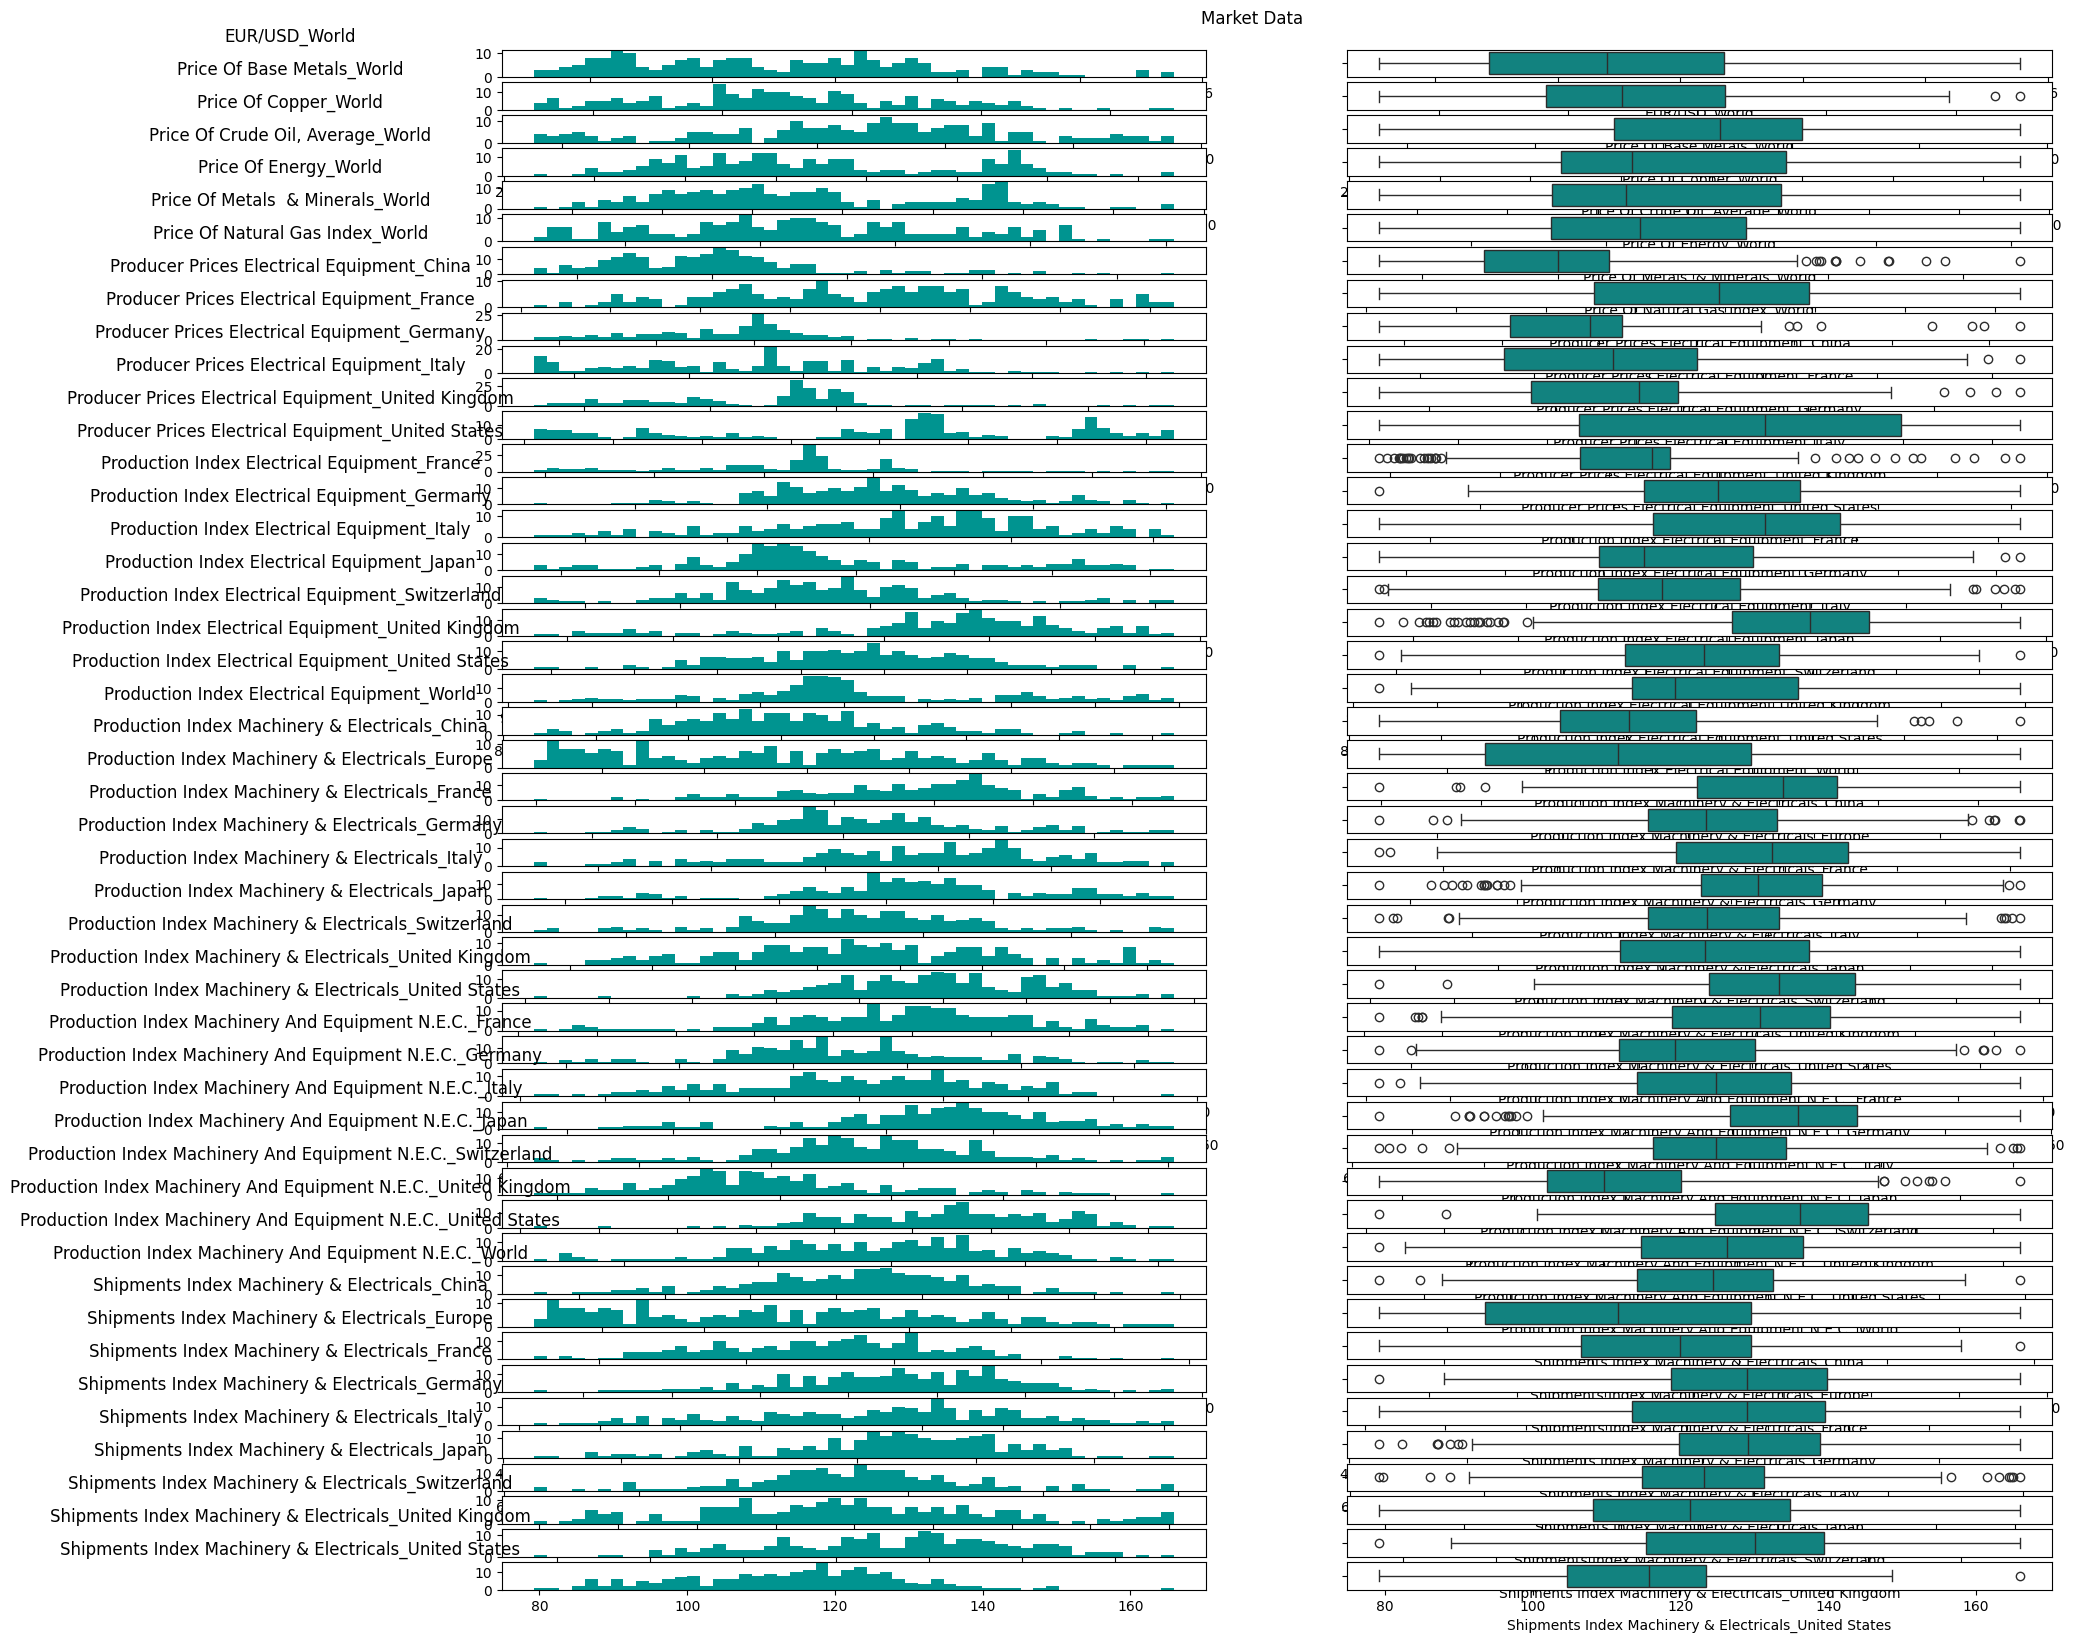

In [44]:
#plot all values 

hist_box_maker(market_data,"Market Data", 20, 20)

In [45]:
market_data[market_data['Producer Prices Electrical Equipment_United Kingdom'].isna()].index

DatetimeIndex(['2020-11-30', '2020-12-31', '2021-01-31', '2021-02-28',
               '2021-03-31', '2021-04-30', '2021-05-31', '2021-06-30',
               '2021-07-31', '2021-08-31', '2021-09-30', '2021-10-31',
               '2021-11-30', '2021-12-31', '2022-01-31', '2022-02-28',
               '2022-03-31', '2022-04-30'],
              dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Producer Prices Electrical Equipment United Kingdom'}, xlabel='date'>

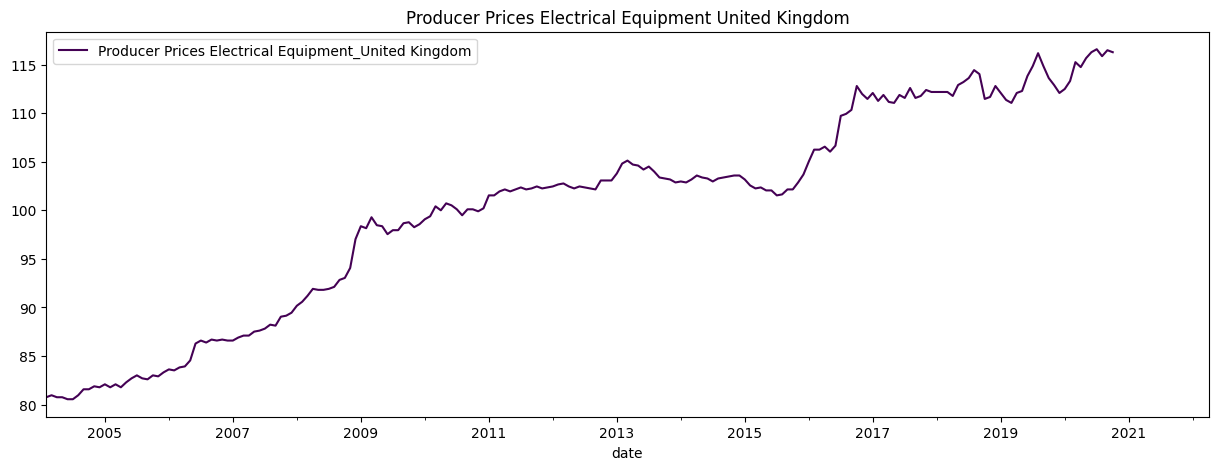

In [46]:
#plot all values
market_data.plot(y="Producer Prices Electrical Equipment_United Kingdom",cmap='viridis',figsize=(15,5),title="Producer Prices Electrical Equipment United Kingdom")

In [47]:
market_data[market_data['Producer Prices Electrical Equipment_France'].isna()].index

DatetimeIndex(['2004-02-29', '2004-03-31', '2004-04-30', '2004-05-31',
               '2004-06-30', '2004-07-31', '2004-08-31', '2004-09-30',
               '2004-10-31', '2004-11-30', '2004-12-31', '2005-01-31',
               '2005-02-28', '2005-03-31', '2005-04-30', '2005-05-31',
               '2005-06-30', '2005-07-31', '2005-08-31', '2005-09-30',
               '2005-10-31', '2005-11-30', '2005-12-31', '2006-01-31',
               '2006-02-28', '2006-03-31', '2006-04-30', '2006-05-31',
               '2006-06-30', '2006-07-31', '2006-08-31', '2006-09-30',
               '2006-10-31', '2006-11-30', '2006-12-31'],
              dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Producer Prices Electrical Equipment France'}, xlabel='date'>

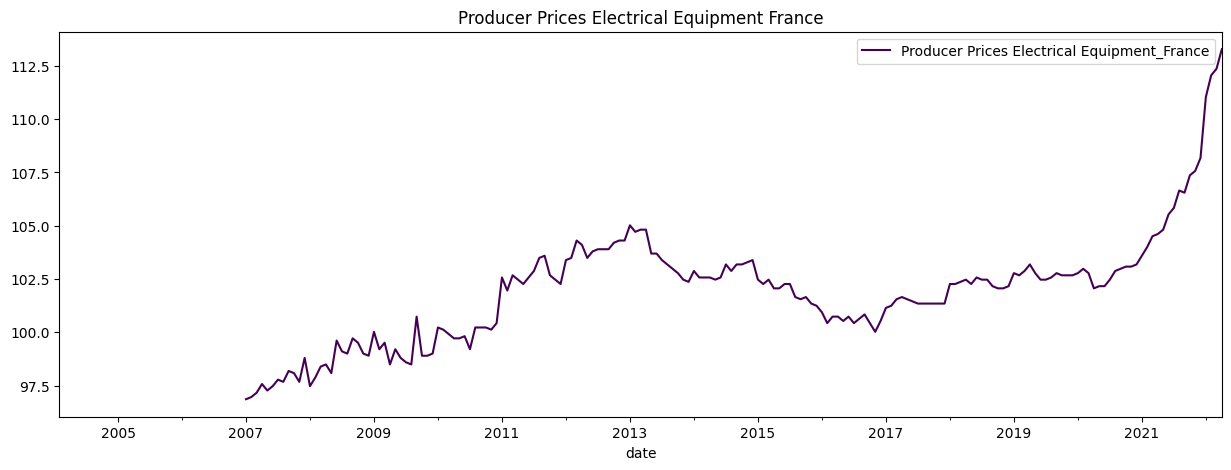

In [48]:
market_data.plot(y="Producer Prices Electrical Equipment_France",cmap='viridis',figsize=(15,5),title="Producer Prices Electrical Equipment France")

In [49]:
market_data[market_data['Producer Prices Electrical Equipment_United Kingdom'].isna()].index

DatetimeIndex(['2020-11-30', '2020-12-31', '2021-01-31', '2021-02-28',
               '2021-03-31', '2021-04-30', '2021-05-31', '2021-06-30',
               '2021-07-31', '2021-08-31', '2021-09-30', '2021-10-31',
               '2021-11-30', '2021-12-31', '2022-01-31', '2022-02-28',
               '2022-03-31', '2022-04-30'],
              dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Producer Prices Electrical Equipment United Kingdom'}, xlabel='date'>

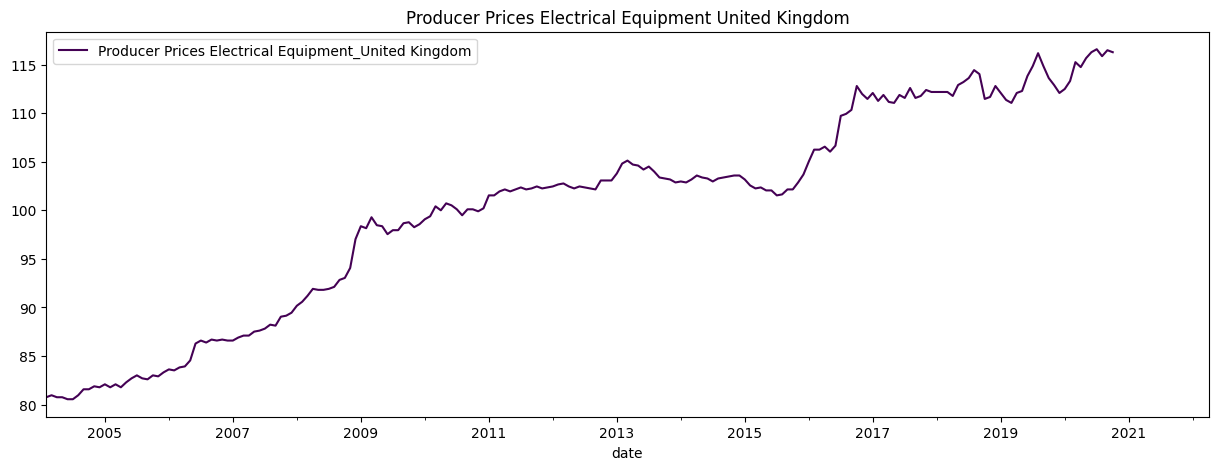

In [50]:
#plot all values
market_data.plot(y="Producer Prices Electrical Equipment_United Kingdom",cmap='viridis',figsize=(15,5),title="Producer Prices Electrical Equipment United Kingdom")

In [51]:
market_data[market_data['Production Index Electrical Equipment_Switzerland'].isna()].index

DatetimeIndex(['2022-04-30'], dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Production Index Electrical Equipment Switzerland'}, xlabel='date'>

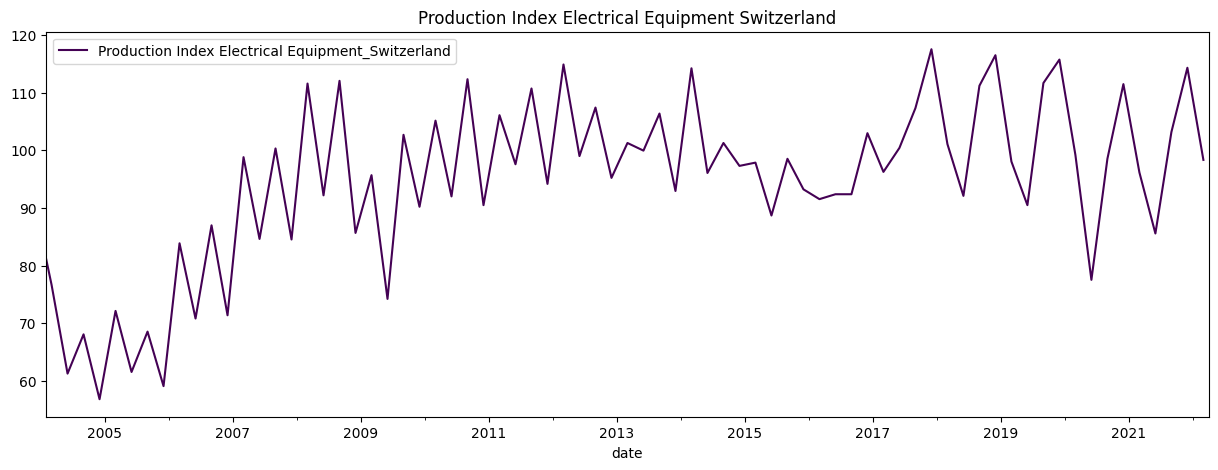

In [52]:
market_data.plot(y="Production Index Electrical Equipment_Switzerland",cmap='viridis',figsize=(15,5),title="Production Index Electrical Equipment Switzerland")

In [53]:
market_data[market_data['Production Index Electrical Equipment_World'].isna()].index

DatetimeIndex(['2004-02-29', '2004-03-31', '2004-04-30', '2004-05-31',
               '2004-06-30', '2004-07-31', '2004-08-31', '2004-09-30',
               '2004-10-31', '2004-11-30', '2004-12-31'],
              dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Production Index Electrical Equipment World'}, xlabel='date'>

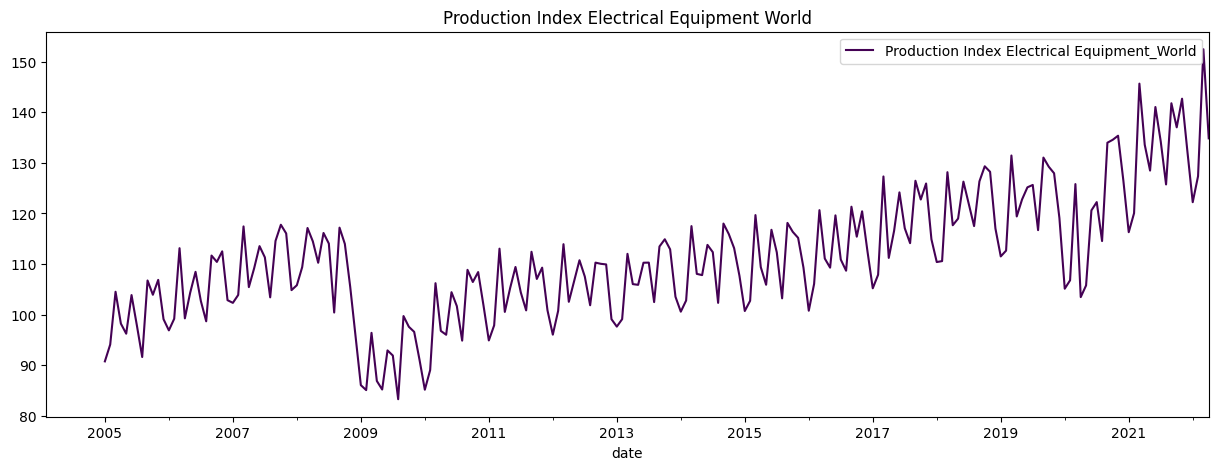

In [54]:
market_data.plot(y="Production Index Electrical Equipment_World",cmap='viridis',figsize=(15,5),title="Production Index Electrical Equipment World")

In [55]:
market_data[market_data['Production Index Machinery & Electricals_Switzerland'].isna()].index

DatetimeIndex(['2022-04-30'], dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Production Index Machinery & Electricals Switzerland'}, xlabel='date'>

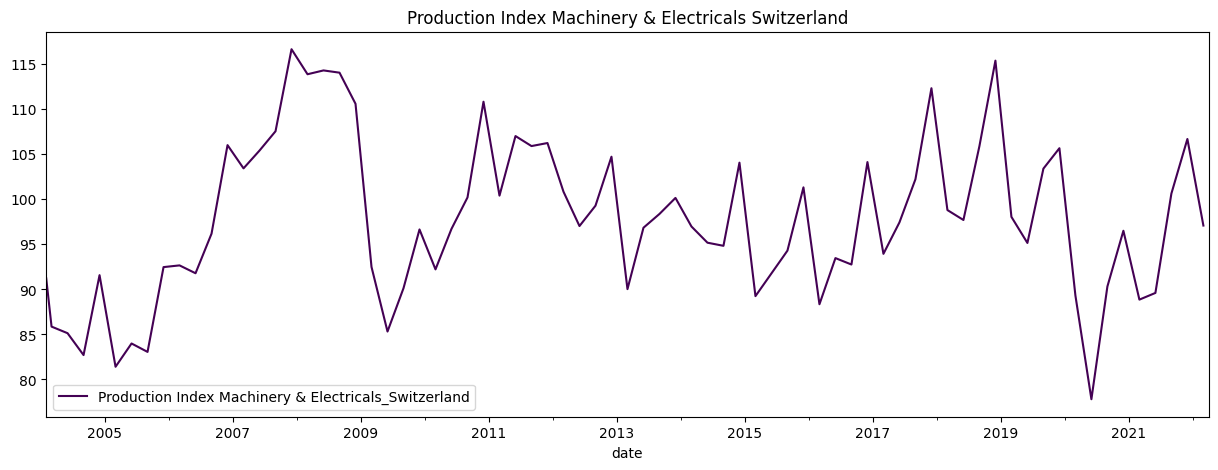

In [56]:
#plot all values
market_data.plot(y="Production Index Machinery & Electricals_Switzerland",cmap='viridis',figsize=(15,5),title="Production Index Machinery & Electricals Switzerland")

In [57]:
market_data[market_data['Production Index Machinery And Equipment N.E.C._Switzerland'].isna()].index

DatetimeIndex(['2022-04-30'], dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Production Index Machinery And Equipment N.E.C. Switzerland'}, xlabel='date'>

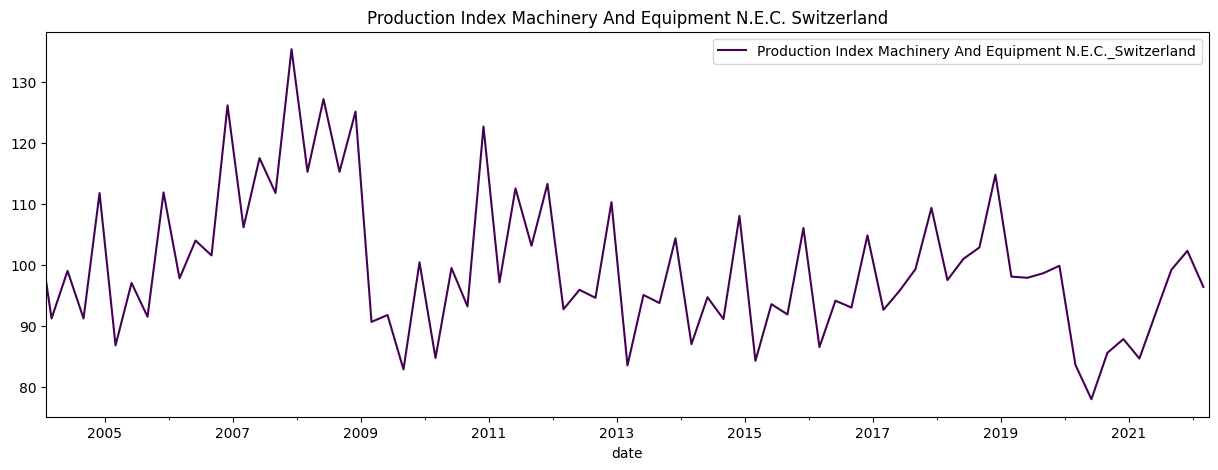

In [58]:
market_data.plot(y="Production Index Machinery And Equipment N.E.C._Switzerland",cmap='viridis',figsize=(15,5),title="Production Index Machinery And Equipment N.E.C. Switzerland")

In [59]:
market_data[market_data['Shipments Index Machinery & Electricals_Switzerland'].isna()].index

DatetimeIndex(['2022-04-30'], dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Shipments Index Machinery & Electricals Switzerland'}, xlabel='date'>

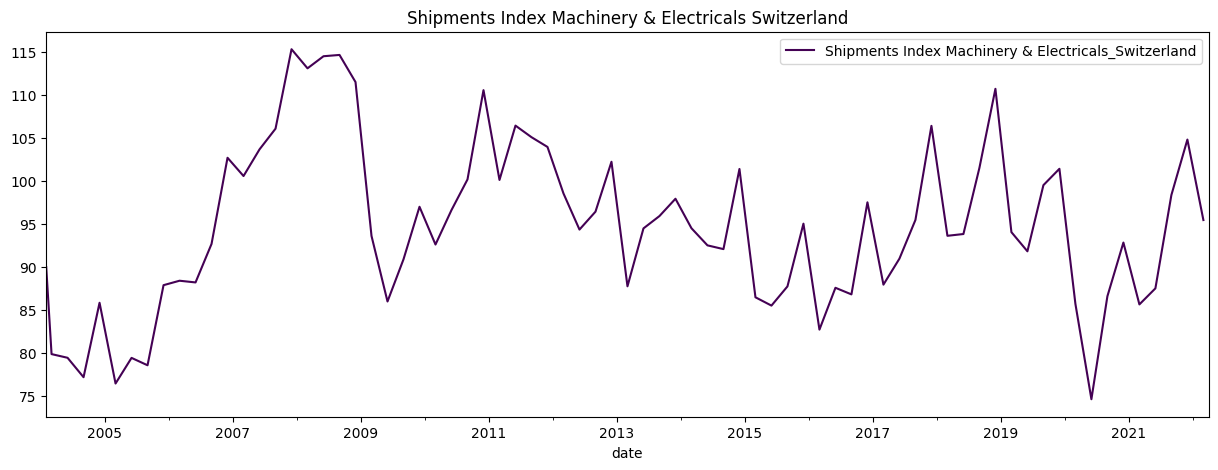

In [60]:
market_data.plot(y="Shipments Index Machinery & Electricals_Switzerland",cmap='viridis',figsize=(15,5),title="Shipments Index Machinery & Electricals Switzerland")

In [61]:
#Dates where there is no values
market_data[market_data['Shipments Index Machinery & Electricals_United Kingdom'].isna()].index

DatetimeIndex(['2020-11-30', '2020-12-31', '2021-01-31', '2021-02-28',
               '2021-03-31', '2021-04-30', '2021-05-31', '2021-06-30',
               '2021-07-31', '2021-08-31', '2021-09-30', '2021-10-31',
               '2021-11-30', '2021-12-31', '2022-01-31', '2022-02-28',
               '2022-03-31', '2022-04-30'],
              dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Shipments Index Machinery & Electricals United Kingdom'}, xlabel='date'>

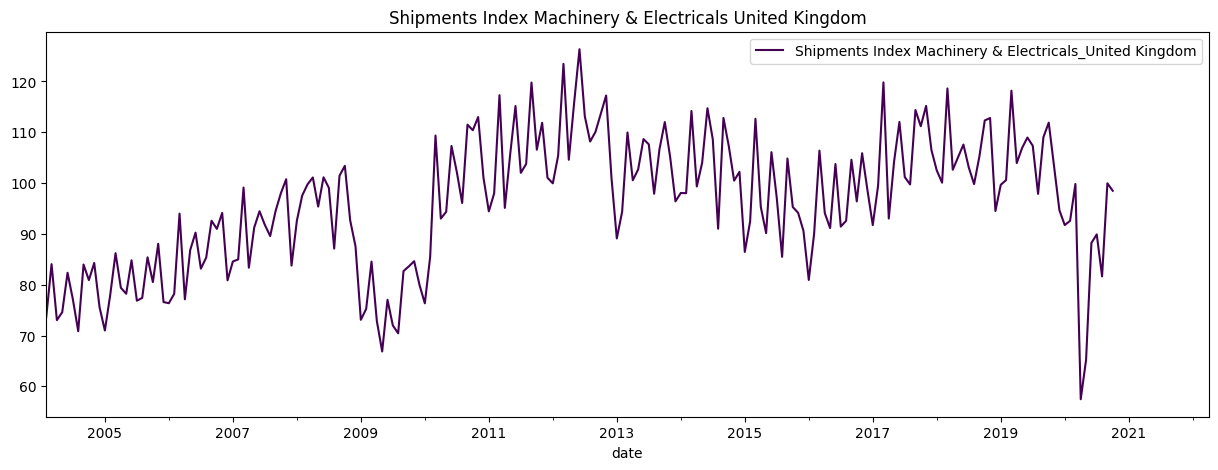

In [62]:
market_data.plot(y="Shipments Index Machinery & Electricals_United Kingdom",cmap='viridis',figsize=(15,5),title="Shipments Index Machinery & Electricals United Kingdom")

In [63]:
market_data[market_data['Shipments Index Machinery & Electricals_United States'].isna()].index

DatetimeIndex(['2022-04-30'], dtype='datetime64[ns]', name='date', freq=None)

<Axes: title={'center': 'Shipments Index Machinery & Electricals United States'}, xlabel='date'>

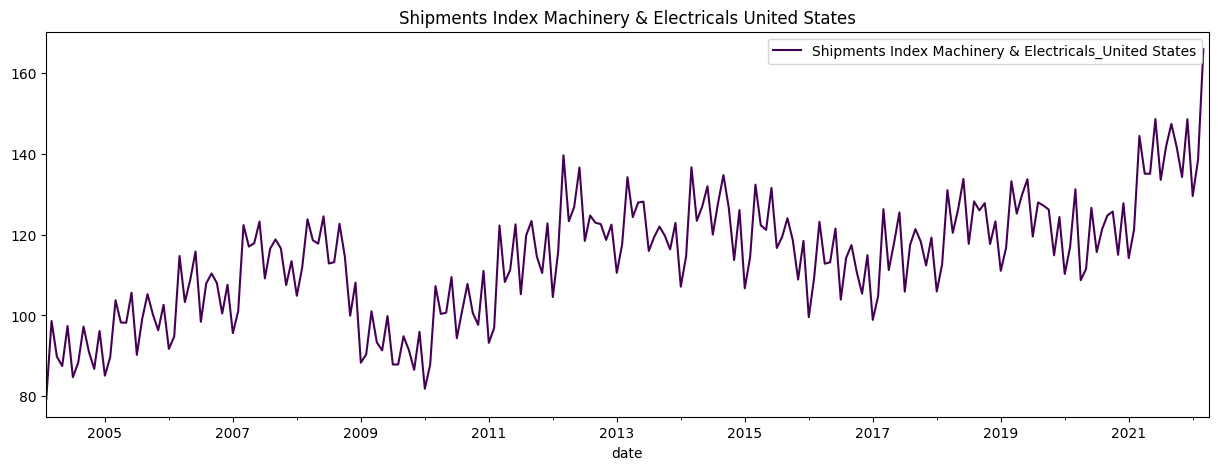

In [64]:
market_data.plot(y="Shipments Index Machinery & Electricals_United States",cmap='viridis',figsize=(15,5),title="Shipments Index Machinery & Electricals United States")

In [65]:
stats = market_data.describe().T
duplicate_stats = stats.duplicated(keep=False)
same_stats_columns = stats[duplicate_stats]
same_stats_columns

,count,mean,std,min,25%,50%,75%,max
,,,,,,,,
Production Index Machinery & Electricals_China,219.0,138.303637,78.883209,16.940704,68.47774,133.50769,198.473934,329.413367
Shipments Index Machinery & Electricals_China,219.0,138.303637,78.883209,16.940704,68.47774,133.50769,198.473934,329.413367


In [66]:
#checking for duplicates
market_data[market_data.duplicated()]

,EUR/USD_World,Price Of Base Metals_World,Price Of Copper_World,"Price Of Crude Oil, Average_World",Price Of Energy_World,Price Of Metals & Minerals_World,Price Of Natural Gas Index_World,Producer Prices Electrical Equipment_China,Producer Prices Electrical Equipment_France,Producer Prices Electrical Equipment_Germany,Producer Prices Electrical Equipment_Italy,Producer Prices Electrical Equipment_United Kingdom,Producer Prices Electrical Equipment_United States,Production Index Electrical Equipment_France,Production Index Electrical Equipment_Germany,Production Index Electrical Equipment_Italy,Production Index Electrical Equipment_Japan,Production Index Electrical Equipment_Switzerland,Production Index Electrical Equipment_United Kingdom,Production Index Electrical Equipment_United States,Production Index Electrical Equipment_World,Production Index Machinery & Electricals_China,Production Index Machinery & Electricals_Europe,Production Index Machinery & Electricals_France,Production Index Machinery & Electricals_Germany,Production Index Machinery & Electricals_Italy,Production Index Machinery & Electricals_Japan,Production Index Machinery & Electricals_Switzerland,Production Index Machinery & Electricals_United Kingdom,Production Index Machinery & Electricals_United States,Production Index Machinery And Equipment N.E.C._France,Production Index Machinery And Equipment N.E.C._Germany,Production Index Machinery And Equipment N.E.C._Italy,Production Index Machinery And Equipment N.E.C._Japan,Production Index Machinery And Equipment N.E.C._Switzerland,Production Index Machinery And Equipment N.E.C._United Kingdom,Production Index Machinery And Equipment N.E.C._United States,Production Index Machinery And Equipment N.E.C._World,Shipments Index Machinery & Electricals_China,Shipments Index Machinery & Electricals_Europe,Shipments Index Machinery & Electricals_France,Shipments Index Machinery & Electricals_Germany,Shipments Index Machinery & Electricals_Italy,Shipments Index Machinery & Electricals_Japan,Shipments Index Machinery & Electricals_Switzerland,Shipments Index Machinery & Electricals_United Kingdom,Shipments Index Machinery & Electricals_United States
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [67]:
market_data

,EUR/USD_World,Price Of Base Metals_World,Price Of Copper_World,"Price Of Crude Oil, Average_World",Price Of Energy_World,Price Of Metals & Minerals_World,Price Of Natural Gas Index_World,Producer Prices Electrical Equipment_China,Producer Prices Electrical Equipment_France,Producer Prices Electrical Equipment_Germany,Producer Prices Electrical Equipment_Italy,Producer Prices Electrical Equipment_United Kingdom,Producer Prices Electrical Equipment_United States,Production Index Electrical Equipment_France,Production Index Electrical Equipment_Germany,Production Index Electrical Equipment_Italy,Production Index Electrical Equipment_Japan,Production Index Electrical Equipment_Switzerland,Production Index Electrical Equipment_United Kingdom,Production Index Electrical Equipment_United States,Production Index Electrical Equipment_World,Production Index Machinery & Electricals_China,Production Index Machinery & Electricals_Europe,Production Index Machinery & Electricals_France,Production Index Machinery & Electricals_Germany,Production Index Machinery & Electricals_Italy,Production Index Machinery & Electricals_Japan,Production Index Machinery & Electricals_Switzerland,Production Index Machinery & Electricals_United Kingdom,Production Index Machinery & Electricals_United States,Production Index Machinery And Equipment N.E.C._France,Production Index Machinery And Equipment N.E.C._Germany,Production Index Machinery And Equipment N.E.C._Italy,Production Index Machinery And Equipment N.E.C._Japan,Production Index Machinery And Equipment N.E.C._Switzerland,Production Index Machinery And Equipment N.E.C._United Kingdom,Production Index Machinery And Equipment N.E.C._United States,Production Index Machinery And Equipment N.E.C._World,Shipments Index Machinery & Electricals_China,Shipments Index Machinery & Electricals_Europe,Shipments Index Machinery & Electricals_France,Shipments Index Machinery & Electricals_Germany,Shipments Index Machinery & Electricals_Italy,Shipments Index Machinery & Electricals_Japan,Shipments Index Machinery & Electricals_Switzerland,Shipments Index Machinery & Electricals_United Kingdom,Shipments Index Machinery & Electricals_United States
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-02-29,1.2646,54.039811,36.623832,39.639458,44.123338,48.747945,87.076974,NaN,NaN,93.230453,93.020027,80.757423,78.969864,102.077057,85.913200,141.510864,106.161262,81.100000,120.706516,117.723991,NaN,16.940704,97.122911,112.091273,82.623037,124.289603,109.334010,91.221862,111.353812,107.601400,118.274109,80.829010,116.790276,110.890034,97.100000,106.191977,102.491722,97.597374,16.940704,80.098530,83.458866,79.452532,86.560493,110.495272,89.987275,73.601265,79.240230
2004-03-31,1.2262,54.666162,39.931055,42.592034,47.588957,49.256157,87.192705,NaN,NaN,93.335678,93.540268,80.962135,79.673569,117.225685,97.670815,152.880234,140.288741,76.690307,138.309550,119.220779,NaN,23.711852,113.783904,136.327976,100.556582,143.411662,140.884616,85.866287,127.558608,110.187364,148.121841,102.130104,139.288391,141.176853,91.195116,121.625075,105.627480,113.224892,23.711852,96.015929,106.168192,97.012918,106.344544,144.686166,79.883583,84.047595,98.619024
2004-04-30,1.1985,54.872715,39.134854,42.650637,47.779013,49.423751,91.379923,NaN,NaN,93.440903,93.852425,80.757423,80.337639,105.335777,87.253983,137.796875,106.271197,71.552403,115.557330,117.441124,NaN,24.435235,101.715199,117.791806,89.653203,129.083828,105.853579,85.622508,108.732297,108.166564,125.482231,90.961426,125.289566,105.648765,93.793535,104.965505,103.484955,100.169090,24.435235,85.167236,92.007646,84.932358,95.579673,102.655769,79.740802,73.026027,89.774031
2004-05-31,1.2007,51.230356,36.278433,47.517121,53.590898,46.468392,99.044520,NaN,NaN,93.546127,93.852425,80.757423,80.798828,96.616508,84.675552,143.860535,101.608710,66.414500,119.269534,117.899216,NaN,23.708115,101.275727,109.002541,86.880571,135.590391,101.864777,85.378729,110.645200,108.425887,116.649750,88.08290

<a class="anchor" id="sales_exploration">
    
## 5.2. Sales Data
    
</a>

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43 entries, 2018-10-31 to 2022-04-30
Freq: ME
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GCK_1   43 non-null     float64
 1   GCK_3   43 non-null     float64
 2   GCK_4   43 non-null     float64
 3   GCK_5   43 non-null     float64
 4   GCK_6   43 non-null     float64
 5   GCK_8   43 non-null     float64
 6   GCK_9   43 non-null     float64
 7   GCK_11  43 non-null     float64
 8   GCK_12  43 non-null     float64
 9   GCK_13  43 non-null     float64
 10  GCK_14  43 non-null     float64
 11  GCK_16  43 non-null     float64
 12  GCK_20  43 non-null     float64
 13  GCK_36  43 non-null     float64
dtypes: float64(14)
memory usage: 5.0 KB


In [69]:
df.head()

Mapped_GCK,GCK_1,GCK_3,GCK_4,GCK_5,GCK_6,GCK_8,GCK_9,GCK_11,GCK_12,GCK_13,GCK_14,GCK_16,GCK_20,GCK_36
date,,,,,,,,,,,,,,
2018-10-31,36098918.79,8089465.96,397760.69,2499061.19,369231.60,586052.74,3219.32,1021303.50,28686.33,27666.10,5770.0,333196.87,4563.14,6474.60
2018-11-30,5140760.00,11863001.51,371322.42,8993944.04,473046.96,526292.77,1875.90,1898844.80,1070.00,68180.00,17130.0,1377694.32,5798.14,21617.61
2018-12-31,37889612.12,8736859.39,430100.96,6947507.31,999472.69,271490.71,0.00,1226122.00,17880.60,15655.18,0.0,4762524.66,918.65,13924.52
2019-01-31,27728148.35,10705300.63,484173.88,8233205.07,598874.10,381400.15,1487.00,2216391.74,21484.00,27198.29,1686.4,942957.19,2398.04,15444.39
2019-02-28,34793163.53,10167796.86,620031.80,6879250.99,542037.52,368475.57,3234.28,610456.60,34214.74,32638.63,19196.3,257765.04,620.66,8051.15


<a class="anchor" id="subtitle6.2.1">
    
### 6.2.1. Missing Values 
    
</a>

In [70]:
df.isna().sum()
#There are no missing values

Mapped_GCK
GCK_1     0
GCK_3     0
GCK_4     0
GCK_5     0
GCK_6     0
GCK_8     0
GCK_9     0
GCK_11    0
GCK_12    0
GCK_13    0
GCK_14    0
GCK_16    0
GCK_20    0
GCK_36    0
dtype: int64

<a class="anchor" id="subtitle6.2.2">
    
### 6.2.2.Duplicated Columns/GCK Sales
    
</a>

In [71]:
# Checking columns with same descriptive statistics
describe_df=df.describe().T
describe_df[describe_df.duplicated(keep=False)]
#There are no GCK with the same sales.

,count,mean,std,min,25%,50%,75%,max
Mapped_GCK,,,,,,,,


<a class="anchor" id="subtitle6.2.3">
    
### 6.2.3. Duplicated Values
    
</a>

In [72]:
df.duplicated(keep=False).sum()
#There are 3 rows with the same values

0

In [73]:
df[df.duplicated(keep=False)]
#All the values are of 0 sales, so they will be kept.

Mapped_GCK,GCK_1,GCK_3,GCK_4,GCK_5,GCK_6,GCK_8,GCK_9,GCK_11,GCK_12,GCK_13,GCK_14,GCK_16,GCK_20,GCK_36
date,,,,,,,,,,,,,,


<a class="anchor" id="subtitle6.2.4">
    
### 6.2.4. Outlier Detection
    
</a>

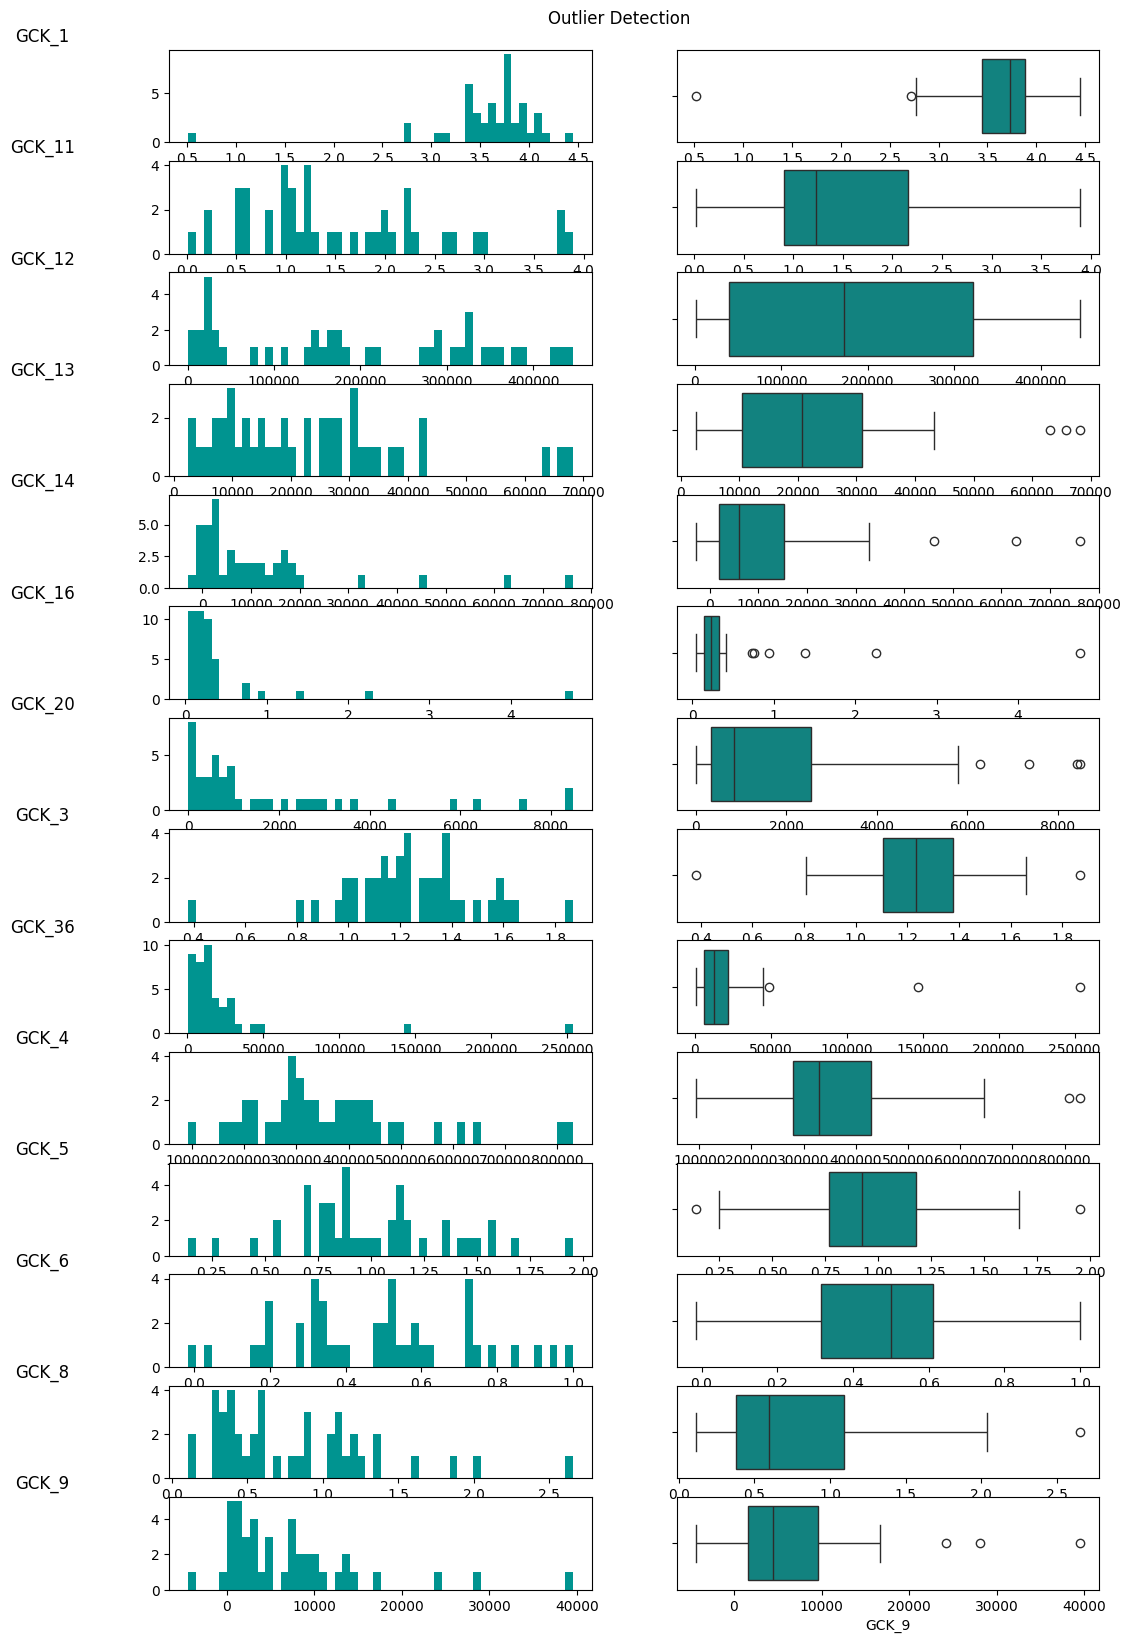

In [74]:
hist_box_maker(df,"Outlier Detection",12,20)
# Analysis of the distributions:
## For GCK1, remove any data points that are less than 2.5.
## For GCK13, remove any data points that are greater than 50000.
## For GCK14, remove any data points that are greater than 30000.
## For GCK16, remove any data points that are greater than 1.
## For GCK20, remove any data points that are greater than 60000.
## For GCK3, remove any data points that are less than 0.8 or greater than 1.8.
## For GCK_36, remove any data points that are greater than 100000.
## For GCK4, remove any data points that are greater than 700000.
## For GCK8, remove any data points that are greater than 2.5.
## For GCK9, remove any data points that are greater than 30000.

<a class="anchor" id="subtitle6.2.5">
    
### 6.2.5. Descriptive Statistics
    
</a>

In [75]:
df.describe(include='all').T
# There are 60 rows with no missing values.
# The date goes from 2018-01-10 up to 2022-12-04.
# There are 14 unique GCKs.

# Hard to detect distribution skeweness from this analysis so it will be further analysed.

,count,mean,std,min,25%,50%,75%,max
Mapped_GCK,,,,,,,,
GCK_1,43.0,3.591177e+07,5.905117e+06,5140760.00,3.440896e+07,37323903.07,3.888867e+07,44483013.86
GCK_3,43.0,1.240566e+07,2.577332e+06,3804319.74,1.105907e+07,12317479.75,1.377567e+07,18686819.85
GCK_4,43.0,3.634234e+05,1.557109e+05,93226.32,2.797995e+05,329430.96,4.281611e+05,829442.33
GCK_5,43.0,9.990585e+06,3.731564e+06,1405295.36,7.703432e+06,9232237.68,1.180077e+07,19524640.52
GCK_6,43.0,4.800440e+05,2.422862e+05,-15202.96,3.160555e+05,499147.73,6.119871e+05,999472.69
GCK_8,43.0,8.109586e+05,5.436111e+05,111791.34,3.749379e+05,599831.93,1.092310e+06,2655036.78
GCK_9,43.0,7.173175e+03,8.231269e+03,-4358.10,1.626700e+03,4488.09,9.583200e+03,39510.75
GCK_11,43.0,1.532589e+06,9.811598e+05,18200.00,9.035992e+05,1226122.00,2.161184e+06,3891447.76
GCK_12,43.0,1.925462e+05,1.410168e+05,1070.00,3.923521e+04,172712.88,3.217951e+05,445648.06


<a class="anchor" id="subtitle6.2.6">
    
### 6.2.6. Stationarity (significance level 1%) and ACF and PACF Analysis
    
</a>

**Product 1**

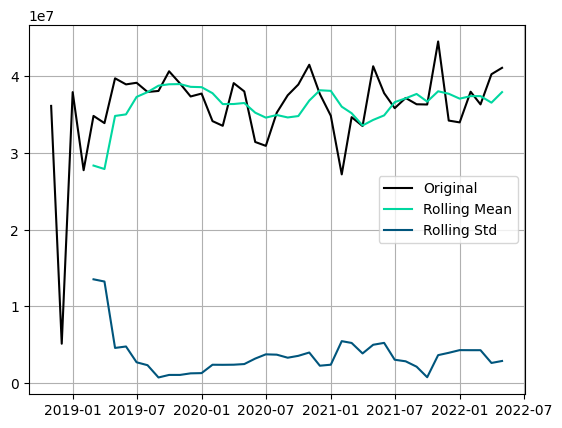

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -6.002443e+00
p-value                        1.645124e-07
#Lags Used                     0.000000e+00
Number of Observations Used    4.200000e+01
Critical Value (1%)           -3.596636e+00
Critical Value (5%)           -2.933297e+00
Critical Value (10%)          -2.604991e+00
dtype: float64


In [76]:
#Verifying stationarity for product 1

stationarity_verification (df, 'GCK_1')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationary. 
#Therefore, product 1 does not have seasonality and trend

#The rolling mean and rolling std are approximately constant over time.

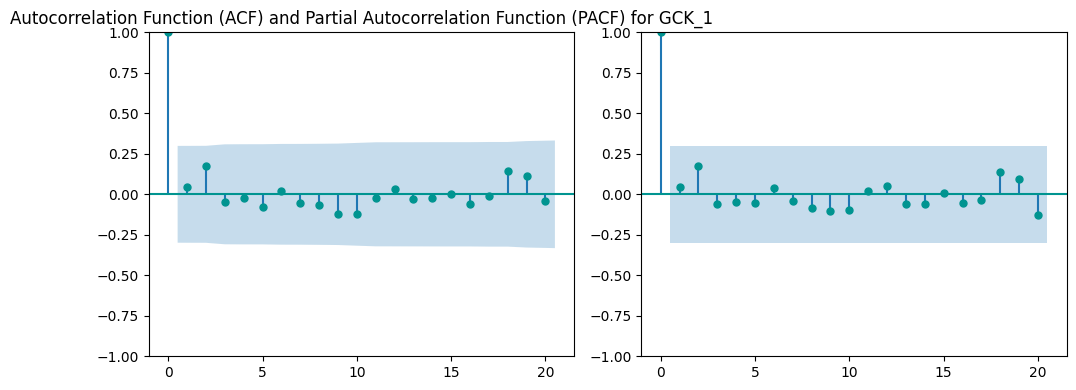

In [77]:
# This code will calculate and plot the ACF and PACF for the 'GCK_1' time series in the df DataFrame
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_1') 

# According to the graphs there is no autocorrection for produtct 1, so we cannot use lag variables to predict

**Product 3**

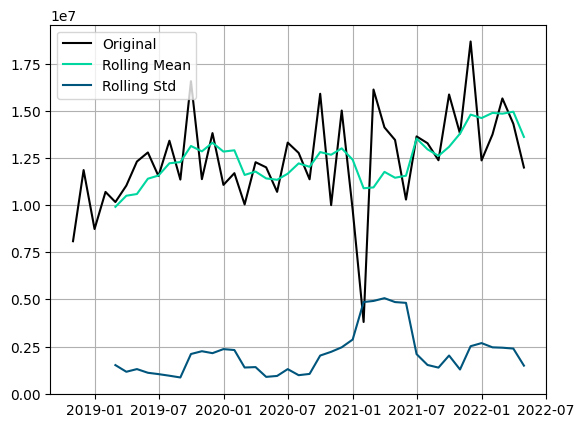

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -6.590291e+00
p-value                        7.142768e-09
#Lags Used                     0.000000e+00
Number of Observations Used    4.200000e+01
Critical Value (1%)           -3.596636e+00
Critical Value (5%)           -2.933297e+00
Critical Value (10%)          -2.604991e+00
dtype: float64


In [78]:
# Verifying stationarity for product 3

stationarity_verification (df, 'GCK_3')

# Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data 
#is stationary. Therefore, product 3 does not have seasonality and trend

# The rolling mean and rolling std are approximately constant over time.

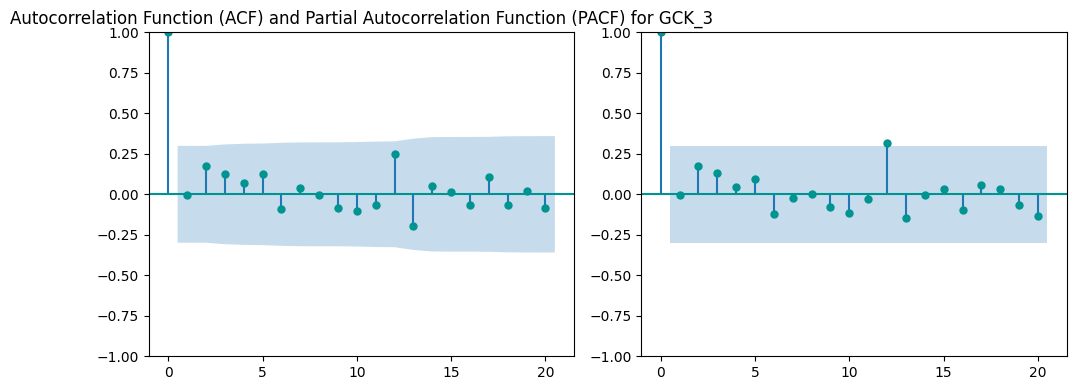

In [79]:
# This code will calculate and plot the ACF and PACF for the 'GCK_3' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_3')

# According to the graphs there is no total autocorrelation for product 3 as well as partial
#(except only one lag value - 12)

**Product 4**

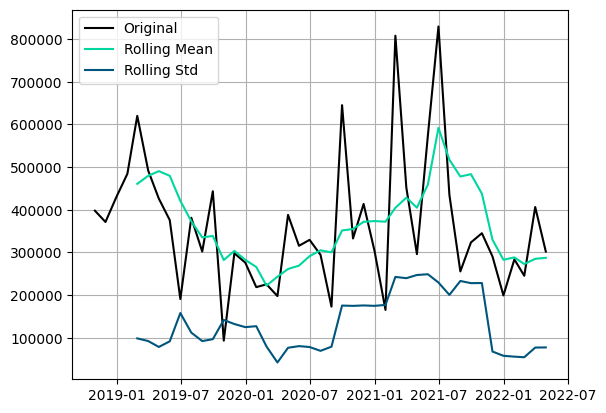

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -5.319293
p-value                         0.000005
#Lags Used                      0.000000
Number of Observations Used    42.000000
Critical Value (1%)            -3.596636
Critical Value (5%)            -2.933297
Critical Value (10%)           -2.604991
dtype: float64


In [80]:
#Verifying stationarity for product 4

stationarity_verification (df, 'GCK_4')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationary. 
#Therefore, product 4 does not have seasonality and trend

#The rolling mean and rolling std are not constant over time.

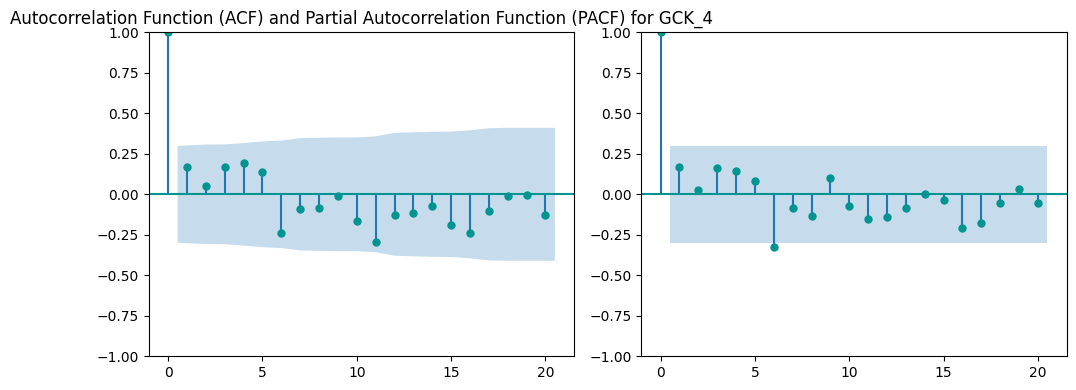

In [81]:
# This code will calculate and plot the ACF and PACF for the 'GCK_4' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_4')

# According to the graphs there is no total autocorrelation for product 4 as well as partial
#(except 6 lag values (6,16,17,18,19,20))

**Product 5**

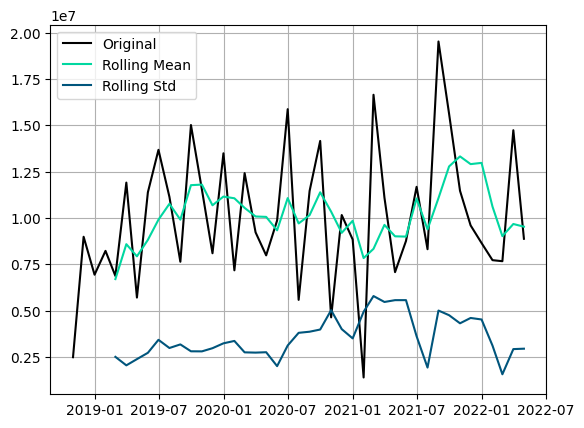

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -7.636228e+00
p-value                        1.949175e-11
#Lags Used                     0.000000e+00
Number of Observations Used    4.200000e+01
Critical Value (1%)           -3.596636e+00
Critical Value (5%)           -2.933297e+00
Critical Value (10%)          -2.604991e+00
dtype: float64


In [82]:
#Verifying stationarity for product 5

stationarity_verification (df, 'GCK_5')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 5 does not have seasonality 

#Both rolling mean and rolling std are approximately constant over time, which confirms the stationarity hypothesis

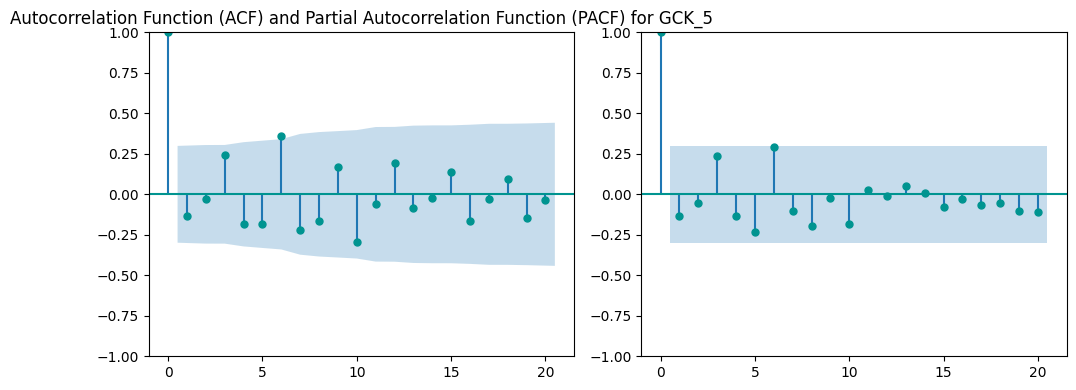

In [83]:
# This code will calculate and plot the ACF and PACF for the 'GCK_5' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_5')

# # According to the graphs there is no total autocorrelation for product 5 as well as partial
#(except 1 lag value for both (6))

**Product 6**

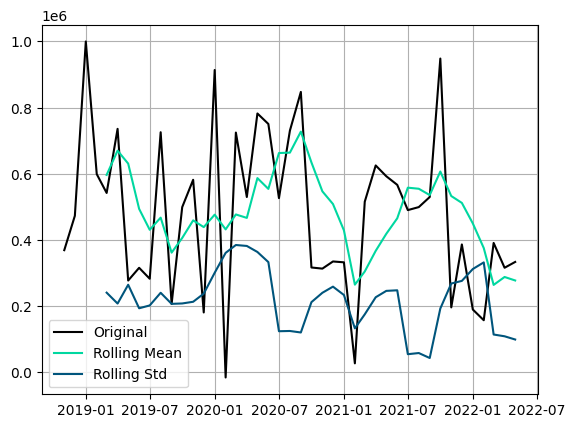

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -3.477762
p-value                         0.008577
#Lags Used                      1.000000
Number of Observations Used    41.000000
Critical Value (1%)            -3.600983
Critical Value (5%)            -2.935135
Critical Value (10%)           -2.605963
dtype: float64


In [84]:
#Verifying stationarity for product 6

stationarity_verification (df, 'GCK_6')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 6 does not have seasonality 

#Both rolling mean and rolling std are not constant over time

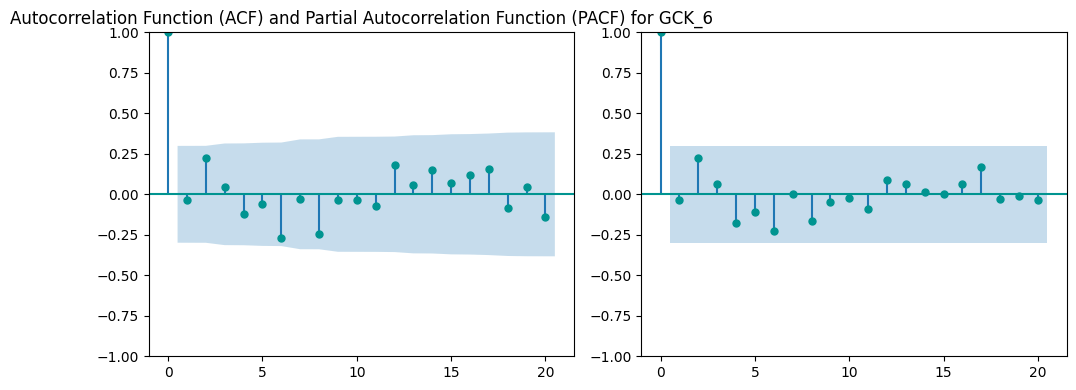

In [85]:
# This code will calculate and plot the ACF and PACF for the 'GCK_6' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_6')

# According to the graphs there is no total autocorrelation for product 6 as well as partial
#(except only one lag values (17))

**Product 8**

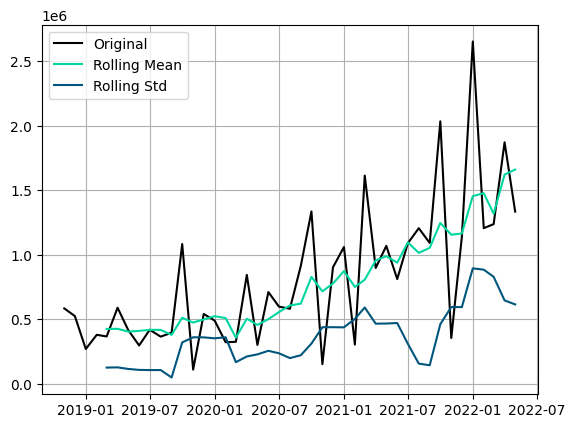

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                  2.340859
p-value                         0.998980
#Lags Used                      6.000000
Number of Observations Used    36.000000
Critical Value (1%)            -3.626652
Critical Value (5%)            -2.945951
Critical Value (10%)           -2.611671
dtype: float64


In [86]:
#Verifying stationarity for product 8

stationarity_verification (df,'GCK_8')

# Since p-value is clearly higher than a significance level of 1%, we do not reject the null hypotheses, 
#therefore, the data is not stationary.
# The product 8 seems to have seasonality and trend patterns

# Both rolling mean and rolling std are increasing over time

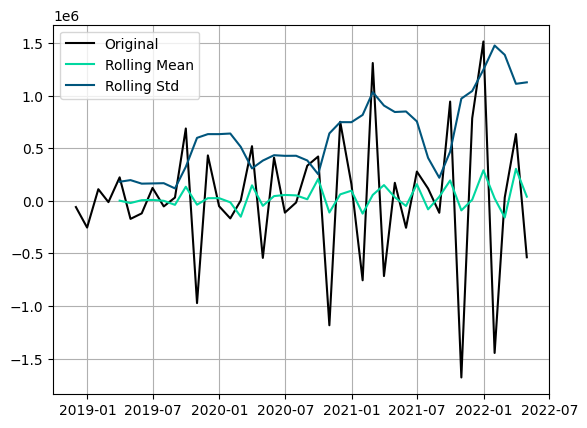

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -4.873763
p-value                         0.000039
#Lags Used                      5.000000
Number of Observations Used    36.000000
Critical Value (1%)            -3.626652
Critical Value (5%)            -2.945951
Critical Value (10%)           -2.611671
dtype: float64


In [87]:
# Before using SARIMA (or ARIMA/ARMA depending on the case), as the series is not stationary, we will try to take 
#first differences and check if the series becomes stationary. If it is we already know that degree of differencing
#is one. If not, we will have to check whether we should differentiate again or seasonally diferentiate.
df_temp = df.copy()
df_temp['GCK_8_DIFF_1'] = df_temp['GCK_8'].diff() 
df_temp['GCK_8_DIFF_1']=df_temp['GCK_8_DIFF_1'].dropna()
GCK_8_DIFF_1 = df_temp['GCK_8_DIFF_1'].dropna()
GCK_8_DIFF_1 = pd.DataFrame(GCK_8_DIFF_1)
stationarity_verification(GCK_8_DIFF_1,'GCK_8_DIFF_1') #Considering the p-value we obtained (<0.05), there is
#statistical evidence suggesting that the series is stationary

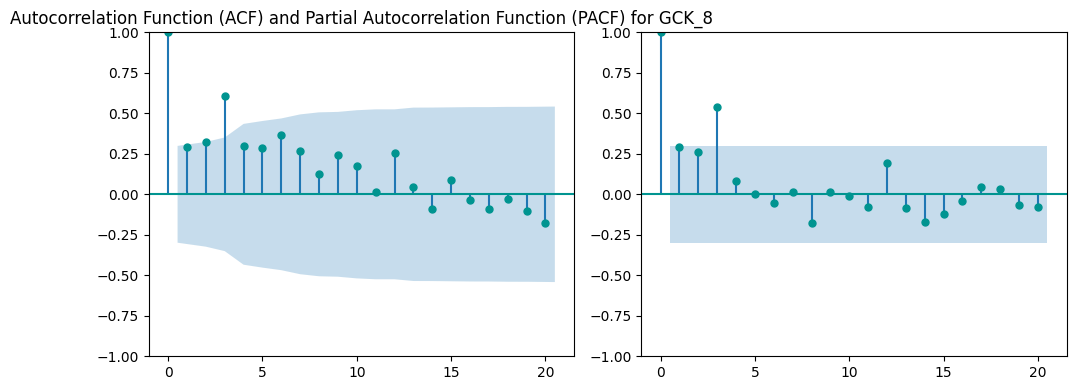

In [88]:
# This code will calculate and plot the ACF and PACF for the 'GCK_8' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_8')

# According to the graphs there is total and partial autocorrection for produtct 8, so we can use lag 3 to predict
#and seem to have seasonality

**Product 9**

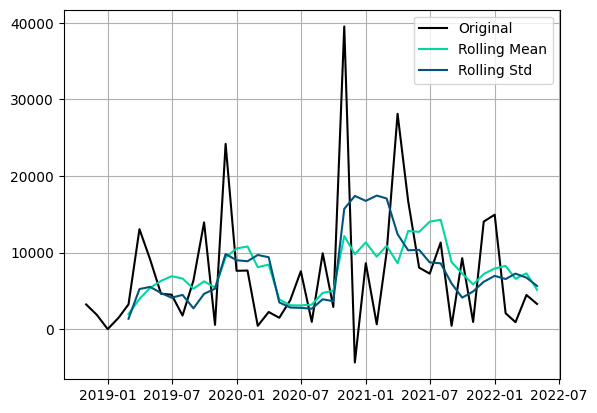

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -7.013494e+00
p-value                        6.825988e-10
#Lags Used                     0.000000e+00
Number of Observations Used    4.200000e+01
Critical Value (1%)           -3.596636e+00
Critical Value (5%)           -2.933297e+00
Critical Value (10%)          -2.604991e+00
dtype: float64


In [89]:
#Verifying stationarity for product 9

stationarity_verification (df,'GCK_9')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 9 does not have seasonality 

#Both rolling mean and rolling std are not constant over time

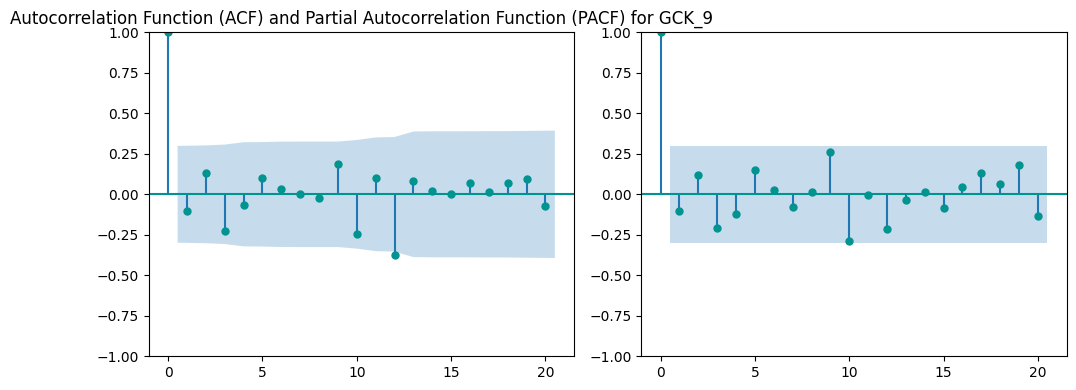

In [90]:
# This code will calculate and plot the ACF and PACF for the 'GCK_9' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_9')

# According to the graphs there is no total autocorrelation for product 9 as well as partial
#(except 5 lag values (9,10,12,19,20) for PACF and only one lag for ACF (12))v

**Product 11**

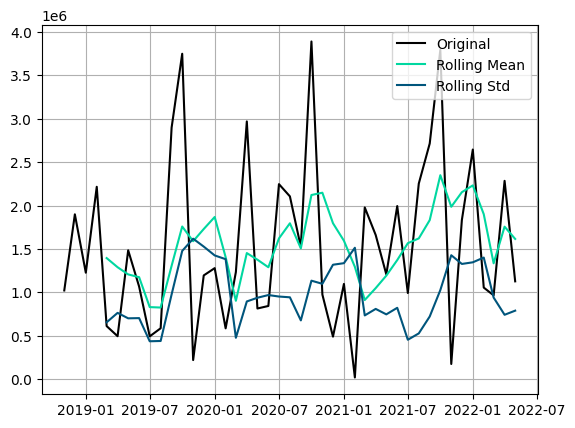

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -5.577923
p-value                         0.000001
#Lags Used                      1.000000
Number of Observations Used    41.000000
Critical Value (1%)            -3.600983
Critical Value (5%)            -2.935135
Critical Value (10%)           -2.605963
dtype: float64


In [91]:
#Verifying stationarity for product 11

stationarity_verification (df,'GCK_11')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 11 does not have seasonality 

#Both rolling mean and rolling std are not constant over time

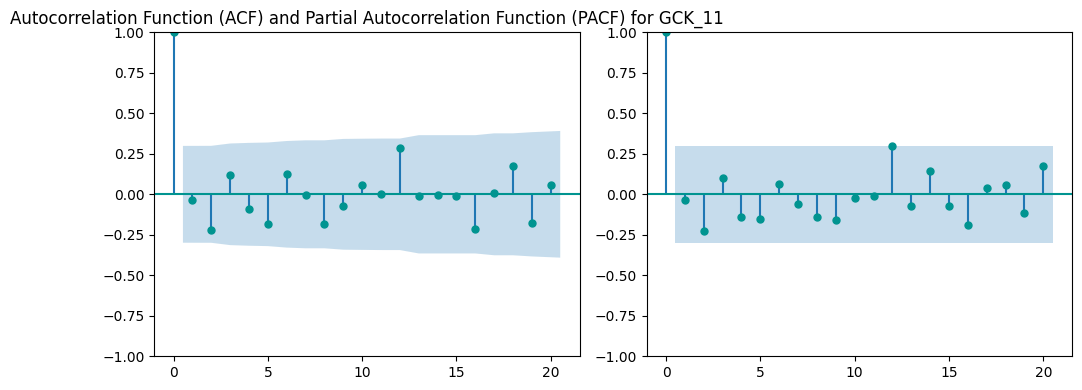

In [92]:
# This code will calculate and plot the ACF and PACF for the 'GCK_11' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_11')

# According to the graphs there is no autocorrection for product 11, so we cannot use lag variables to predict?

**Product 12**

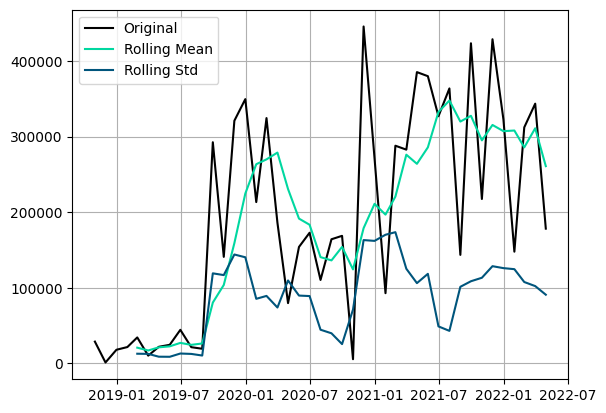

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -3.869337
p-value                         0.002272
#Lags Used                      0.000000
Number of Observations Used    42.000000
Critical Value (1%)            -3.596636
Critical Value (5%)            -2.933297
Critical Value (10%)           -2.604991
dtype: float64


In [93]:
#Verifying stationarity for product 12

stationarity_verification (df,'GCK_12')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 

# The product 12 seems to have seasonality and trend patterns

# Both rolling mean and rolling std are increasing over time

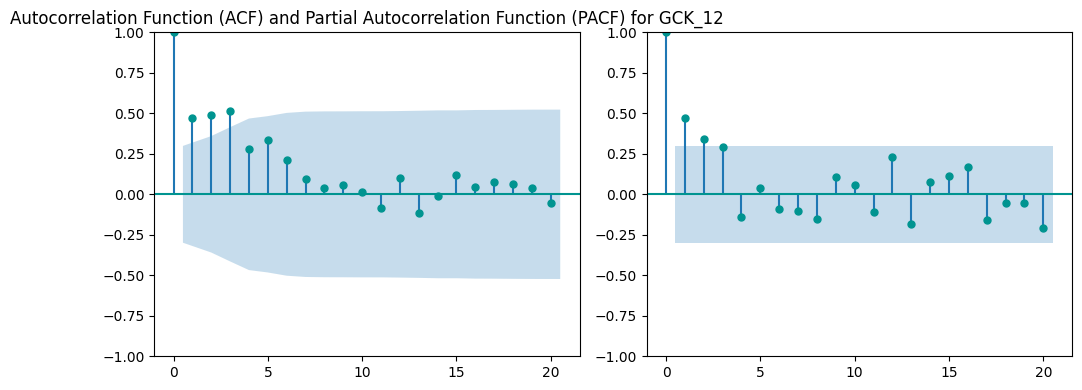

In [94]:
# This code will calculate and plot the ACF and PACF for the 'GCK_12' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_12')

# According to the graphs there is a signficant pattern for product 12 indicantion the possible use of an ARMA(3,3)

**Product 13**

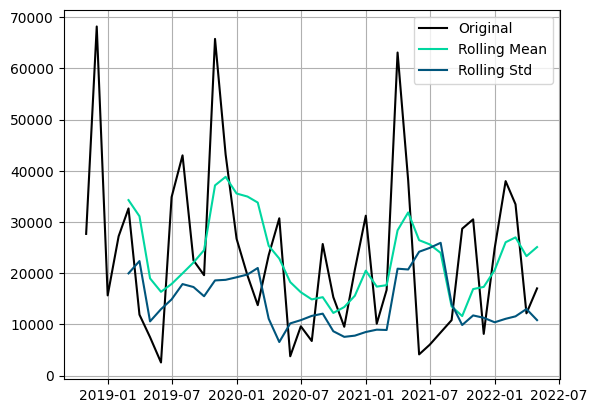

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -3.254199
p-value                         0.017054
#Lags Used                      2.000000
Number of Observations Used    40.000000
Critical Value (1%)            -3.605565
Critical Value (5%)            -2.937069
Critical Value (10%)           -2.606986
dtype: float64


In [95]:
#Verifying stationarity for product 13

stationarity_verification (df,'GCK_13')

# Since p-value is higher than a significance level of 1%, we do not reject the null hypotheses, 
#therefore, the data is not stationary.
# The product 13 seems to have seasonality and trend patterns

# Both rolling mean and rolling std are increasing over time

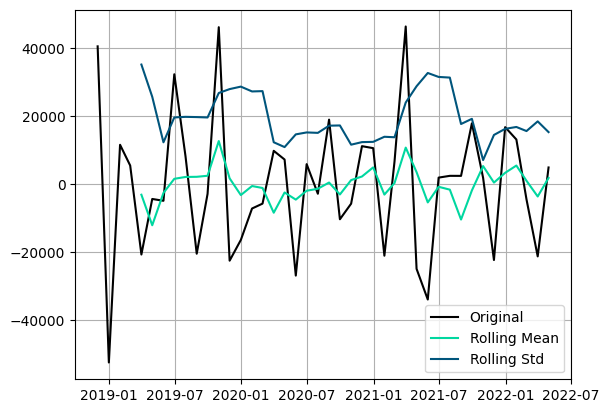

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -8.439475e+00
p-value                        1.779279e-13
#Lags Used                     1.000000e+00
Number of Observations Used    4.000000e+01
Critical Value (1%)           -3.605565e+00
Critical Value (5%)           -2.937069e+00
Critical Value (10%)          -2.606986e+00
dtype: float64


In [96]:
# Before using SARIMA (or ARIMA/ARMA depending on the case), as the series is not stationary, we will try to take 
#first differences and check if the series becomes stationary. If it is we already know that degree of differencing
#is one. If not, we will have to check whether we should differentiate again or seasonally diferentiate.
df_temp=df.copy()
df_temp['GCK_13_DIFF_1'] = df_temp['GCK_13'].diff() 
df_temp['GCK_13_DIFF_1']=df_temp['GCK_13_DIFF_1'].dropna()
GCK_13_DIFF_1 = df_temp['GCK_13_DIFF_1'].dropna()
GCK_13_DIFF_1 = pd.DataFrame(GCK_13_DIFF_1)
stationarity_verification(GCK_13_DIFF_1,'GCK_13_DIFF_1') 
#Considering the p-value we obtained (<0.05), there is
#statistical evidence suggesting that the series is stationary

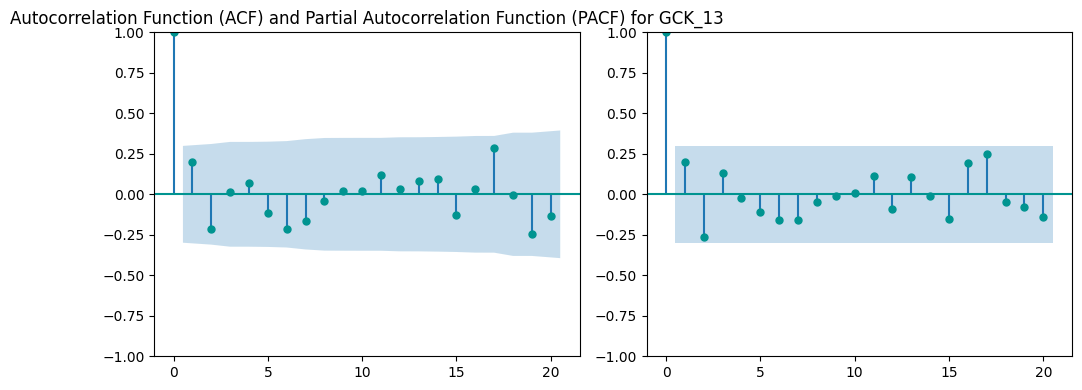

In [97]:
# This code will calculate and plot the ACF and PACF for the 'GCK_13' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df_temp, 'GCK_13')

# According to the graphs there is total and partial autocorrection for produtct 13, so we can use lag 3 to predict
#and seem to have seasonality

**Product 14**

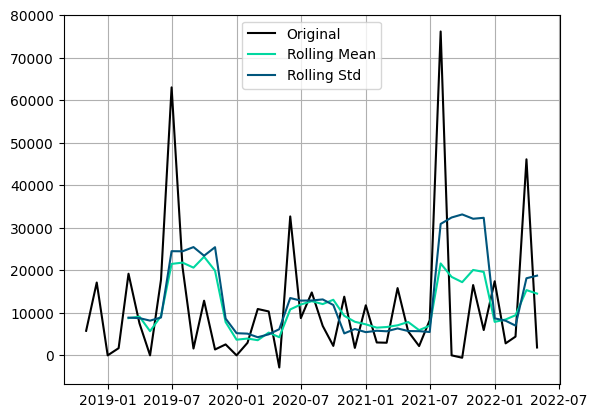

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -6.871822e+00
p-value                        1.508840e-09
#Lags Used                     0.000000e+00
Number of Observations Used    4.200000e+01
Critical Value (1%)           -3.596636e+00
Critical Value (5%)           -2.933297e+00
Critical Value (10%)          -2.604991e+00
dtype: float64


In [98]:
#Verifying stationarity for product 14

stationarity_verification (df,'GCK_14')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 14 does not have seasonality 

#Both rolling mean and rolling std are constant over time

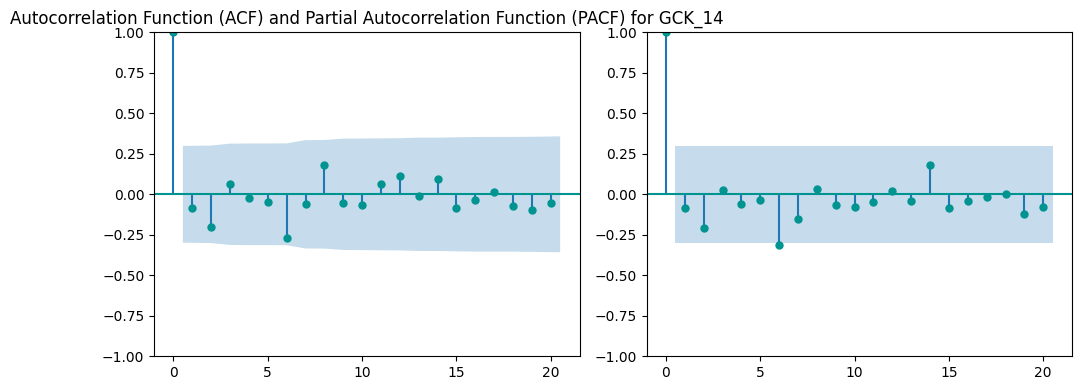

In [99]:
# This code will calculate and plot the ACF and PACF for the 'GCK_14' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_14')

# According to the graphs there is no total autocorrelation for product 14 as well as partial
#(except only one lag values (6))

**Product 16**

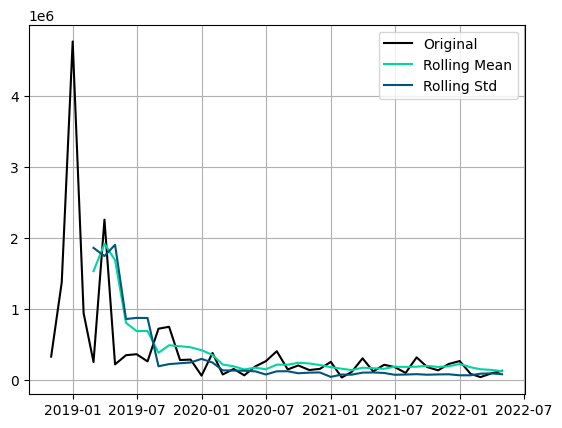

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -6.367204e+00
p-value                        2.393585e-08
#Lags Used                     9.000000e+00
Number of Observations Used    3.300000e+01
Critical Value (1%)           -3.646135e+00
Critical Value (5%)           -2.954127e+00
Critical Value (10%)          -2.615968e+00
dtype: float64


In [100]:
#Verifying stationarity for product 16

stationarity_verification (df,'GCK_16')

#Since p-value is less than a significance level of 5%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 16 does not have seasonality 

#Both rolling mean and rolling std are aproximadetely constant over time

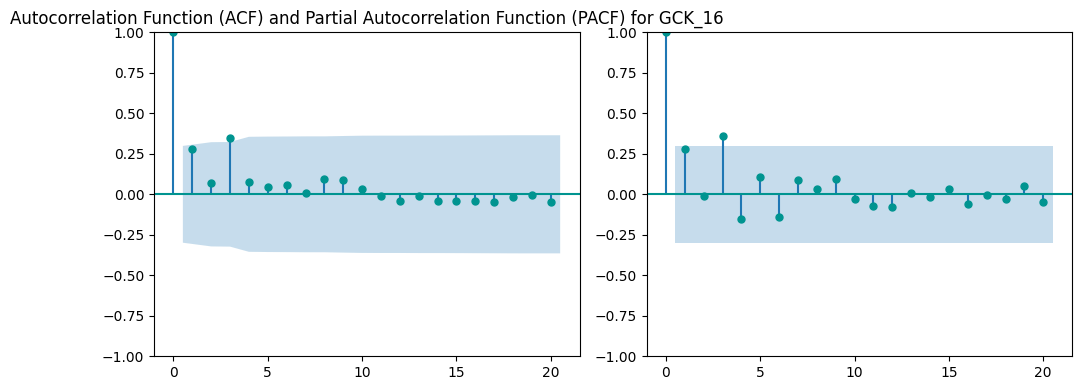

In [101]:
# This code will calculate and plot the ACF and PACF for the 'GCK_16' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_16')

# According to the graphs there is no total autocorrelation for product 16 as well as partial
#(except only 1 lag value for PACF and ACF (3))

**Product 20**

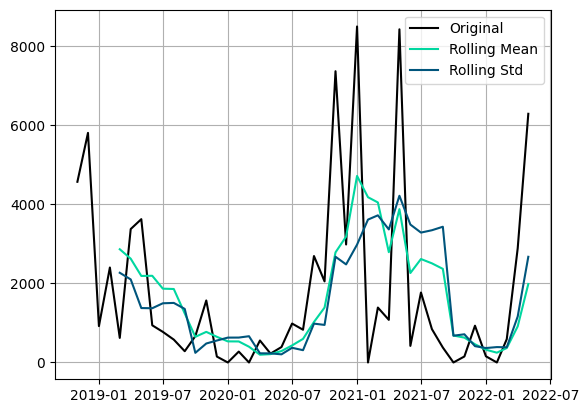

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -3.125179
p-value                         0.024745
#Lags Used                      1.000000
Number of Observations Used    41.000000
Critical Value (1%)            -3.600983
Critical Value (5%)            -2.935135
Critical Value (10%)           -2.605963
dtype: float64


In [102]:
#Verifying stationarity for product 20

stationarity_verification (df,'GCK_20')

#Since p-value is less than a significance level of 1%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 20 does not have seasonality 

#Both rolling mean and rolling std are not constant over time

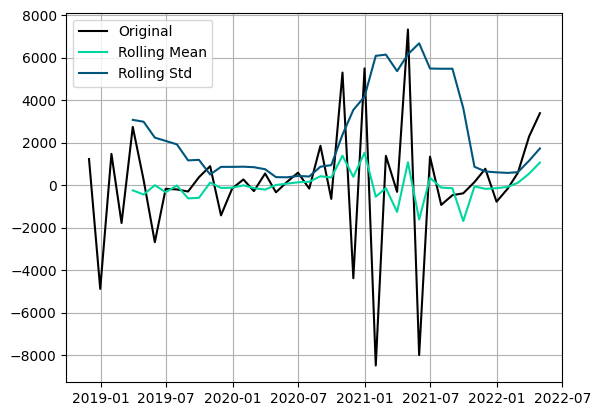

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                 -5.456595
p-value                         0.000003
#Lags Used                      2.000000
Number of Observations Used    39.000000
Critical Value (1%)            -3.610400
Critical Value (5%)            -2.939109
Critical Value (10%)           -2.608063
dtype: float64


In [103]:
# Before using SARIMA (or ARIMA/ARMA depending on the case), as the series is not stationary, we will try to take 
#first differences and check if the series becomes stationary. If it is we already know that degree of differencing
#is one. If not, we will have to check whether we should differentiate again or seasonally diferentiate.
df_temp=df.copy()
df_temp['GCK_20_DIFF_1'] = df_temp['GCK_20'].diff() 
df_temp['GCK_20_DIFF_1']=df_temp['GCK_20_DIFF_1'].dropna()
GCK_20_DIFF_1 = df_temp['GCK_20_DIFF_1'].dropna()
GCK_20_DIFF_1 = pd.DataFrame(GCK_20_DIFF_1)
stationarity_verification(GCK_20_DIFF_1,'GCK_20_DIFF_1') 
#Considering the p-value we obtained (<0.05), there is
#statistical evidence suggesting that the series is stationary

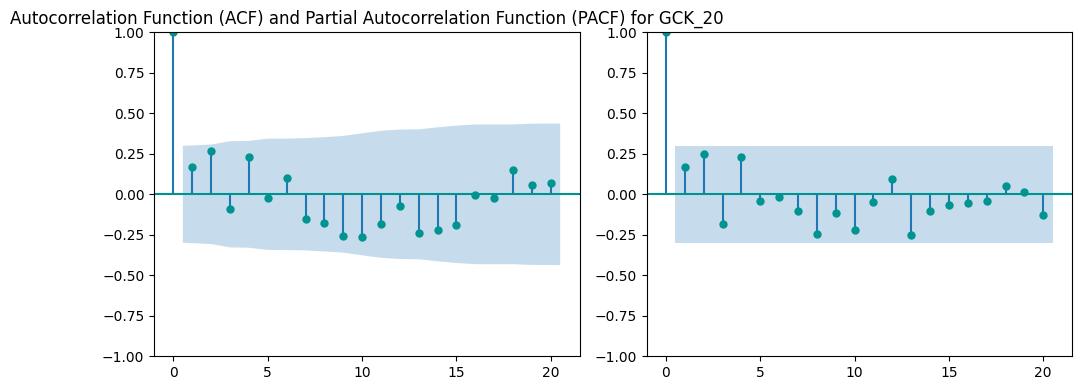

In [104]:
# This code will calculate and plot the ACF and PACF for the 'GCK_20' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df_temp, 'GCK_20')

# According to the graphs there is no total autocorrelation for product 20 as well as partial
#(except only 4 lag values for PACF (8,10,13,20))

**Product 36**

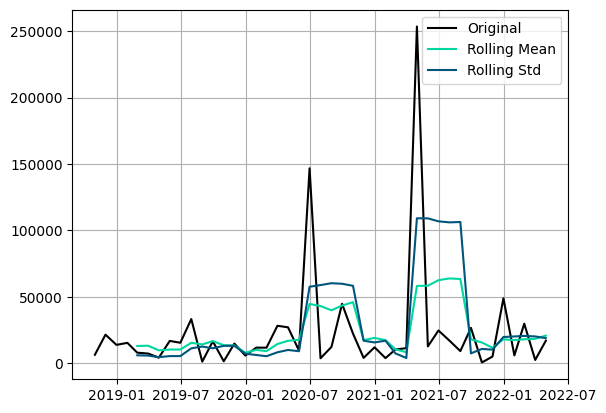

<Figure size 1000x1500 with 0 Axes>

Results of Dickey Fuller Test:
Test Statistic                -7.000027e+00
p-value                        7.362686e-10
#Lags Used                     0.000000e+00
Number of Observations Used    4.200000e+01
Critical Value (1%)           -3.596636e+00
Critical Value (5%)           -2.933297e+00
Critical Value (10%)          -2.604991e+00
dtype: float64


In [105]:
#Verifying stationarity for product 36

stationarity_verification (df,'GCK_36')

#Since p-value is less than a significance level of 5%, we reject the null hypotheses, therefore, the data is stationarity 
#Therefore, product 36 does not have seasonality 

#Both rolling mean and rolling std are not constant over time

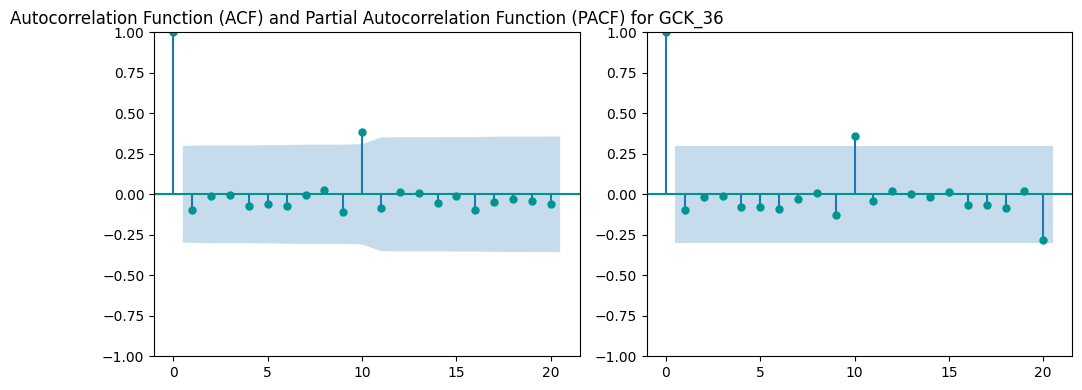

In [106]:
# This code will calculate and plot the ACF and PACF for the 'GCK_36' time series in the df DataFrame.
# Examining the ACF and PACF plots can help identify the temporal dependencies in the data and inform the choice of models, 
#such as autoregressive (AR) or moving average (MA) components.

acf_pacf(df, 'GCK_36')

# According to the graphs there is no total autocorrelation for product 20 as well as partial
#(except only 4 lag values for PACF (8,10,13,20))

<a class="anchor" id="subtitle6.2.7">
    
### 6.2.7. STL Decomposition
    
</a>

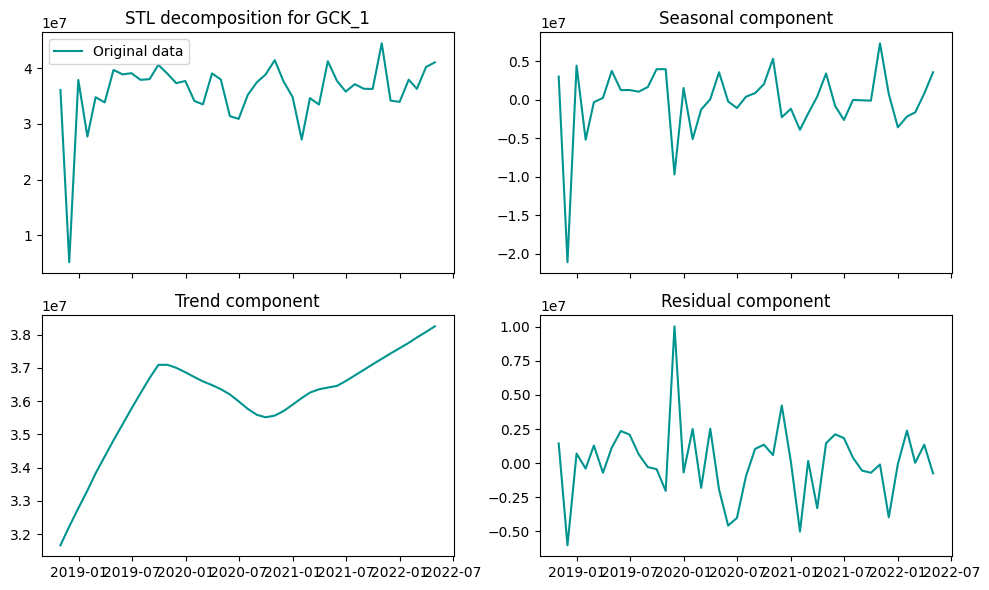

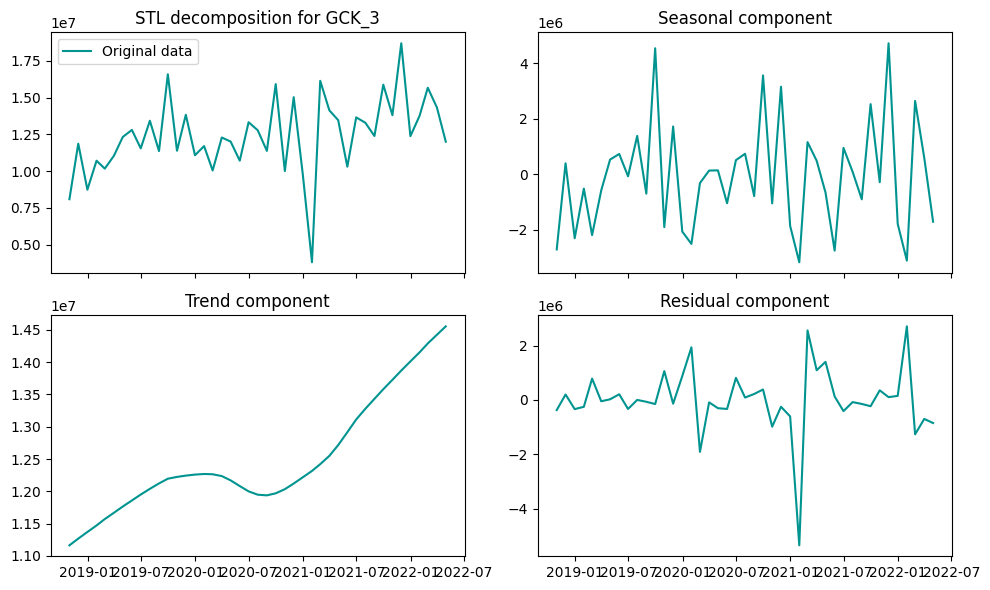

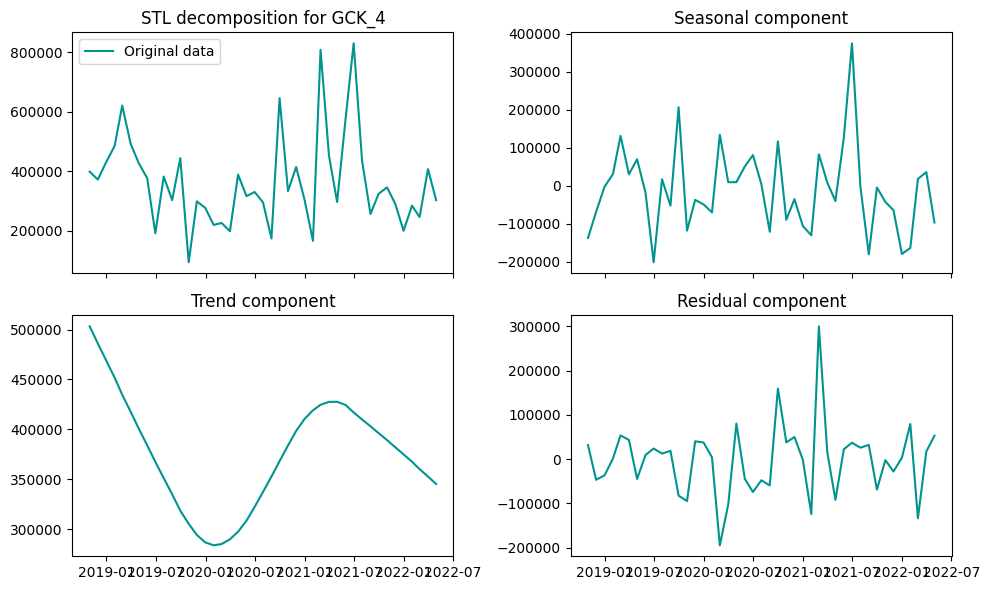

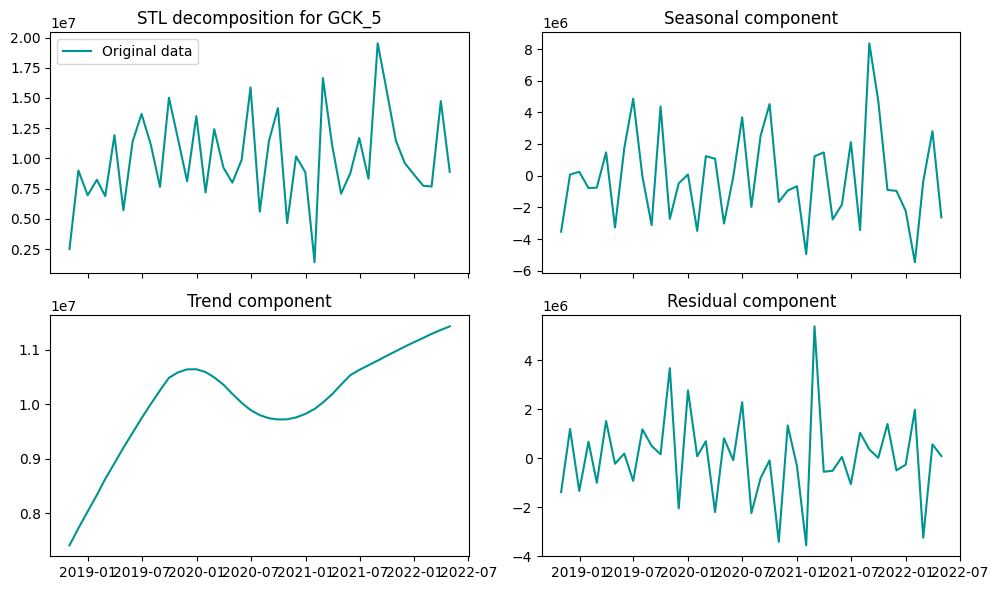

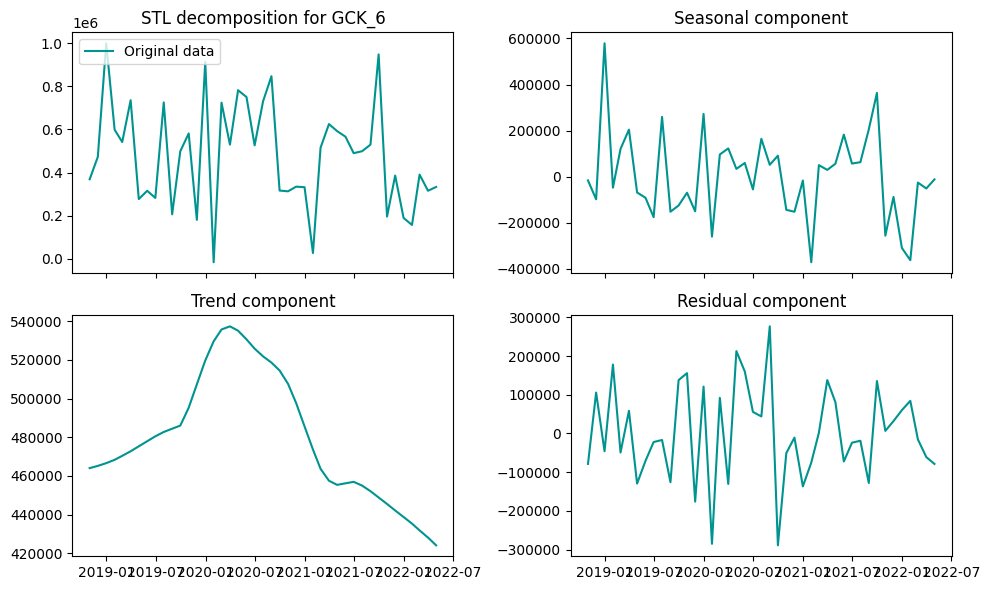

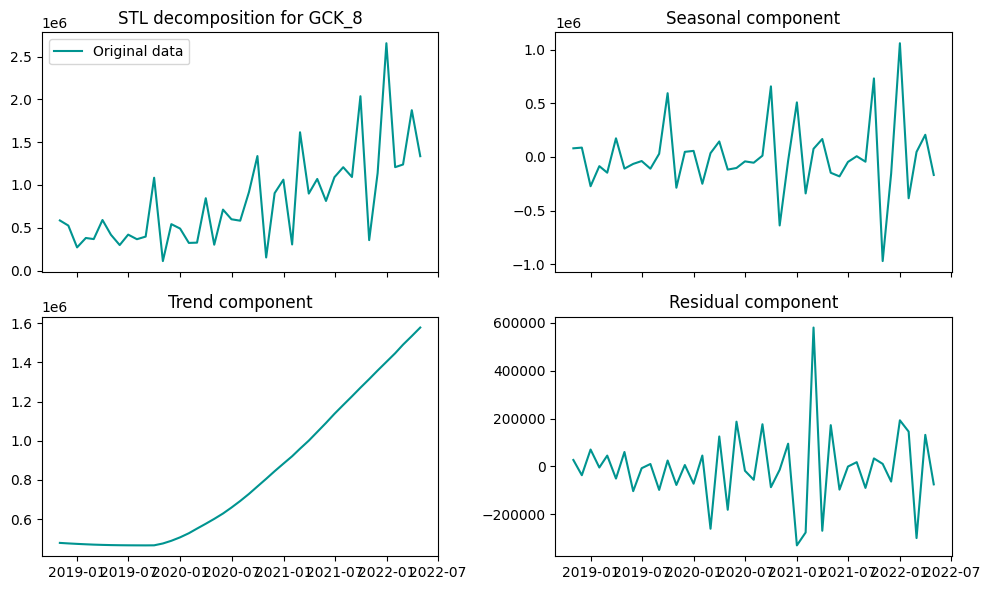

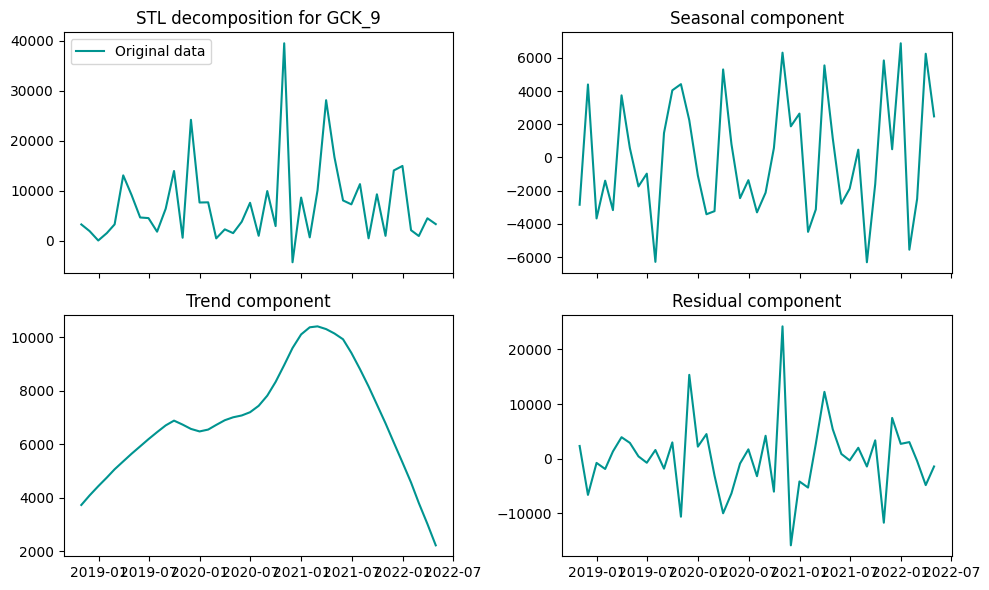

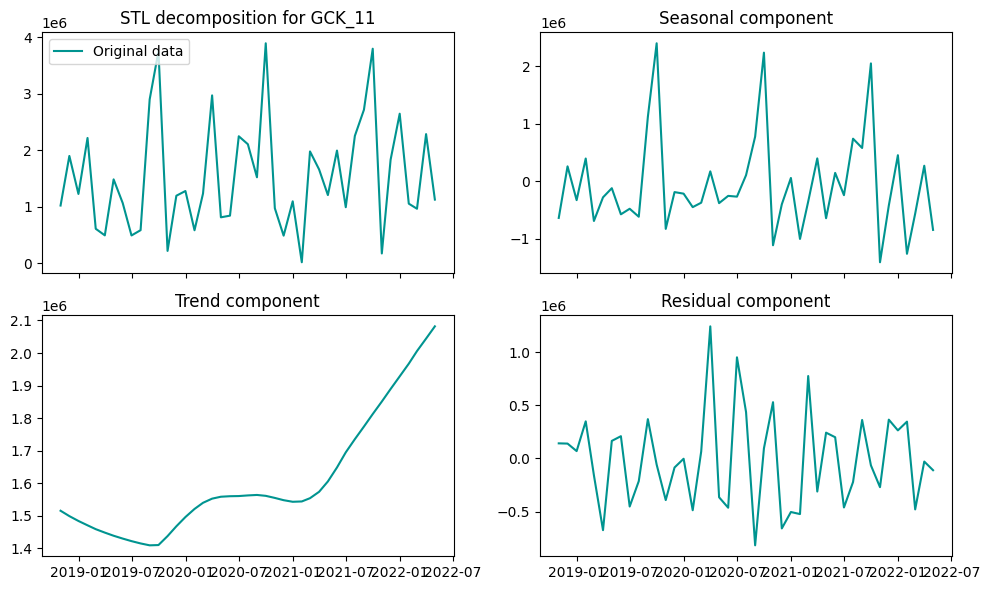

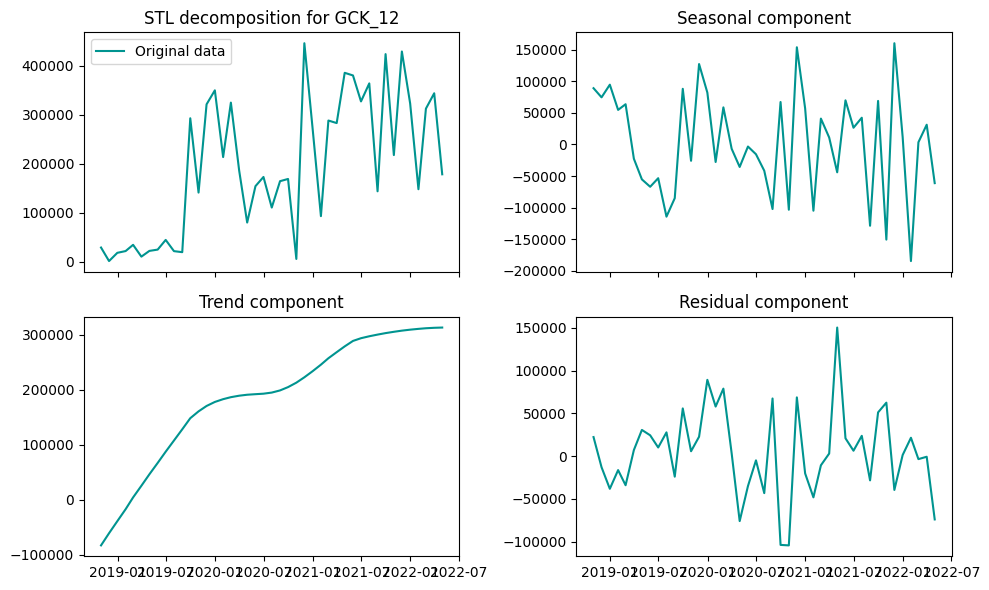

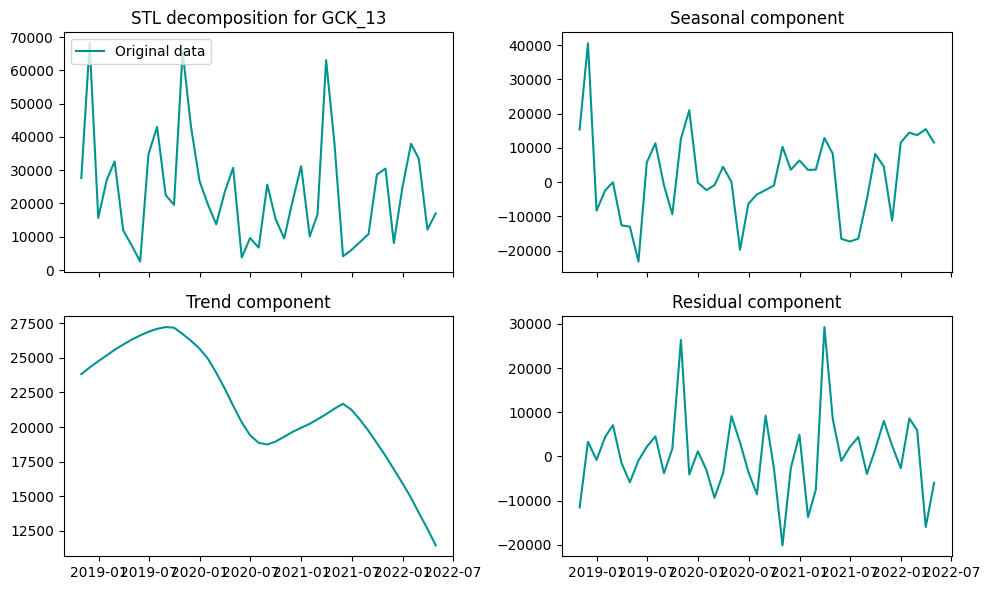

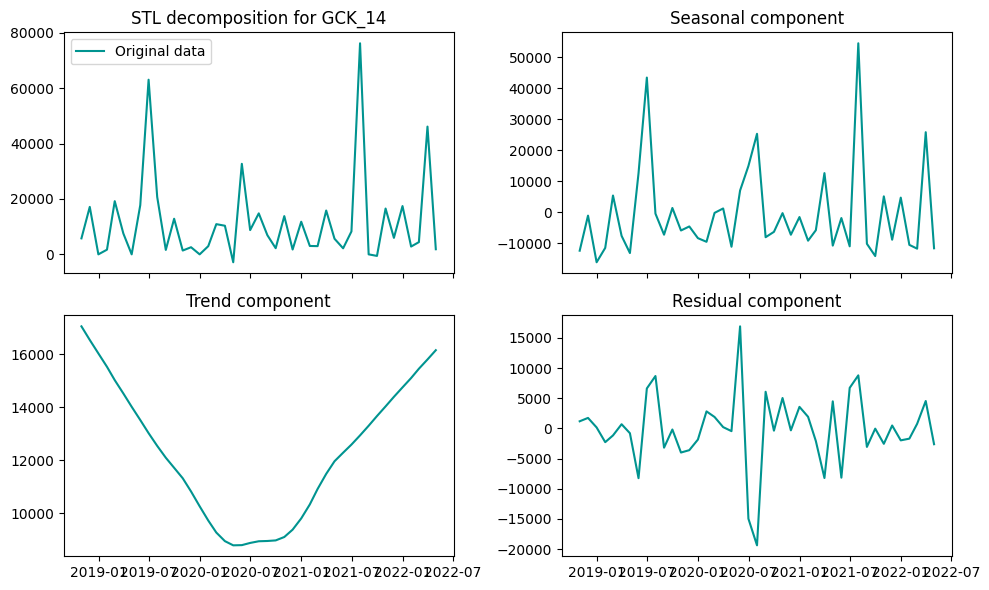

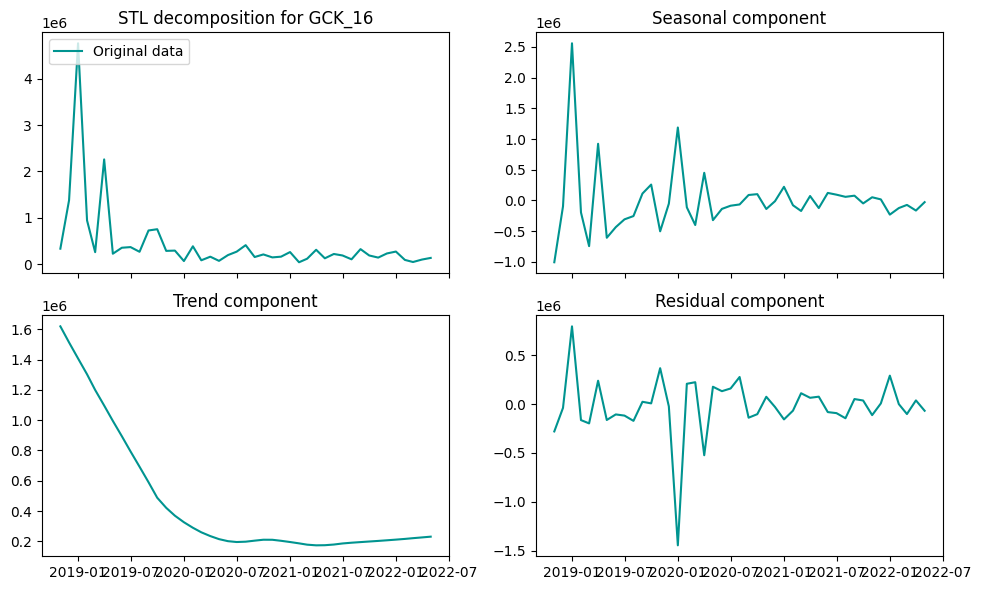

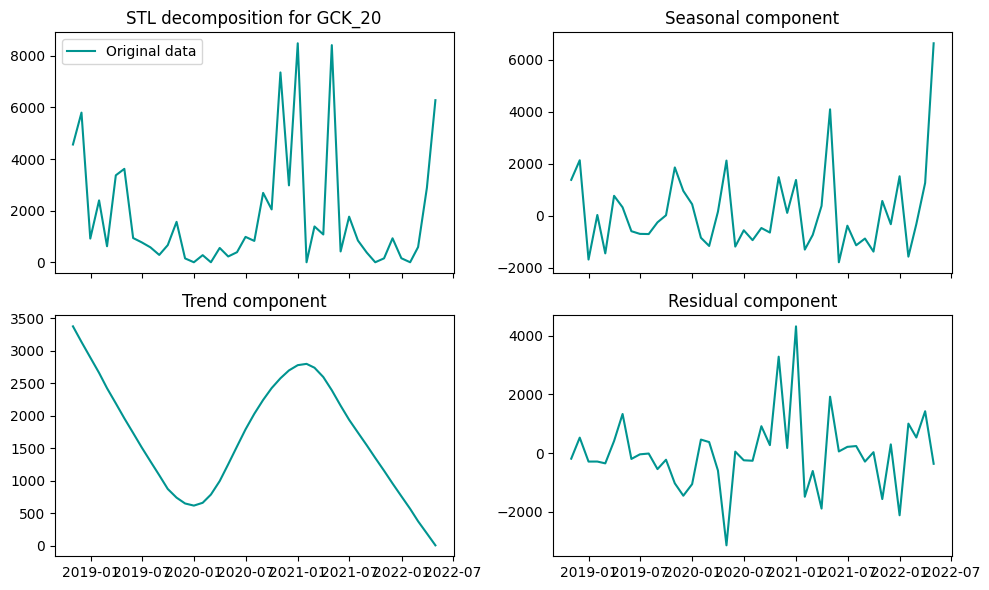

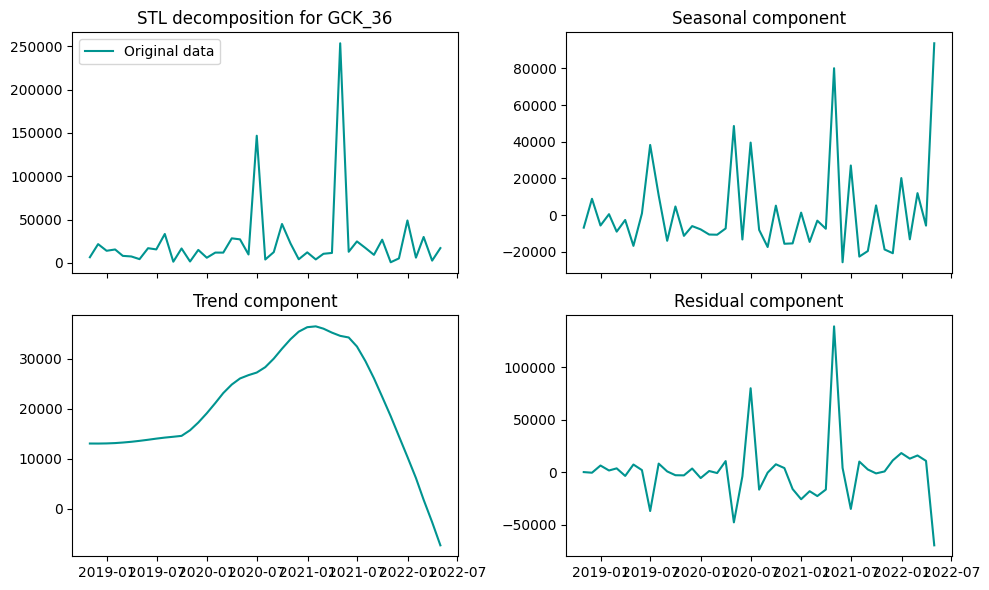

In [107]:
# Plot Trend and Seasonality Plots for each Product Category
for col in df.columns:
    stl_decomposition(df, col)

<a class="anchor" id="subtitle6.2.8">
    
### 6.2.8. Visual Exploration
    
</a>

**Total Sales by Month & Product**

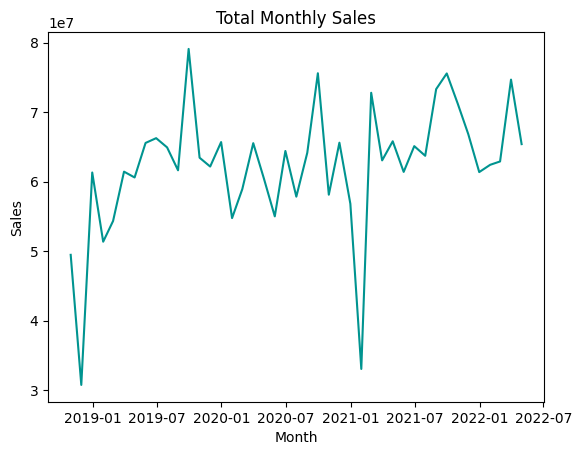

In [108]:
# Calculate total monthly sales
monthly_sales = df.sum(axis=1)

# Create a line chart
plt.plot(monthly_sales.index, monthly_sales,color=main_color)

# Set the plot title and axis labels
plt.title("Total Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

# Show the plot
plt.show()

In [109]:
# Some major sales decline, especially in January 2021.
# Some major sales rises, around September of each year.

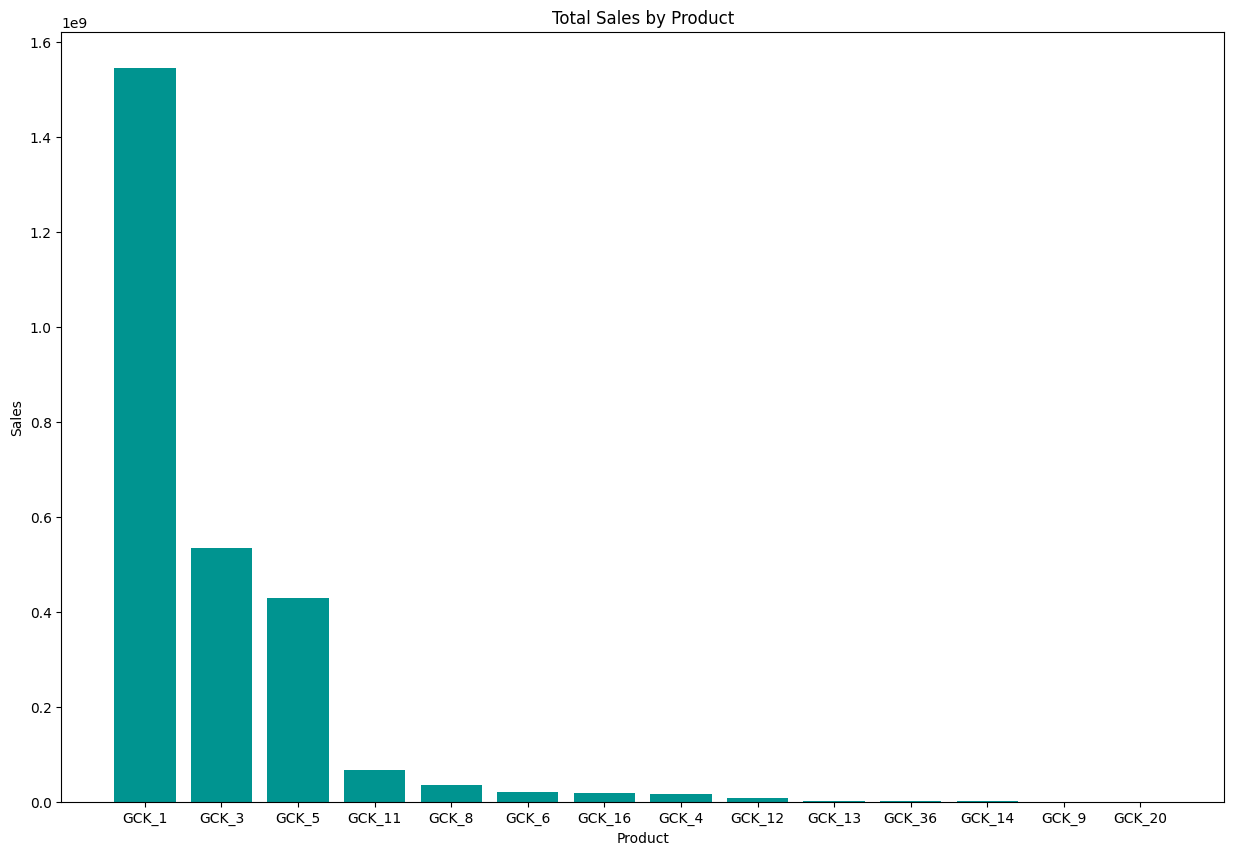

In [110]:
# Calculate total sales by product
total_sales_by_product = df.sum(axis=0).sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(total_sales_by_product.index, total_sales_by_product,color=main_color)

# Set the plot title and axis labels
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")

# Show the plot
plt.show()

In [111]:
# Product group 1, 3 and 5 are the top three products with the highest accumulated sales.

**Product Composition**

In [112]:
# Convert the index to a column of dates
df.reset_index(inplace=True)

# Melt the data to create a "long" format with separate rows for each product
df_melted = df.melt(id_vars='date', var_name='Product', value_name='Sales')

# Pivot the data to create a matrix of sales values by date and product
df_pivot = df_melted.pivot(index="date", columns="Product", values="Sales")

In [113]:
df.head()

Mapped_GCK,date,GCK_1,GCK_3,GCK_4,GCK_5,GCK_6,GCK_8,GCK_9,GCK_11,GCK_12,GCK_13,GCK_14,GCK_16,GCK_20,GCK_36
0,2018-10-31,36098918.79,8089465.96,397760.69,2499061.19,369231.60,586052.74,3219.32,1021303.50,28686.33,27666.10,5770.0,333196.87,4563.14,6474.60
1,2018-11-30,5140760.00,11863001.51,371322.42,8993944.04,473046.96,526292.77,1875.90,1898844.80,1070.00,68180.00,17130.0,1377694.32,5798.14,21617.61
2,2018-12-31,37889612.12,8736859.39,430100.96,6947507.31,999472.69,271490.71,0.00,1226122.00,17880.60,15655.18,0.0,4762524.66,918.65,13924.52
3,2019-01-31,27728148.35,10705300.63,484173.88,8233205.07,598874.10,381400.15,1487.00,2216391.74,21484.00,27198.29,1686.4,942957.19,2398.04,15444.39
4,2019-02-28,34793163.53,10167796.86,620031.80,6879250.99,542037.52,368475.57,3234.28,610456.60,34214.74,32638.63,19196.3,257765.04,620.66,8051.15


In [114]:
df.describe(include='all')

Mapped_GCK,date,GCK_1,GCK_3,GCK_4,GCK_5,GCK_6,GCK_8,GCK_9,GCK_11,GCK_12,GCK_13,GCK_14,GCK_16,GCK_20,GCK_36
count,43,4.300000e+01,4.300000e+01,43.000000,4.300000e+01,43.000000,4.300000e+01,43.000000,4.300000e+01,43.000000,43.000000,43.000000,4.300000e+01,43.000000,43.000000
mean,2020-07-30 18:25:06.976744192,3.591177e+07,1.240566e+07,363423.371163,9.990585e+06,480043.964884,8.109586e+05,7173.174651,1.532589e+06,192546.193488,23468.765349,11484.233953,4.277018e+05,1821.554884,23223.579302
min,2018-10-31 00:00:00,5.140760e+06,3.804320e+06,93226.320000,1.405295e+06,-15202.960000,1.117913e+05,-4358.100000,1.820000e+04,1070.000000,2550.310000,-2851.450000,4.036008e+04,0.000000,674.000000
25%,2019-09-15 00:00:00,3.440896e+07,1.105907e+07,279799.480000,7.703432e+06,316055.490000,3.749379e+05,1626.700000,9.035992e+05,39235.210000,10466.465000,2015.025000,1.375541e+05,330.810000,6244.495000
50%,2020-07-31 00:00:00,3.732390e+07,1.231748e+07,329430.960000,9.232238e+06,499147.730000,5.998319e+05,4488.090000,1.226122e+06,172712.880000,20663.640000,5951.850000,2.245019e+05,842.930000,12377.770000
75%,2021-06-15 00:00:00,3.888867e+07,1.377567e+07,428161.150000,1.180077e+07,611987.120000,1.092310e+06,9583.200000,2.161184e+06,321795.050000,30966.410000,15305.890000,3.283725e+05,2543.020000,21995.050000
max,2022-04-30 00:00:00,4.448301e+07,1.868682e+07,829442.330000,1.952464e+07,999472.690000,2.655037e+06,39510.750000,3.891448e+06,445648.060000,68180.000000,76161.440000,4.762525e+06,8485.600000,253519.040000
std,NaN,5.905117e+06,2.577332e+06,155710.914233,3.731564e+06,242286.217600,5.436111e+05,8231.269282,9.811598e+05,141016.785899,16140.161949,16116.168947,7.824899e+05,2307.900214,42651.283687


In [115]:
df

Mapped_GCK,date,GCK_1,GCK_3,GCK_4,GCK_5,GCK_6,GCK_8,GCK_9,GCK_11,GCK_12,GCK_13,GCK_14,GCK_16,GCK_20,GCK_36
0,2018-10-31,36098918.79,8089465.96,397760.69,2499061.19,369231.60,586052.74,3219.32,1021303.50,28686.33,27666.10,5770.00,333196.87,4563.14,6474.60
1,2018-11-30,5140760.00,11863001.51,371322.42,8993944.04,473046.96,526292.77,1875.90,1898844.80,1070.00,68180.00,17130.00,1377694.32,5798.14,21617.61
2,2018-12-31,37889612.12,8736859.39,430100.96,6947507.31,999472.69,271490.71,0.00,1226122.00,17880.60,15655.18,0.00,4762524.66,918.65,13924.52
3,2019-01-31,27728148.35,10705300.63,484173.88,8233205.07,598874.10,381400.15,1487.00,2216391.74,21484.00,27198.29,1686.40,942957.19,2398.04,15444.39
4,2019-02-28,34793163.53,10167796.86,620031.80,6879250.99,542037.52,368475.57,3234.28,610456.60,34214.74,32638.63,19196.30,257765.04,620.66,8051.15
5,2019-03-31,33856803.04,11040544.57,491643.59,11914313.63,735604.23,591288.36,13050.61,493999.81,10118.00,11890.00,7535.25,2258352.22,3369.55,7373.42
6,2019-04-30,39688292.01,12317479.75,426221.34,5714462.48,277575.12,418899.90,9119.65,1484281.60,21813.27,7488.54,0.00,224501.90,3619.63,4280.25
7,2019-05-31,38897974.29,12798945.18,375671.57,11389673.26,315978.77,298806.84,4614.08,1066063.90,24468.00,2550.31,17771.40,353451.54,938.90,16905.32
8,2019-06-30,39106750.23,11546452.19,190721.15,13681879.16,282963.19,420707.73,4488.09,492133.20,44255.68,34849.21,63017.71,367425.38,772.94,15516.22
9,2019-07-31,37912572.30,13421550.83,381274.96,11145039.03,725411.99,366980.26,1766.40,585648.14,21318.48,43008.35,20719.30,266225.86,577.60,33334.41


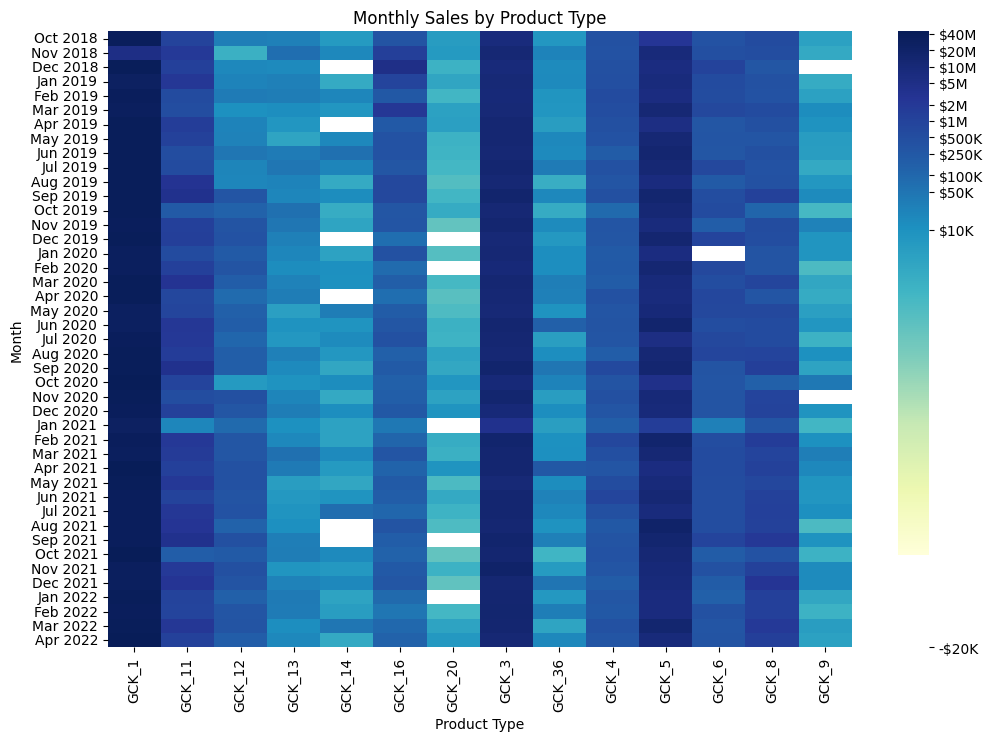

In [116]:
fig, ax = plt.subplots(figsize=(12, 8))
if df_pivot.values.min() < 0:
    vmin = 0.01
else:
    vmin = None

heatmap = sns.heatmap(df_pivot, cmap="YlGnBu", ax=ax, norm=matplotlib.colors.LogNorm(vmin=vmin, vmax=df_pivot.max().max()), fmt=".1f")

# Format the date labels
date_labels = [d.strftime('%b %Y') for d in df_pivot.index]
ax.set_yticklabels(date_labels)

# Set the colorbar ticks
cbar = heatmap.collections[0].colorbar
cbar.set_ticks([2e-4, 10000, 50000, 100000, 250000, 500000, 1000000, 2000000, 5000000, 10000000, 20000000, 40000000])
cbar.set_ticklabels(['-$20K', '$10K', '$50K', '$100K', '$250K', '$500K', '$1M', '$2M', '$5M', '$10M', '$20M', '$40M'])

plt.title("Monthly Sales by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Month")
plt.show()

In [117]:
# Here we can have a quick look at our sales data.
# There are four Products (14, 20, 6, 9) with null or negative sales months.
# Products 9, 13, 14 and 20 being the company’s smallest products, sales-wise.

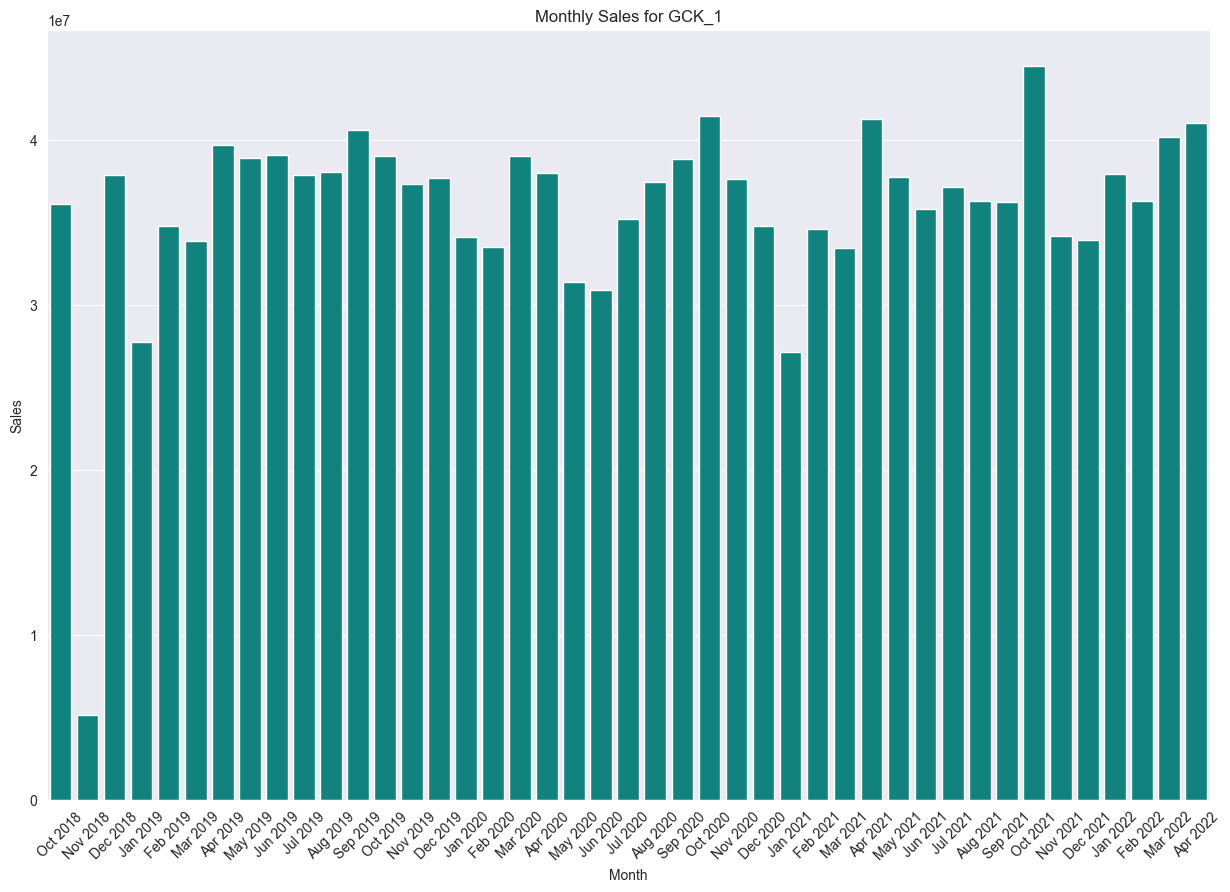

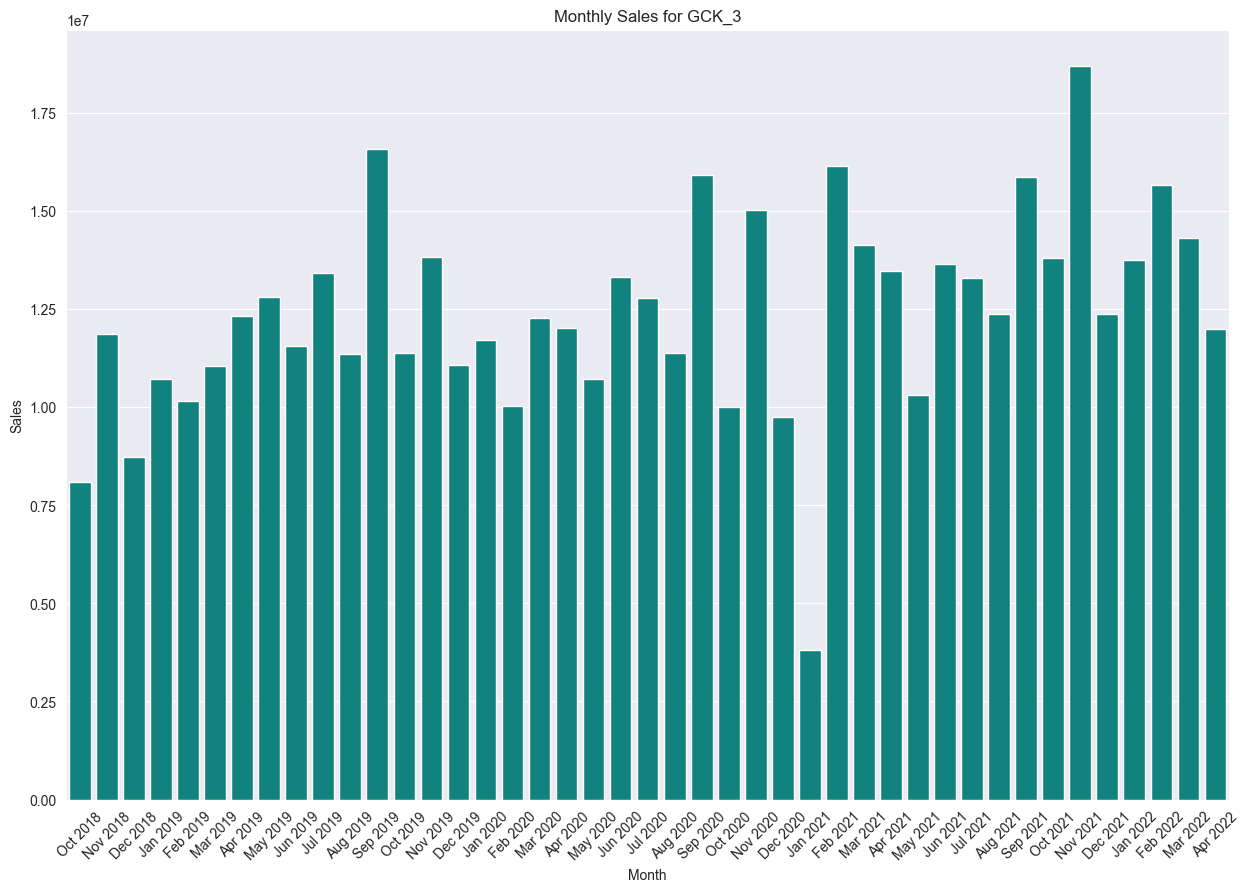

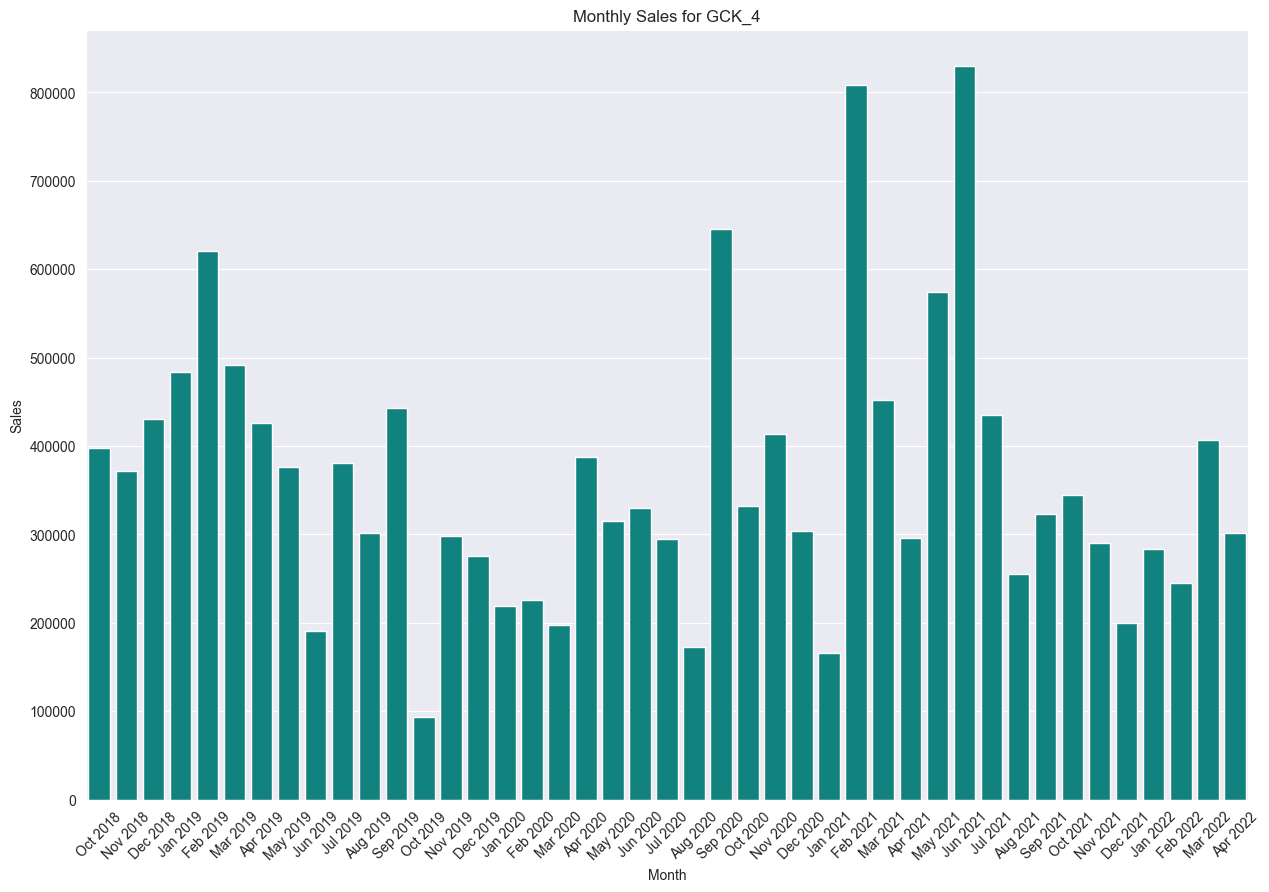

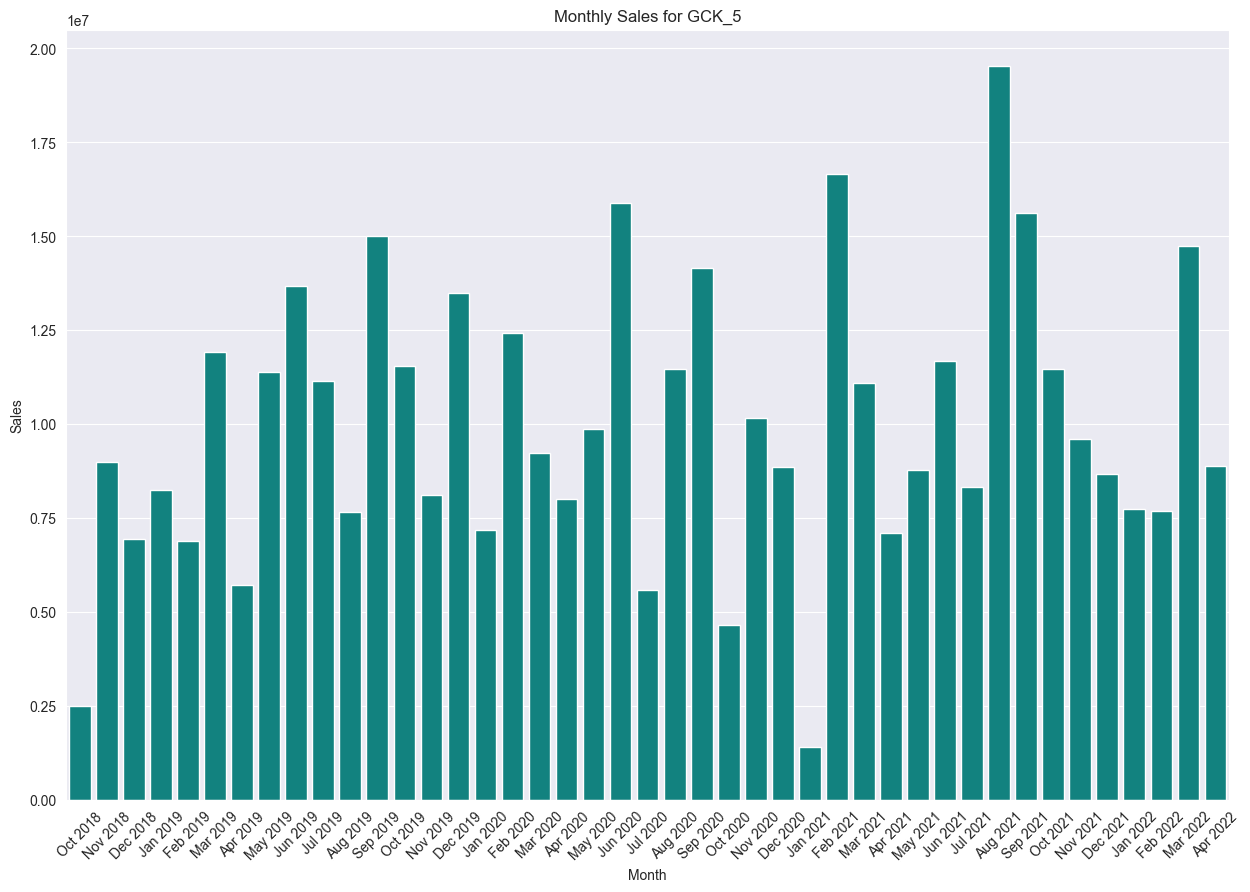

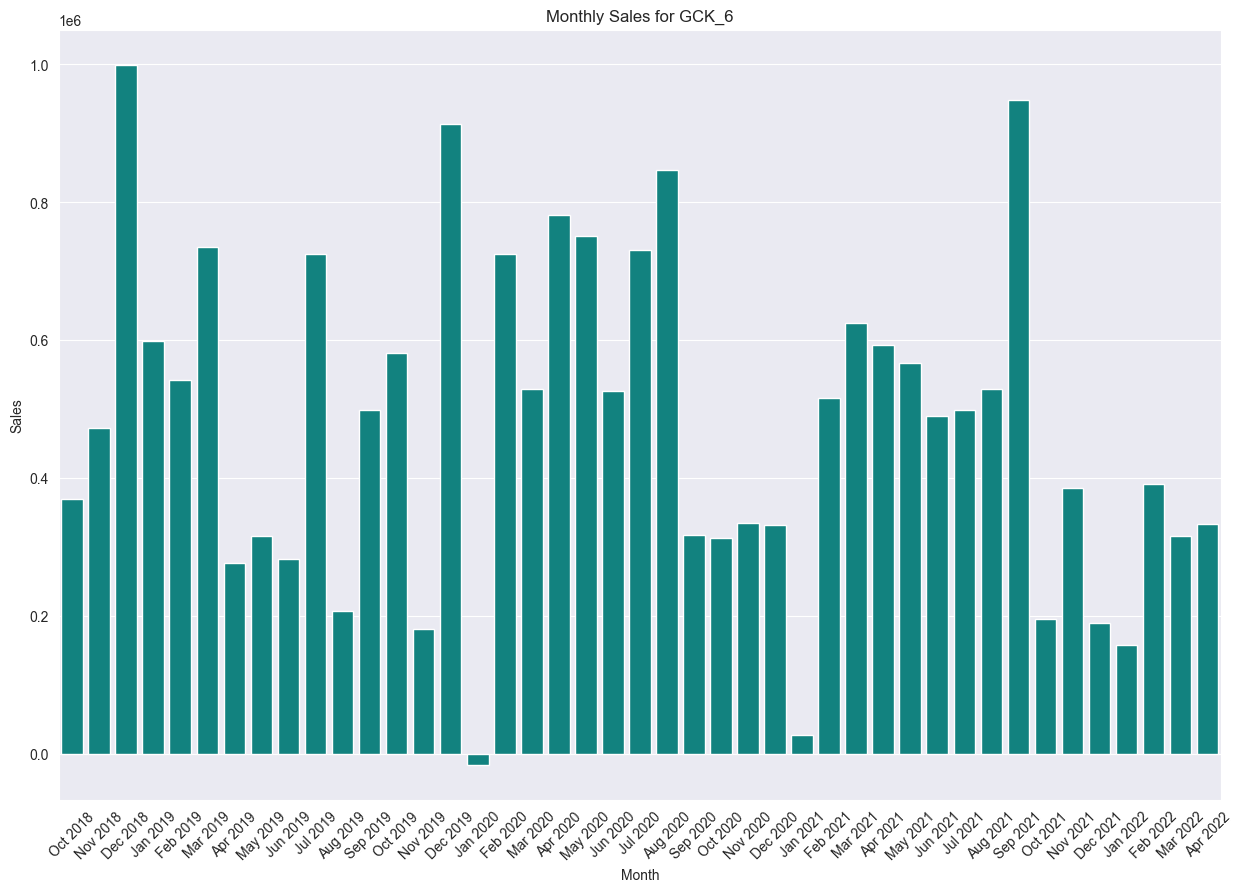

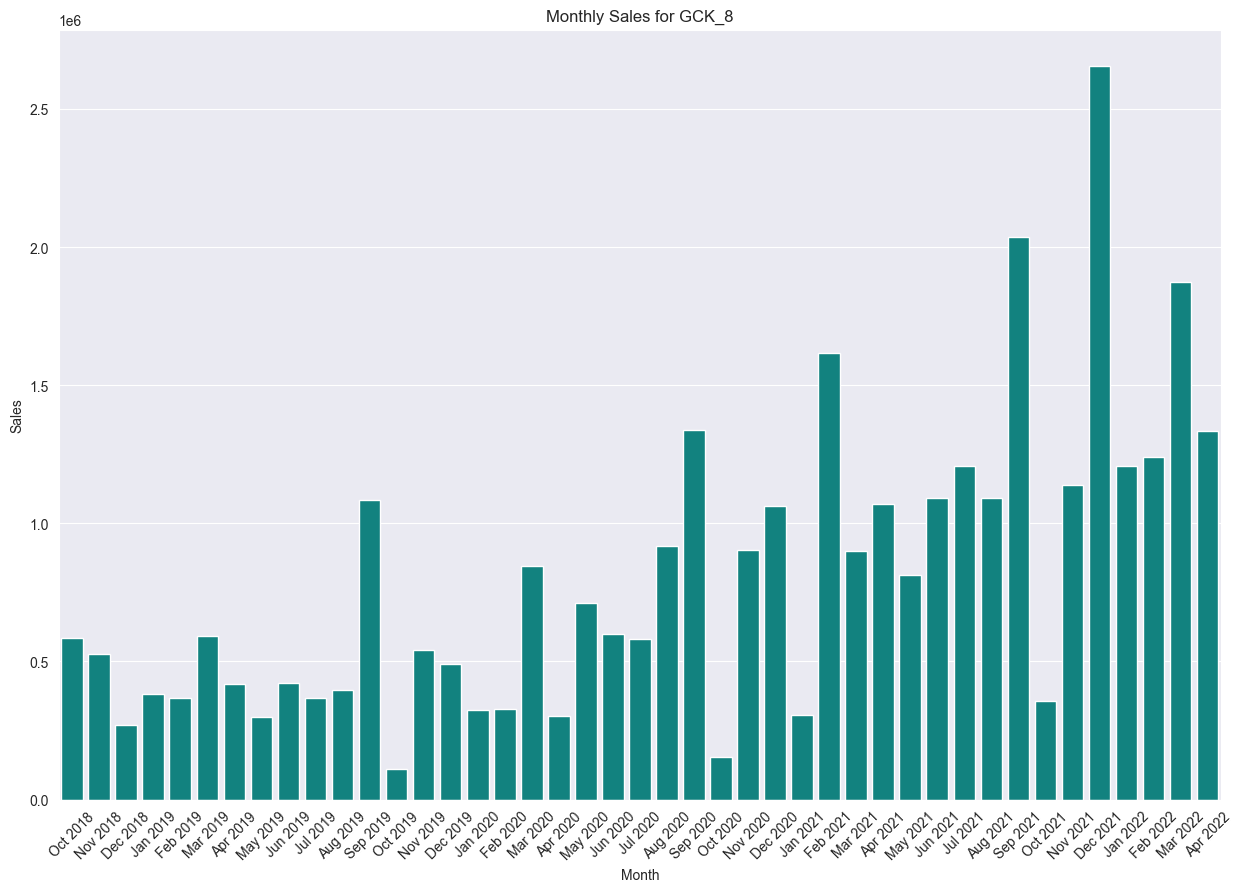

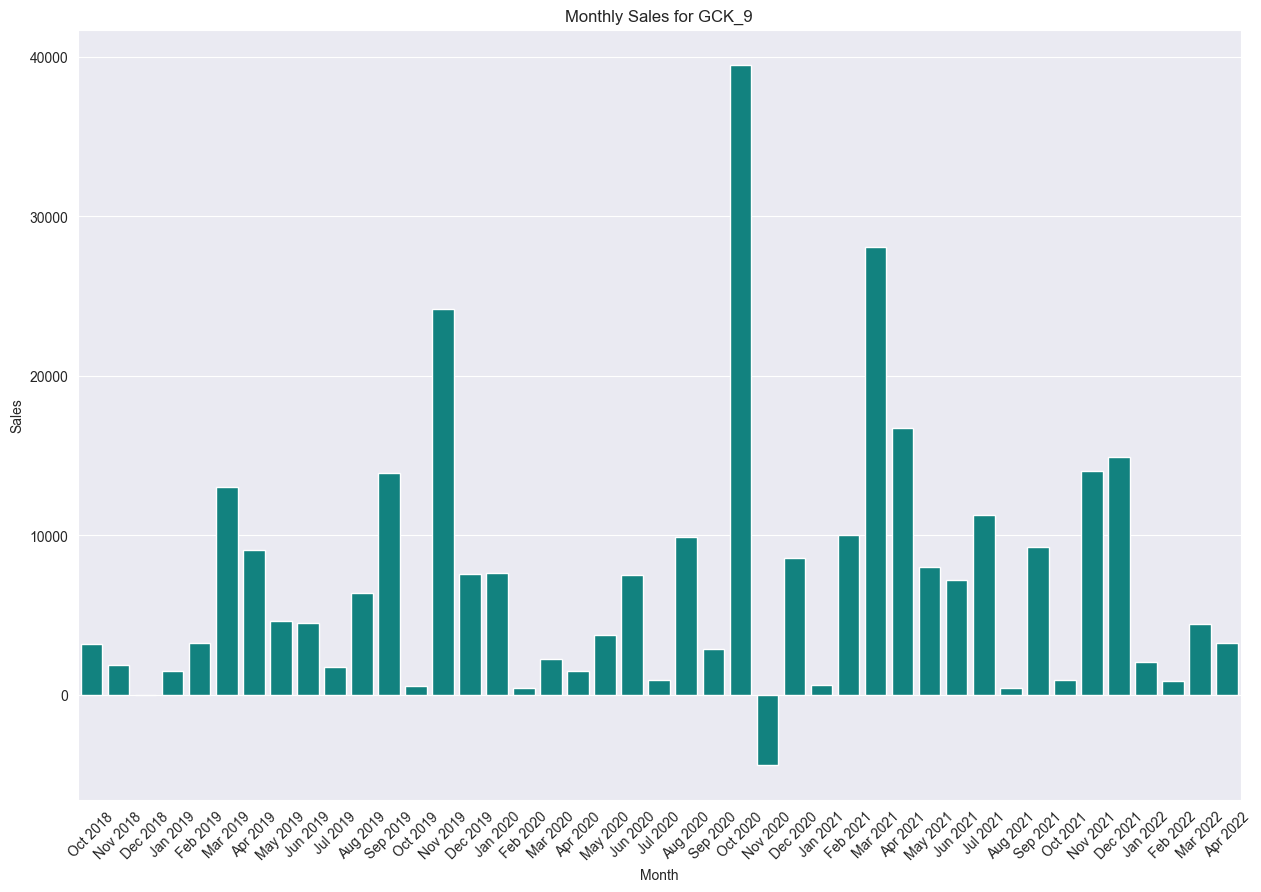

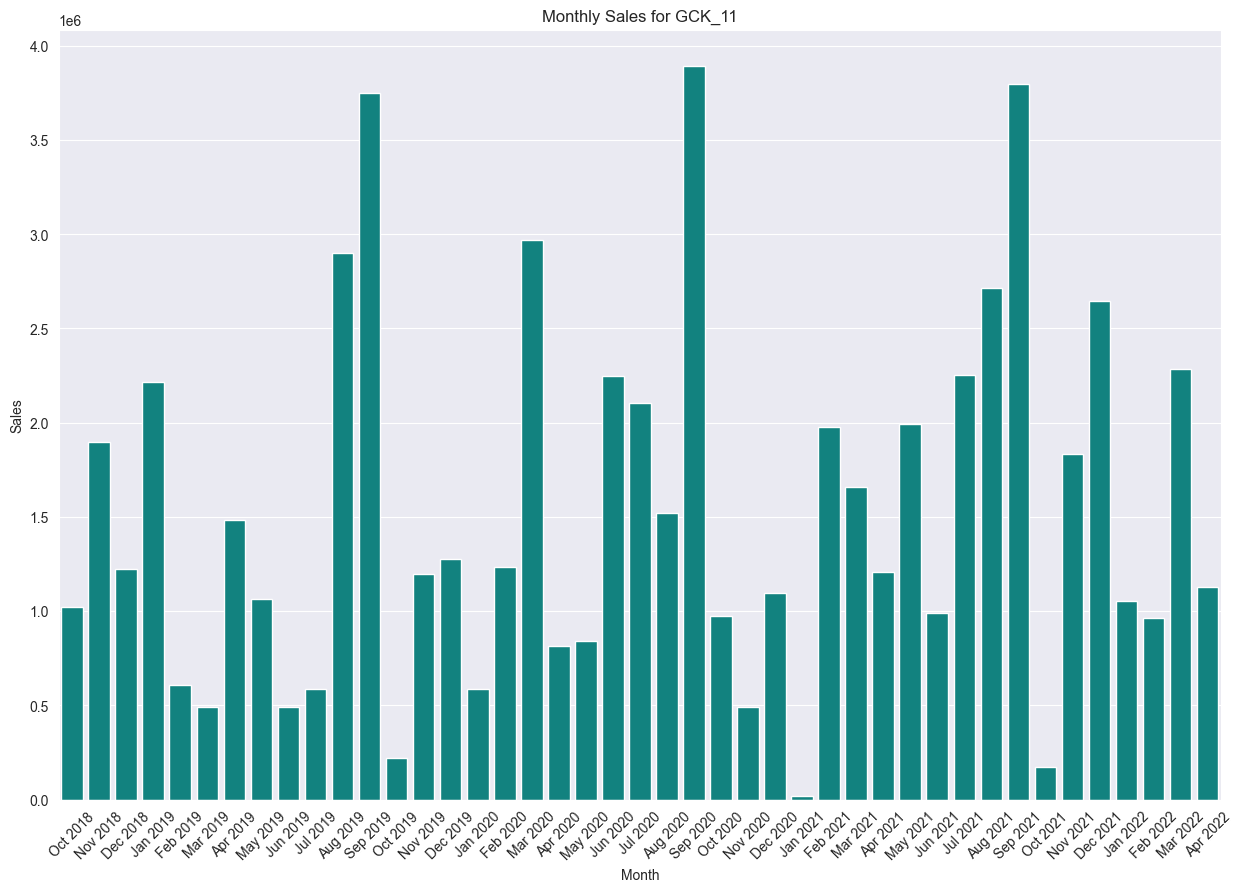

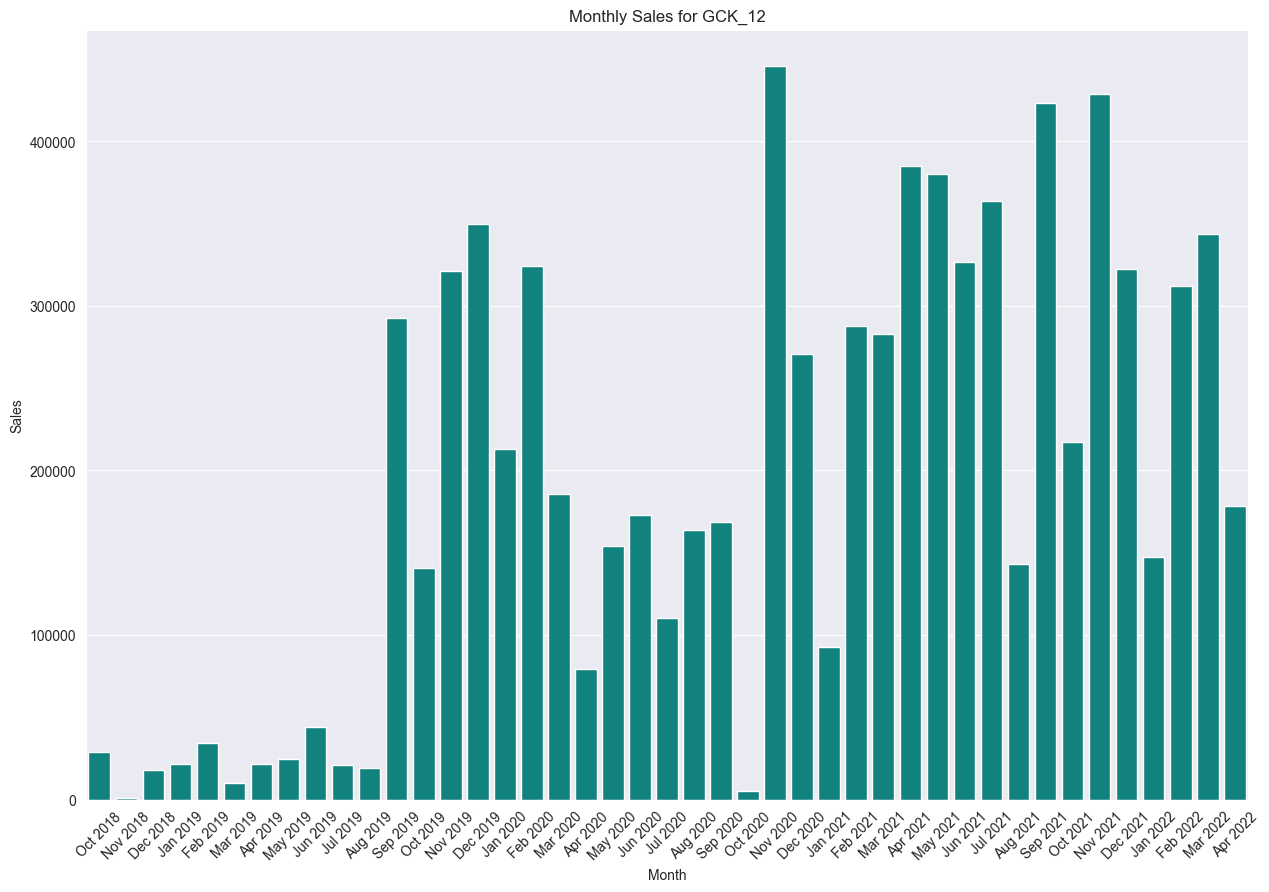

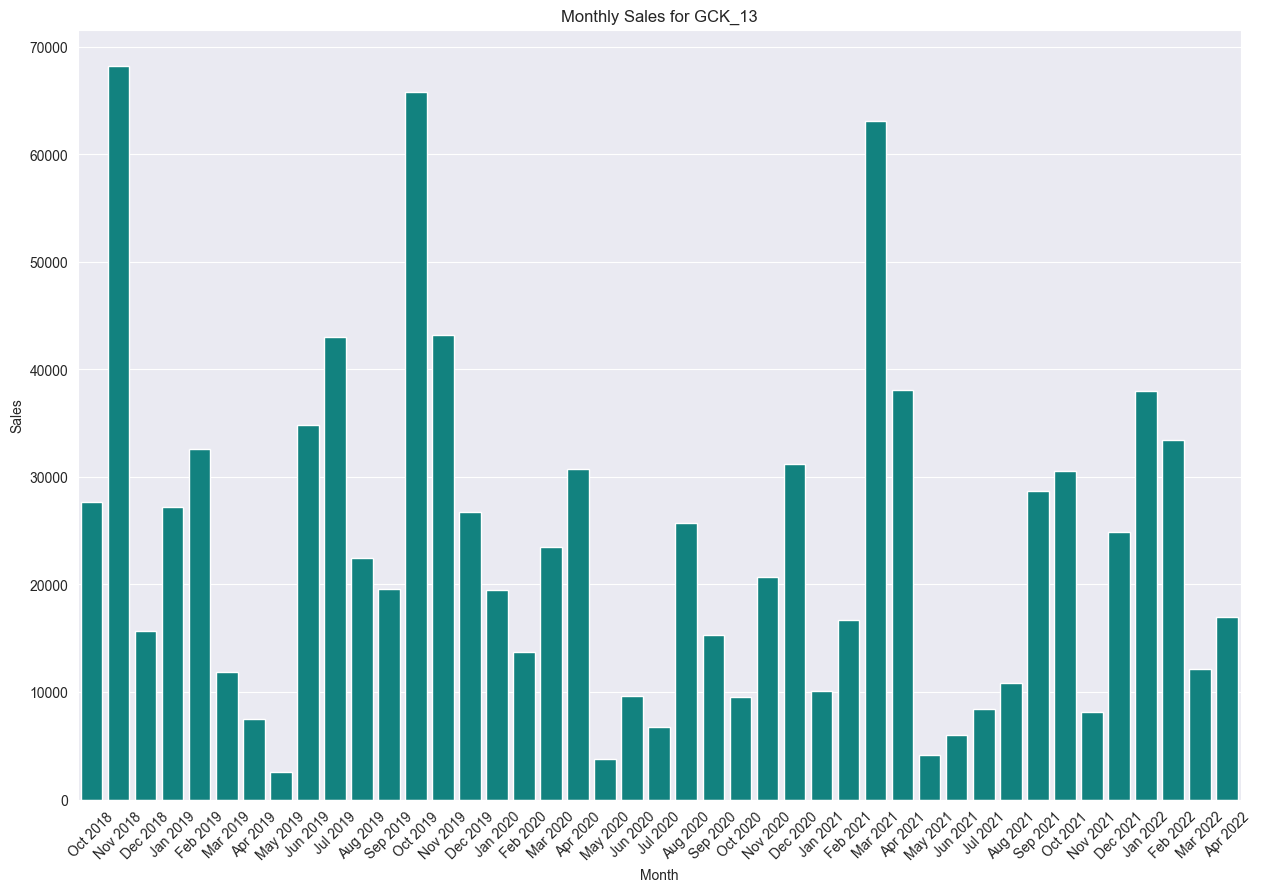

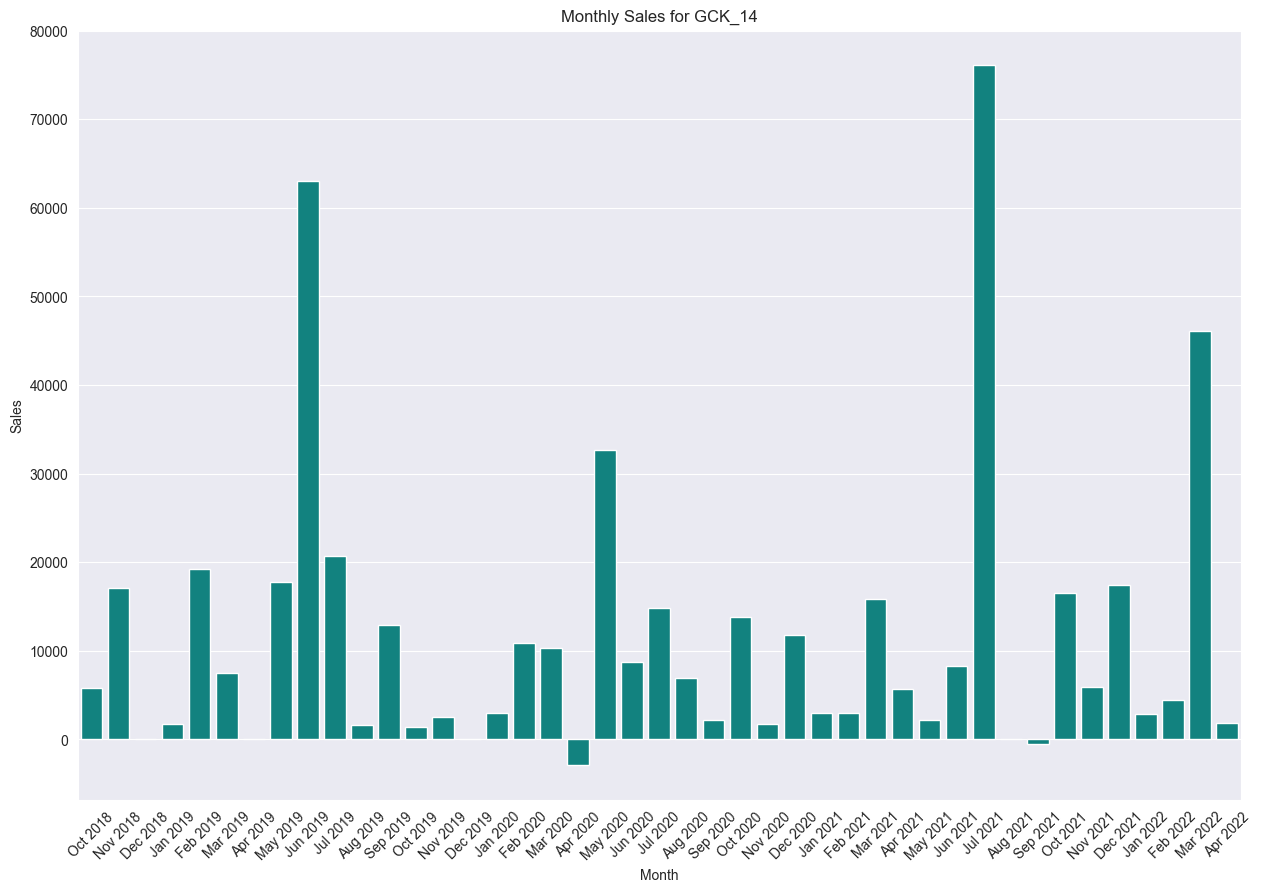

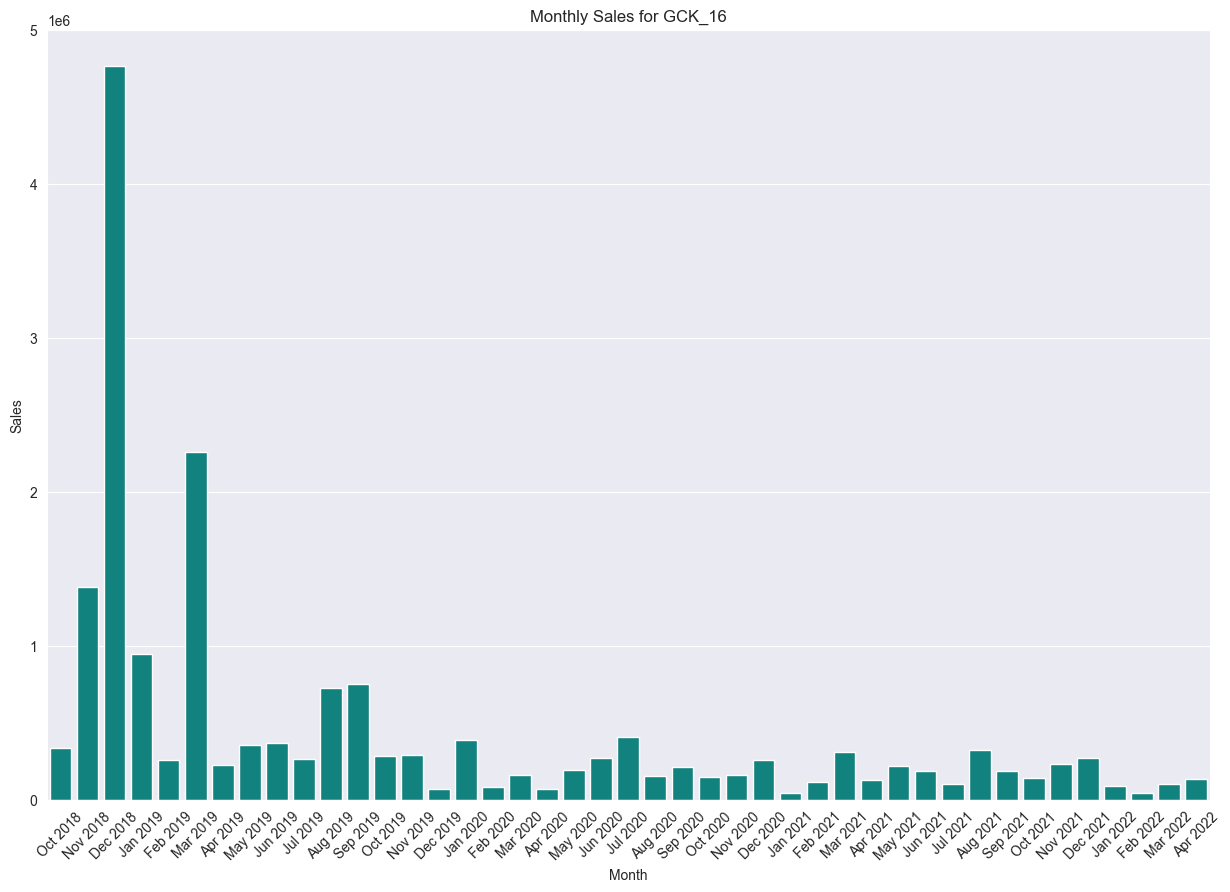

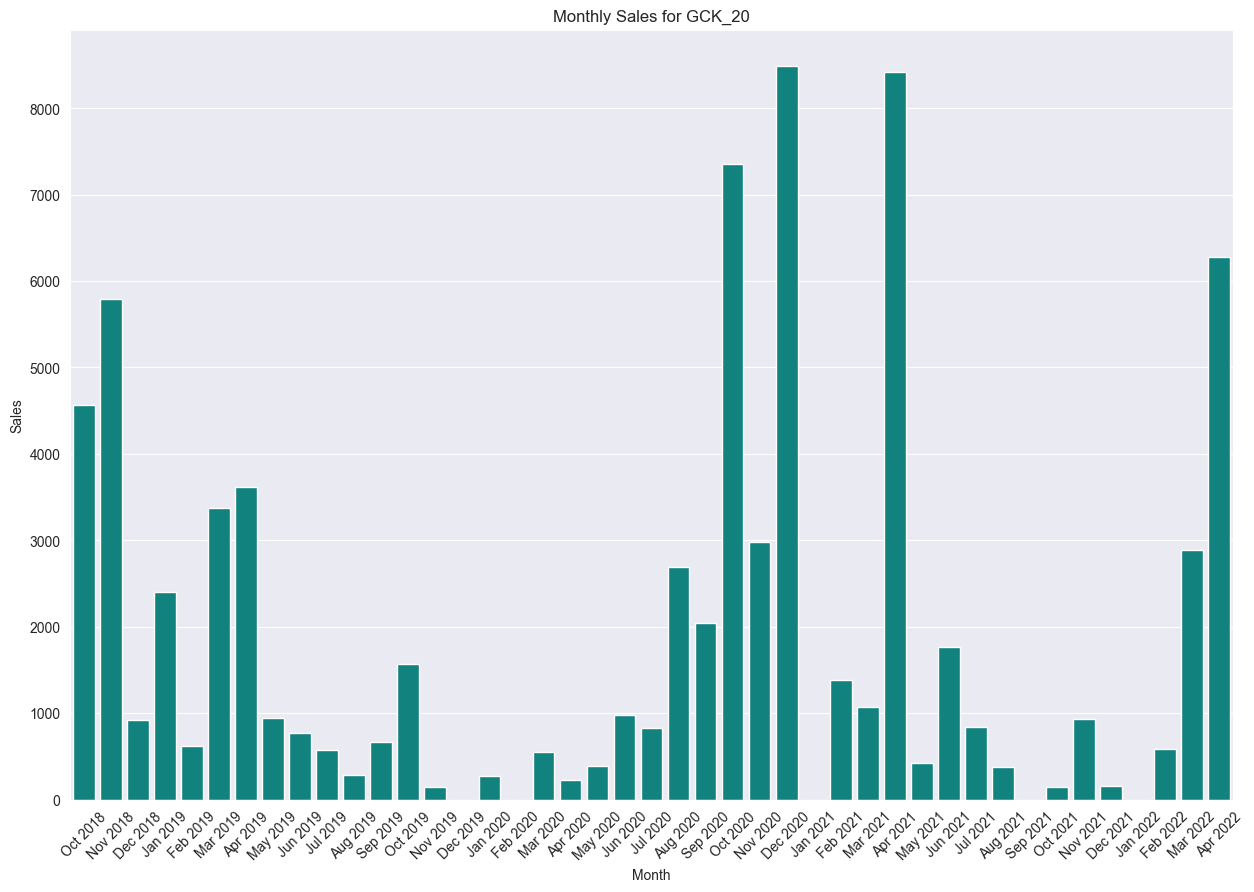

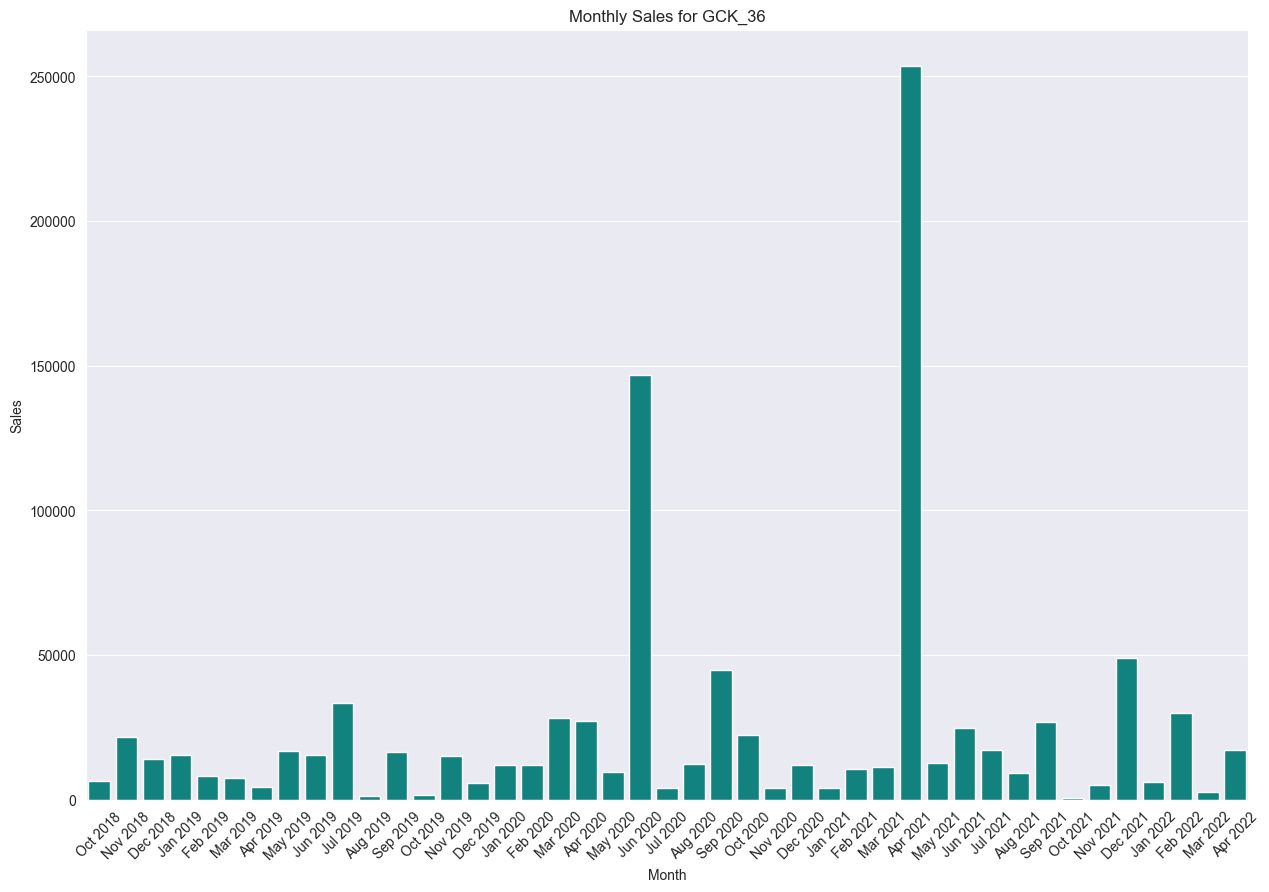

In [118]:
# Get a list of all unique product types
product_types = df.columns.tolist()[1:]

# Plot each product type once
for product_type in product_types:
    plot_monthly_sales_by_product_type(df, product_type)

In [119]:
# Product 1 and 3 showed overall constant sales values with a strong breakdown in one of the months. 
# Product 8 sales increased over time while Product 16 having an unusual sales month and from there slowly decreasing its sales.
# Product 11 seems to have a cyclic behavior having exceptionally great sales every September and dropping sales values 
#by at least more than two thirds right on the next month.

In [120]:
# Set the 'date' column as the index
df.set_index('date', inplace=True)

<hr>
<a class="anchor" id="preprocessing">
    
# 7. Data Preprocessing
    
</a>

<a class="anchor" id="subtitle7.1">
    
## 7.1. Fixing Inconsistencies
    
</a>

**Different date ranges**

In [121]:
# Filter the information according to dataset timeline October 2018 - February 2023
# If useful for analysis separete timelines accordingly (Train & Test)
new_index = pd.date_range(start=df.index.min(), end='2023-03-01', freq='M')

**Removing duplicated index**

In [122]:
columns_to_drop=['Shipments Index Machinery & Electricals_China']
market_data.drop(columns_to_drop,axis=1,inplace=True)

<a class="anchor" id="subtitle7.2">
    
## 7.2. Missing Values Treatment
    
</a>

In [123]:
#Verifying only after 2016-12-31 because it is the minimum date used to get lag variables.
market_data[market_data.index>=pd.to_datetime('2016-12-31')].isna().\
sum()[market_data[market_data.index>=pd.to_datetime('2016-12-31')].isna().sum()>0]

# Columns with more than 1 missing value will be eliminated being that 
# using a predicted value to predict another will result in a higher bias.

# Regarding the ones with only one missing value, it will be filled with the previous one,
# as it should be a reasonable approximation, because these indexes do not vary 
# considerably from month to month


Producer Prices Electrical Equipment_United Kingdom            18
Production Index Electrical Equipment_Switzerland               1
Production Index Machinery & Electricals_Switzerland            1
Production Index Machinery And Equipment N.E.C._Switzerland     1
Shipments Index Machinery & Electricals_Switzerland             1
Shipments Index Machinery & Electricals_United Kingdom         18
Shipments Index Machinery & Electricals_United States           1
dtype: int64

In [124]:
columns_to_drop=['Producer Prices Electrical Equipment_United Kingdom',
                 'Shipments Index Machinery & Electricals_United Kingdom']
market_data.drop(columns_to_drop,axis=1,inplace=True)

In [125]:
columns_to_fill = market_data.isna().sum()[market_data.isna().sum()==1].index

In [126]:
#Replace each NaN with the last existing value.
for column in columns_to_fill:
    index_to_fill=market_data[market_data[column].isna()].index.values[0]
    index_before = market_data[market_data.index < index_to_fill].index[-1]
    market_data.loc[market_data.index==index_to_fill,column]= market_data.loc[index_before,column]

<a class="anchor" id="subtitle7.3">
    
## 7.3. Outliers Removal
    
</a>

In [127]:
# Due to lack of time, outliers removal will be integrated in a future version.
# To deploy this step, the data points detected as outliers in Outlier Detection subchapter must be removed.
# Then, a new analysis on the Stationarity and ACF/PACF may be done, to detect new possible model choices.

#The outliers detected are as following:
### For GCK1, remove any data points that are less than 2.5.
### For GCK13, remove any data points that are greater than 50000.
### For GCK14, remove any data points that are greater than 30000.
### For GCK16, remove any data points that are greater than 1.
### For GCK20, remove any data points that are greater than 60000.
### For GCK3, remove any data points that are less than 0.8 or greater than 1.8.
### For GCK_36, remove any data points that are greater than 100000.
### For GCK4, remove any data points that are greater than 700000.
### For GCK8, remove any data points that are greater than 2.5.
### For GCK9, remove any data points that are greater than 30000.

<a class="anchor" id="subtitle7.4">
    
## 7.4. Feature Engineering
    
</a>

<a class="anchor" id="subtitle7.4.1">
    
### 7.4.1. Adding Exogenous Features
    
</a>

**Holidays and Suez Canal Obstruction (probable vacation days)**

In [128]:
suez_df=pd.DataFrame({
  'Obstruction': 'Suez Canal Obstruction',
  'ds': pd.to_datetime(['2021-03-21', '2021-03-22', '2021-03-23', '2021-03-24', '2021-03-25','2021-03-28'])
})
suez_prophet = suez_df.sort_values(by='ds')
suez_prophet.head(3)

,Obstruction,ds
0,Suez Canal Obstruction,2021-03-21
1,Suez Canal Obstruction,2021-03-22
2,Suez Canal Obstruction,2021-03-23


<a class="anchor" id="subtitle7.4.2">
    
### 7.4.2. Converting to Lag Variables
    
</a>

**Market Data**

In [129]:
lag_months_min=10
lag_months_max=18

market_data_lagged= series_to_supervised(market_data.values, 
                         lag_months_min,lag_months_max, 0,False, 
                         varNames=market_data.columns.values.tolist())

market_data_lagged.set_index(market_data.index,drop=True ,inplace=True)
# market_data_lagged.dropna(inplace=True)
market_data_lagged.head()

,EUR/USD_World(t-18),Price Of Base Metals_World(t-18),Price Of Copper_World(t-18),"Price Of Crude Oil, Average_World(t-18)",Price Of Energy_World(t-18),Price Of Metals & Minerals_World(t-18),Price Of Natural Gas Index_World(t-18),Producer Prices Electrical Equipment_China(t-18),Producer Prices Electrical Equipment_France(t-18),Producer Prices Electrical Equipment_Germany(t-18),Producer Prices Electrical Equipment_Italy(t-18),Producer Prices Electrical Equipment_United States(t-18),Production Index Electrical Equipment_France(t-18),Production Index Electrical Equipment_Germany(t-18),Production Index Electrical Equipment_Italy(t-18),Production Index Electrical Equipment_Japan(t-18),Production Index Electrical Equipment_Switzerland(t-18),Production Index Electrical Equipment_United Kingdom(t-18),Production Index Electrical Equipment_United States(t-18),Production Index Electrical Equipment_World(t-18),Production Index Machinery & Electricals_China(t-18),Production Index Machinery & Electricals_Europe(t-18),Production Index Machinery & Electricals_France(t-18),Production Index Machinery & Electricals_Germany(t-18),Production Index Machinery & Electricals_Italy(t-18),Production Index Machinery & Electricals_Japan(t-18),Production Index Machinery & Electricals_Switzerland(t-18),Production Index Machinery & Electricals_United Kingdom(t-18),Production Index Machinery & Electricals_United States(t-18),Production Index Machinery And Equipment N.E.C._France(t-18),Production Index Machinery And Equipment N.E.C._Germany(t-18),Production Index Machinery And Equipment N.E.C._Italy(t-18),Production Index Machinery And Equipment N.E.C._Japan(t-18),Production Index Machinery And Equipment N.E.C._Switzerland(t-18),Production Index Machinery And Equipment N.E.C._United Kingdom(t-18),Production Index Machinery And Equipment N.E.C._United States(t-18),Production Index Machinery And Equipment N.E.C._World(t-18),Shipments Index Machinery & Electricals_Europe(t-18),Shipments Index Machinery & Electricals_France(t-18),Shipments Index Machinery & Electricals_Germany(t-18),Shipments Index Machinery & Electricals_Italy(t-18),Shipments Index Machinery & Electricals_Japan(t-18),Shipments Index Machinery & Electricals_Switzerland(t-18),Shipments Index Machinery & Electricals_United States(t-18),EUR/USD_World(t-17),Price Of Base Metals_World(t-17),Price Of Copper_World(t-17),"Price Of Crude Oil, Average_World(t-17)",Price Of Energy_World(t-17),Price Of Metals & Minerals_World(t-17),Price Of Natural Gas Index_World(t-17),Producer Prices Electrical Equipment_China(t-17),Producer Prices Electrical Equipment_France(t-17),Producer Prices Electrical Equipment_Germany(t-17),Producer Prices Electrical Equipment_Italy(t-17),Producer Prices Electrical Equipment_United States(t-17),Production Index Electrical Equipment_France(t-17),Production Index Electrical Equipment_Germany(t-17),Production Index Electrical Equipment_Italy(t-17),Production Index Electrical Equipment_Japan(t-17),Production Index Electrical Equipment_Switzerland(t-17),Production Index Electrical Equipment_United Kingdom(t-17),Production Index Electrical Equipment_United States(t-17),Production Index Electrical Equipment_World(t-17),Production Index Machinery & Electricals_China(t-17),Production Index Machinery & Electricals_Europe(t-17),Production Index Machinery & Electricals_France(t-17),Production Index Machinery & Electricals_Germany(t-17),Production Index Machinery & Electricals_Italy(t-17),Production Index Machinery & Electricals_Japan(t-17),Production Index Machinery & Electricals_Switzerland(t-17),Production Index Machinery & Electricals_United Kingdom(t-17),Production Index Machinery & Electricals_United States(t-17),Production Index Machinery And Equipment N.E.C._France(t-17),Production Index Machinery And Equipment N.E.C._Germany(t-17),Production Index Machinery And Equipment N.E.C._Italy(t-17),Production Index Machinery And Equipment N.E.C._Japan(t-17),Production Index Machinery And Equipme

**Sales Data**

In [130]:
pd.set_option('display.max_columns',None)

In [131]:
max_lag_sales=8

# Creating Lag features for sales. 
# The Null rows are not dropped, because on statistical models, the lags will not be used, 
# and only the main GCK(t) with the market indexes features as exogenous variables.
# For the machine learning models, the nan's will be dropped.

df_lagged= series_to_supervised(df.values, 
                         1,max_lag_sales, 1,False, 
                         varNames=df.columns.values.tolist())
df_lagged.set_index(df.index,drop=True ,inplace=True)
df_lagged.dropna(inplace=True)
df_lagged.head()

,GCK_1(t-8),GCK_3(t-8),GCK_4(t-8),GCK_5(t-8),GCK_6(t-8),GCK_8(t-8),GCK_9(t-8),GCK_11(t-8),GCK_12(t-8),GCK_13(t-8),GCK_14(t-8),GCK_16(t-8),GCK_20(t-8),GCK_36(t-8),GCK_1(t-7),GCK_3(t-7),GCK_4(t-7),GCK_5(t-7),GCK_6(t-7),GCK_8(t-7),GCK_9(t-7),GCK_11(t-7),GCK_12(t-7),GCK_13(t-7),GCK_14(t-7),GCK_16(t-7),GCK_20(t-7),GCK_36(t-7),GCK_1(t-6),GCK_3(t-6),GCK_4(t-6),GCK_5(t-6),GCK_6(t-6),GCK_8(t-6),GCK_9(t-6),GCK_11(t-6),GCK_12(t-6),GCK_13(t-6),GCK_14(t-6),GCK_16(t-6),GCK_20(t-6),GCK_36(t-6),GCK_1(t-5),GCK_3(t-5),GCK_4(t-5),GCK_5(t-5),GCK_6(t-5),GCK_8(t-5),GCK_9(t-5),GCK_11(t-5),GCK_12(t-5),GCK_13(t-5),GCK_14(t-5),GCK_16(t-5),GCK_20(t-5),GCK_36(t-5),GCK_1(t-4),GCK_3(t-4),GCK_4(t-4),GCK_5(t-4),GCK_6(t-4),GCK_8(t-4),GCK_9(t-4),GCK_11(t-4),GCK_12(t-4),GCK_13(t-4),GCK_14(t-4),GCK_16(t-4),GCK_20(t-4),GCK_36(t-4),GCK_1(t-3),GCK_3(t-3),GCK_4(t-3),GCK_5(t-3),GCK_6(t-3),GCK_8(t-3),GCK_9(t-3),GCK_11(t-3),GCK_12(t-3),GCK_13(t-3),GCK_14(t-3),GCK_16(t-3),GCK_20(t-3),GCK_36(t-3),GCK_1(t-2),GCK_3(t-2),GCK_4(t-2),GCK_5(t-2),GCK_6(t-2),GCK_8(t-2),GCK_9(t-2),GCK_11(t-2),GCK_12(t-2),GCK_13(t-2),GCK_14(t-2),GCK_16(t-2),GCK_20(t-2),GCK_36(t-2),GCK_1(t-1),GCK_3(t-1),GCK_4(t-1),GCK_5(t-1),GCK_6(t-1),GCK_8(t-1),GCK_9(t-1),GCK_11(t-1),GCK_12(t-1),GCK_13(t-1),GCK_14(t-1),GCK_16(t-1),GCK_20(t-1),GCK_36(t-1),GCK_1(t),GCK_3(t),GCK_4(t),GCK_5(t),GCK_6(t),GCK_8(t),GCK_9(t),GCK_11(t),GCK_12(t),GCK_13(t),GCK_14(t),GCK_16(t),GCK_20(t),GCK_36(t)
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-06-30,36098918.79,8089465.96,397760.69,2499061.19,369231.60,586052.74,3219.32,1021303.50,28686.33,27666.10,5770.0,333196.87,4563.14,6474.60,5140760.00,11863001.51,371322.42,8993944.04,473046.96,526292.77,1875.90,1898844.80,1070.00,68180.00,17130.00,1377694.32,5798.14,21617.61,37889612.12,8736859.39,430100.96,6947507.31,999472.69,271490.71,0.00,1226122.00,17880.60,15655.18,0.00,4762524.66,918.65,13924.52,27728148.35,10705300.63,484173.88,8233205.07,598874.10,381400.15,1487.00,2216391.74,21484.00,27198.29,1686.40,942957.19,2398.04,15444.39,34793163.53,10167796.86,620031.80,6879250.99,542037.52,368475.57,3234.28,610456.60,34214.74,32638.63,19196.30,257765.04,620.66,8051.15,33856803.04,11040544.57,491643.59,11914313.63,735604.23,591288.36,13050.61,493999.81,10118.00,11890.00,7535.25,2258352.22,3369.55,7373.42,39688292.01,12317479.75,426221.34,5714462.48,277575.12,418899.90,9119.65,1484281.60,21813.27,7488.54,0.00,224501.90,3619.63,4280.25,38897974.29,12798945.18,375671.57,11389673.26,315978.77,298806.84,4614.08,1066063.90,24468.00,2550.31,17771.40,353451.54,938.90,16905.32,39106750.23,11546452.19,190721.15,13681879.16,282963.19,420707.73,4488.09,492133.20,44255.68,34849.21,63017.71,367425.38,772.94,15516.22
2019-07-31,5140760.00,11863001.51,371322.42,8993944.04,473046.96,526292.77,1875.90,1898844.80,1070.00,68180.00,17130.0,1377694.32,5798.14,21617.61,37889612.12,8736859.39,430100.96,6947507.31,999472.69,271490.71,0.00,1226122.00,17880.60,15655.18,0.00,4762524.66,918.65,13924.52,27728148.35,10705300.63,484173.88,8233205.07,598874.10,381400.15,1487.00,2216391.74,21484.00,27198.29,1686.40,942957.19,2398.04,15444.39,34793163.53,10167796.86,620031.80,6879250.99,542037.52,368475.57,3234.28,610456.60,34214.74,32638.63,19196.30,257765.04,620.66,8051.15,33856803.04,11040544.57,491643.59,11914313.63,735604.23,591288.36,13050.61,493999.81,10118.00,11890.00,7535.25,2258352.22,3369.55,7373.42,39688292.01,12317479.75,426221.34,5714462.48,277575.12,418899.90,9119.65,1484281.60,21813.27,7488.54,0.00,224501.90,3619.63,4280.25,38897974.29,12798945.18,375671.57,11389673.26,315978.77,298806.84,4614.08,1066063.90,24468.00,2550.31,17771.40,353451.54,938.90,16905.32,39106750.23,11546452.19,190721.15,13681879.16,282963.19,420707.73,4488.09,492133.20,44255.68,34849.21,63017.71,367425.38,772.94,15516.22,37912572.30,13421550.83,381274.96,11145039.03,725411.99,366980.26,1766.40,585648.14,21318.48,43008.35,20719.30,266225.86,577.6

<a class="anchor" id="subtitle7.5">
    
## 7.5. Feature Selection

</a>

In [132]:
# Shows only the trues values of the lagged variables
df_lagged.var().sort_values()

GCK_20(t-1)    4.925041e+06
GCK_20(t-5)    4.990824e+06
GCK_20(t-6)    4.991247e+06
GCK_20(t-2)    5.002455e+06
GCK_20(t-4)    5.033476e+06
                   ...     
GCK_5(t-6)     1.435317e+13
GCK_5(t-7)     1.435903e+13
GCK_5(t-8)     1.512082e+13
GCK_1(t-8)     3.901457e+13
GCK_1(t-7)     3.902265e+13
Length: 126, dtype: float64

In [133]:
# Shows only the trues values of the lagged variables
market_data_lagged.var().sort_values()

EUR/USD_World(t-10)                                        0.014463
EUR/USD_World(t-11)                                        0.014519
EUR/USD_World(t-12)                                        0.014580
EUR/USD_World(t-13)                                        0.014633
EUR/USD_World(t-14)                                        0.014680
                                                           ...     
Production Index Machinery & Electricals_China(t-14)    5115.589019
Production Index Machinery & Electricals_China(t-13)    5249.601366
Production Index Machinery & Electricals_China(t-12)    5337.100164
Production Index Machinery & Electricals_China(t-11)    5436.388556
Production Index Machinery & Electricals_China(t-10)    5584.321129
Length: 396, dtype: float64

In [134]:
Continueous_Features = df_lagged.columns.tolist()

In [135]:
def select_relevant_market_data(df, market_data_lagged):
    """
    Selects the most relevant market data variables for each product in 'df' 
    based on Kendall correlation, removing redundant variables (correlation > 0.8).

    Parameters:
    df (pd.DataFrame): DataFrame containing product time series.
    market_data_lagged (pd.DataFrame): DataFrame with lagged market data.

    Returns:
    dict: Dictionary with product names as keys and filtered DataFrames as values.
    """
    products_data = {}

    for product in df.columns:
        # Merge product data with market data on 'date'
        merged_data = df[[product]].merge(market_data_lagged, how="left", on="date")

        # Compute Kendall correlation
        correlations = merged_data.corr(method="kendall")[product].dropna().abs()

        # Select top 20 most correlated features (excluding the product itself)
        top_features = correlations.sort_values(ascending=False)[1:21].index.tolist()

        # Compute correlation matrix and filter out redundant variables
        corr_matrix = merged_data[top_features].corr(method="kendall")
        redundant_cols = set()
        
        for col in top_features:
            if col not in redundant_cols:
                highly_correlated = corr_matrix.index[(corr_matrix[col].abs() > 0.8) & (corr_matrix[col] < 1)]
                redundant_cols.update(highly_correlated)

        # Keep only non-redundant features (max 5)
        selected_features = [col for col in top_features if col not in redundant_cols][:5]

        # Merge selected features with product data
        products_data[product] = df[[product]].merge(
            market_data_lagged[selected_features], how="left", on="date"
        )

    return products_data


In [ ]:
select_relevant_market_data(df_lagged, market_data_lagged)

In [ ]:
products_data

,EUR/USD_World(t-18),Price Of Base Metals_World(t-18),Price Of Copper_World(t-18),"Price Of Crude Oil, Average_World(t-18)",Price Of Energy_World(t-18),Price Of Metals & Minerals_World(t-18),Price Of Natural Gas Index_World(t-18),Producer Prices Electrical Equipment_China(t-18),Producer Prices Electrical Equipment_France(t-18),Producer Prices Electrical Equipment_Germany(t-18),Producer Prices Electrical Equipment_Italy(t-18),Producer Prices Electrical Equipment_United States(t-18),Production Index Electrical Equipment_France(t-18),Production Index Electrical Equipment_Germany(t-18),Production Index Electrical Equipment_Italy(t-18),Production Index Electrical Equipment_Japan(t-18),Production Index Electrical Equipment_Switzerland(t-18),Production Index Electrical Equipment_United Kingdom(t-18),Production Index Electrical Equipment_United States(t-18),Production Index Electrical Equipment_World(t-18),Production Index Machinery & Electricals_China(t-18),Production Index Machinery & Electricals_Europe(t-18),Production Index Machinery & Electricals_France(t-18),Production Index Machinery & Electricals_Germany(t-18),Production Index Machinery & Electricals_Italy(t-18),Production Index Machinery & Electricals_Japan(t-18),Production Index Machinery & Electricals_Switzerland(t-18),Production Index Machinery & Electricals_United Kingdom(t-18),Production Index Machinery & Electricals_United States(t-18),Production Index Machinery And Equipment N.E.C._France(t-18),Production Index Machinery And Equipment N.E.C._Germany(t-18),Production Index Machinery And Equipment N.E.C._Italy(t-18),Production Index Machinery And Equipment N.E.C._Japan(t-18),Production Index Machinery And Equipment N.E.C._Switzerland(t-18),Production Index Machinery And Equipment N.E.C._United Kingdom(t-18),Production Index Machinery And Equipment N.E.C._United States(t-18),Production Index Machinery And Equipment N.E.C._World(t-18),Shipments Index Machinery & Electricals_Europe(t-18),Shipments Index Machinery & Electricals_France(t-18),Shipments Index Machinery & Electricals_Germany(t-18),Shipments Index Machinery & Electricals_Italy(t-18),Shipments Index Machinery & Electricals_Japan(t-18),Shipments Index Machinery & Electricals_Switzerland(t-18),Shipments Index Machinery & Electricals_United States(t-18),EUR/USD_World(t-17),Price Of Base Metals_World(t-17),Price Of Copper_World(t-17),"Price Of Crude Oil, Average_World(t-17)",Price Of Energy_World(t-17),Price Of Metals & Minerals_World(t-17),Price Of Natural Gas Index_World(t-17),Producer Prices Electrical Equipment_China(t-17),Producer Prices Electrical Equipment_France(t-17),Producer Prices Electrical Equipment_Germany(t-17),Producer Prices Electrical Equipment_Italy(t-17),Producer Prices Electrical Equipment_United States(t-17),Production Index Electrical Equipment_France(t-17),Production Index Electrical Equipment_Germany(t-17),Production Index Electrical Equipment_Italy(t-17),Production Index Electrical Equipment_Japan(t-17),Production Index Electrical Equipment_Switzerland(t-17),Production Index Electrical Equipment_United Kingdom(t-17),Production Index Electrical Equipment_United States(t-17),Production Index Electrical Equipment_World(t-17),Production Index Machinery & Electricals_China(t-17),Production Index Machinery & Electricals_Europe(t-17),Production Index Machinery & Electricals_France(t-17),Production Index Machinery & Electricals_Germany(t-17),Production Index Machinery & Electricals_Italy(t-17),Production Index Machinery & Electricals_Japan(t-17),Production Index Machinery & Electricals_Switzerland(t-17),Production Index Machinery & Electricals_United Kingdom(t-17),Production Index Machinery & Electricals_United States(t-17),Production Index Machinery And Equipment N.E.C._France(t-17),Production Index Machinery And Equipment N.E.C._Germany(t-17),Production Index Machinery And Equipment N.E.C._Italy(t-17),Production Index Machinery And Equipment N.E.C._Japan(t-17),Production Index Machinery And Equipme

In [137]:
# def cor_heatmap(cor):
#     cor_copy = cor.copy()

#     mask_values = (cor_copy.abs() <= 0.7)

#     mask_upper = np.triu(np.ones_like(cor_copy, dtype=bool))

#     mask = mask_values | mask_upper

#     plt.figure(figsize=(12, 10))
#     sns.heatmap(cor, mask = mask, cmap = 'RdBu', vmax = 1, vmin=-1, center = 0,
#             square = True, annot = True, linewidths=.5)

# market_cols = market_data_lagged.columns.tolist() 
# product_cols = df_lagged.columns.tolist()

# df_selected = pd.merge(df_lagged, market_data_lagged, on="date", how="inner")

# cor_kendall = df_selected.corr(method='kendall')

# cor_heatmap(cor_kendall)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cor_kendall, annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Kendall Correlation Matrix")
# plt.show()

<a class="anchor" id="subtitle7.6">
    
## 7.6. Final Dataset Preparation
    
</a>

In [138]:
#In this section, the objective is to prepare the final datasets for modelling, 
# this is, each product dataframe will have the sales values from the last 6 months, 
# together with the optimal lag index. 
# The dataframes will be saved in a dict, thus allowing easier access during the modelling phase. 
products_dict_final=products_dict.copy()
for product in products_dict_final.keys():
    df_lagged_product=df_lagged.loc[:, df_lagged.columns.str.contains(product+"\(")]
    products_dict_final[product]= products_dict_final[product].merge(
        df_lagged_product,how="right",on="date")
    products_dict_final[product].drop(product,axis=1,inplace=True)

NameError: name 'products_dict' is not defined

In [ ]:
products_dict_final